In [4]:
import time
# 记录SIMO算法总流程开始时间
simo_start_time = time.time()

In [5]:
# seed_utils.py
import os
import random
import numpy as np

def set_global_seed(seed: int,
                    deterministic_torch: bool = True,
                    cudnn_benchmark: bool = False,
                    verbose: bool = False):
    """
    Set seeds for Python, NumPy, PyTorch (CPU/CUDA/MPS), CuPy (opt), TensorFlow (opt).
    Also sets PYTHONHASHSEED for hash stability (must be set before Python starts
    to be absolute; setting here helps for child processes).

    Args:
      seed: any positive int
      deterministic_torch: True -> use deterministic algorithms where possible
      cudnn_benchmark: PyTorch cuDNN autotuner (leave False for determinism)
      verbose: print what got seeded
    """
    seed = int(seed)

    # 0) Python hashing (affects set/dict iteration order across runs)
    os.environ["PYTHONHASHSEED"] = str(seed)

    # 1) Python & NumPy
    random.seed(seed)
    np.random.seed(seed)

    # 2) PyTorch (if available)
    try:
        import torch
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed(seed)
            torch.cuda.manual_seed_all(seed)

        # MPS (Apple Silicon)
        try:
            if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
                # no explicit seed API; manual_seed covers CPU ops driving MPS
                pass
        except Exception:
            pass

        # Determinism knobs
        torch.backends.cudnn.deterministic = bool(deterministic_torch)
        torch.backends.cudnn.benchmark = bool(cudnn_benchmark)
        # Stronger guarantee (may raise if an op has no deterministic kernel)
        if deterministic_torch and hasattr(torch, "use_deterministic_algorithms"):
            torch.use_deterministic_algorithms(True, warn_only=True)

    except Exception as e:
        if verbose:
            print(f"[seed] PyTorch not seeded: {e}")


    if verbose:
        print(f"[seed] Set global seed = {seed} | deterministic_torch={deterministic_torch} | cudnn_benchmark={cudnn_benchmark}")


def torch_worker_init_fn(worker_id):
    """
    Use in PyTorch DataLoader to make each worker deterministic.

    Example:
      loader = DataLoader(dataset, num_workers=4, worker_init_fn=torch_worker_init_fn, generator=torch.Generator().manual_seed(42))
    """
    # Derive each worker’s seed from the initial NumPy RNG state
    worker_seed = (np.random.get_state()[1][0] + worker_id) % (2**32 - 1)
    random.seed(worker_seed)
    np.random.seed(worker_seed)
    try:
        import torch
        torch.manual_seed(worker_seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed(worker_seed)
    except Exception:
        pass


# Optional: a context manager for temporary seeding
from contextlib import contextmanager

@contextmanager
def temp_seed(seed: int):
    """Temporarily set NumPy & Python seeds inside a with-block."""
    # save states
    py_state = random.getstate()
    np_state = np.random.get_state()
    try:
        random.seed(seed)
        np.random.seed(seed)
        yield
    finally:
        random.setstate(py_state)
        np.random.set_state(np_state)


In [6]:
set_global_seed(123, deterministic_torch=True, cudnn_benchmark=False, verbose=True)

[seed] Set global seed = 123 | deterministic_torch=True | cudnn_benchmark=False


In [7]:
#####Read real data
import scanpy as sc
import pandas as pd
from scipy import io

import anndata as ad

################ ===== 1. read =====
sc_adata = ad.read_h5ad('./ref_RNA_30_rep0.h5ad')
adata = ad.read_h5ad('./simulation_rna_drop.h5ad')
adt_adata = ad.read_h5ad('./simulation_atac.h5ad')   # 变量名沿用 adt_adata，但这里实际可以是 ATAC


# ref to obs['gt']
# result = pd.read_csv('annotation.csv') # also works for Rds
# adata.obs['gt'] = result['manual-anno'].astype('string').to_numpy()

# move cell type to CellType
sc_adata.obs['CellType'] = sc_adata.obs['cell_type']

/opt/micromamba/envs/py310/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [8]:
"""
CMAP-style DomainDivision (cluster-then-classify) in pure Python/Scanpy.

This version simplifies the API per your request:
- Removed unused args: k_grid, n_pcs, neighbors.
- Removed the "confidence→unassigned" mechanism (always assign a class).
- Added supervised option: use_gt_for_training to train on ST ground-truth labels.
- Added robust classifier options: joint_standardize, PCA, and choice of 'logreg' (default) or 'svm'.

Pipeline
--------
1) Unsupervised spot-domain discovery on ST (GMM on PCA + HMRF-lite smoothing).
   * PCA(dim=30) and spatial kNN(k=6) are internal defaults, not exposed.
2) Rank domain-specific genes (Wilcoxon) w.r.t. domain labels (or gt if you choose).
3) Train classifier on ST and predict domains for single cells.

Quick start
-----------
from cmap_domain_division_like import domain_division_and_classify
st_adata, sc_adata = domain_division_and_classify(
    st_adata, sc_adata,
    k=4,                     # required: number of domains
    beta=0.5,                # spatial smoothness (Potts prior strength)
    topn_genes=1000,         # per-domain topN marker genes
    label_key='domain',
    use_raw=False,           # recommend False for consistent normalization
    use_gt_for_training=False,# set True to use st_adata.obs['gt'] as labels
    gt_key='gt',
    joint_standardize=True,  # standardize on ST+SC to reduce distribution shift
    clf_pca_components=100,  # PCA dim before classifier (0 to disable)
    classifier='logreg',     # 'logreg' (default) or 'svm'
    random_state=0
)
# Results:
# st_adata.obs['domain']             : spot domains
# st_adata.uns['domain_domain_genes']: gene list used by classifier
# sc_adata.obs['domain_pred']        : predicted domain (always assigned)
# sc_adata.obs['domain_prob']        : max predicted probability

"""
from __future__ import annotations
from dataclasses import dataclass
from typing import Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.sparse import csr_matrix

try:
    import scanpy as sc
except Exception as e:  # pragma: no cover
    raise ImportError("This module requires scanpy. Please `pip install scanpy`.Original error: %r" % e)

from sklearn.mixture import GaussianMixture
from sklearn.neighbors import kneighbors_graph, radius_neighbors_graph
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

# ----------------------
# Utilities
# ----------------------

def _ensure_logged(adata, layer: Optional[str]=None, target_sum: float=1e4):
    """Ensure adata.X (or specified layer) is log1p-normalized."""
    X = adata.layers[layer] if (layer is not None and layer in adata.layers) else adata.X
    maxv = X.max() if sp.issparse(X) else np.max(X)
    if maxv > 100:  # likely raw counts
        sc.pp.normalize_total(adata, target_sum=target_sum, layer=layer)
        sc.pp.log1p(adata, layer=layer)
        if layer is not None:
            adata.X = adata.layers[layer].copy()
    else:
        if layer is not None:
            adata.X = adata.layers[layer].copy()


def _pca30(adata, random_state: int=0) -> np.ndarray:
    ad = adata.copy()
    sc.tl.pca(ad, n_comps=min(30, ad.shape[1]-1), use_highly_variable=False,
              svd_solver='arpack', random_state=random_state)
    return ad.obsm['X_pca']


def _build_spatial_graph(adata, radius: Optional[float]=None) -> csr_matrix:
    """Construct spatial adjacency from .obsm['spatial'].
    Uses kNN(k=6) by default, or radius graph if radius is given.
    Returns CSR adjacency (binary, symmetric, no self-loops).
    """
    if 'spatial' not in adata.obsm:
        raise ValueError("st_adata.obsm['spatial'] is required for spatial smoothing.")
    coords = adata.obsm['spatial']
    if radius is not None:
        G = radius_neighbors_graph(coords, radius=radius, mode='connectivity', include_self=False)
    else:
        G = kneighbors_graph(coords, n_neighbors=6, mode='connectivity', include_self=False)
    G = ((G + G.T) > 0).astype(int).tocsr()
    return G


def _gmm_posteriors(X: np.ndarray, k: int, random_state: int=0) -> Tuple[np.ndarray, np.ndarray, GaussianMixture]:
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=random_state)
    gmm.fit(X)
    proba = gmm.predict_proba(X)
    labels = proba.argmax(1)
    return proba, labels, gmm


def _hmrf_icm(posteriors: np.ndarray, W: csr_matrix, beta: float=1.0, max_iter: int=30) -> np.ndarray:
    """ICM for Potts model with unary from -log posteriors."""
    N, K = posteriors.shape
    eps = 1e-9
    logp = -np.log(np.clip(posteriors, eps, 1.0))
    labels = posteriors.argmax(1)
    W = W.tocsr()
    neighbors = [W.indices[W.indptr[i]:W.indptr[i+1]] for i in range(N)]
    for _ in range(max_iter):
        changes = 0
        for i in range(N):
            nb = neighbors[i]
            if nb.size == 0:
                c_best = np.argmin(logp[i])
            else:
                nb_labels = labels[nb]
                counts = np.bincount(nb_labels, minlength=K)
                deg = len(nb)
                pairwise = beta * (deg - counts)
                energy = logp[i] + pairwise
                c_best = np.argmin(energy)
            if c_best != labels[i]:
                labels[i] = c_best
                changes += 1
        if changes == 0:
            break
    return labels


def _rank_domain_genes(adata, group_key: str, topn: int=50, method: str='wilcoxon') -> Sequence[str]:
    sc.tl.rank_genes_groups(adata, groupby=group_key, method=method, use_raw=False)
    res = adata.uns['rank_genes_groups']
    groups = res['names'].dtype.names
    selected = []
    for g in groups:
        selected.extend([n for n in res['names'][g][:topn]])
    # unique & in var_names
    seen, uniq = set(), []
    for x in selected:
        if x not in seen and x in adata.var_names:
            seen.add(x)
            uniq.append(x)
    return uniq


@dataclass
class DomainDivisionResult:
    k: int
    spot_labels: np.ndarray
    spot_posteriors: Optional[np.ndarray]
    domain_genes: Sequence[str]


# ----------------------
# Public API
# ----------------------

def discover_spot_domains(
    st_adata,
    k: int,
    beta: float=1.0,
    radius: Optional[float]=None,
    random_state: int=0,
    use_raw: bool=True,
    group_key: str='domain',
) -> DomainDivisionResult:
    """Unsupervised domain discovery on ST spots (HMRF-lite).

    Steps: normalize/log1p -> PCA(30) -> GMM(k) -> ICM spatial smoothing (kNN=6 or radius).
    Returns labels and ranked domain genes.
    """
    ad = st_adata.copy()
    if use_raw and ad.raw is not None:
        ad.X = ad.raw.X.copy(); ad.var = ad.raw.var.copy(); ad.obs = ad.obs.copy()
    _ensure_logged(ad)

    X_pca = _pca30(ad, random_state=random_state)
    proba, init_labels, _ = _gmm_posteriors(X_pca, k, random_state=random_state)
    W = _build_spatial_graph(ad, radius=radius)
    labels = _hmrf_icm(proba, W, beta=beta, max_iter=30)

    # guard: if ICM collapses to single class, fall back to GMM labels
    if len(np.unique(labels)) < 2:
        labels = init_labels

    ad.obs[group_key] = pd.Categorical(labels.astype(str))
    domain_genes = _rank_domain_genes(ad, group_key=group_key, topn=50)
    return DomainDivisionResult(k=k, spot_labels=labels, spot_posteriors=proba, domain_genes=domain_genes)



def assign_domains_only(
    st_adata,
    k: int,
    beta: float=1.0,
    radius: Optional[float]=None,
    random_state: int=0,
    use_raw: bool=True,
    label_key: str='domain',
):
    """Discover spot domains on ST only (no SC, no gt).

    This writes labels into st_adata.obs[label_key] and stores the domain gene list
    in st_adata.uns[f"{label_key}_domain_genes"]. It does not read or modify sc_adata
    and does not use st_adata.obs['gt'].
    """
    dd = discover_spot_domains(
        st_adata, k=k, beta=beta, radius=radius,
        random_state=random_state, use_raw=use_raw, group_key=label_key,
    )
    st_adata.obs[label_key] = pd.Categorical(dd.spot_labels.astype(str))
    st_adata.uns[f'{label_key}_domain_genes'] = dd.domain_genes
    return st_adata





In [9]:
if adata.var.index.name is not None and not isinstance(adata.var.index.name, str):
    adata.var.index.name = str(adata.var.index.name)   # or set to None

adata.var_names_make_unique()  # now works

In [10]:

import scanpy as sc

def prep_adata_top_hvg(adata, n_top=300, target_sum=1e4, layer_name='log1p',
                       drop_mt=True, drop_ribo=False):
    """
    Preprocess SRT AnnData:
      1) (optional) drop mitochondrial / ribosomal genes
      2) normalize_total -> log1p
      3) pick top n_top HVGs (Seurat v3 flavor)
      4) store the log1p matrix in a layer for downstream models
    Returns a NEW AnnData with only HVGs.
    """
    ad = adata.copy()
    ad.var_names_make_unique()

    # (optional) remove MT-/RPS-/RPL- genes to avoid depth effects
    if drop_mt:
        ad.var['mt'] = ad.var_names.str.upper().str.startswith('MT-')
        ad = ad[:, ~ad.var['mt']].copy()
    if drop_ribo:
        ribo = ad.var_names.str.upper().str.startswith(('RPS','RPL'))
        ad = ad[:, ~ribo].copy()

    # normalize + log1p
    sc.pp.normalize_total(ad, target_sum=target_sum)
    sc.pp.log1p(ad)

    # stash the log1p matrix as a layer for training
    ad.layers[layer_name] = ad.X.copy()

    # HVG selection (global, across all spots)
    sc.pp.highly_variable_genes(ad, flavor='seurat_v3', n_top_genes=n_top, subset=True)

    return ad

# ---- use it ----
adata_prep = prep_adata_top_hvg(adata, n_top=1000, target_sum=1e4, layer_name='log1p',
                                drop_mt=True, drop_ribo=False)

/opt/micromamba/envs/py310/lib/python3.10/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)
/opt/micromamba/envs/py310/lib/python3.10/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)


/opt/micromamba/envs/py310/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:227: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(
/tmp/ipykernel_28121/4049053682.py:17: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(adata_prep.obs['domain']):
/tmp/ipykernel_28121/4049053682.py:21: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


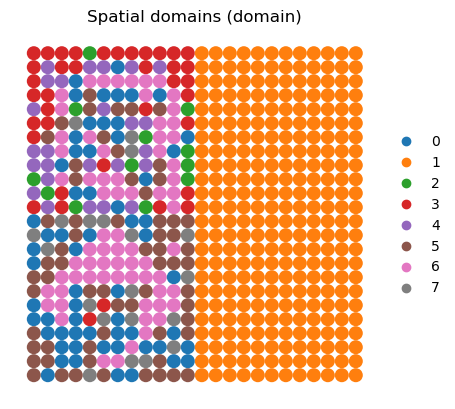

In [11]:
# from cmap_domain_division_like import assign_domains_only

# 例如：在 ST 上分 4 个域，适度空间平滑
adata_prep = assign_domains_only(
    adata_prep,
    k=8,  
    beta=0.5,          # 平滑强度；0~1 通常更稳
    radius=20,       # 默认为 kNN=6；给 radius 则用半径图
    use_raw=False,     # 建议 False，统一用当前 X 做 normalize+log1p
    label_key='domain' # 结果会写到 st_adata.obs['domain']
)

import scanpy as sc
import pandas as pd

# make sure labels are categorical
if not pd.api.types.is_categorical_dtype(adata_prep.obs['domain']):
    adata_prep.obs['domain'] = adata_prep.obs['domain'].astype('category')

# use embedded coordinates in obsm['spatial']
sc.pl.spatial(
    adata_prep,
    color='domain',
    spot_size=10,          # tune (0.5–2.5) depending on your coordinate scale
    frameon=False,
    title='Spatial domains (domain)'
)

/tmp/ipykernel_28121/1873405371.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


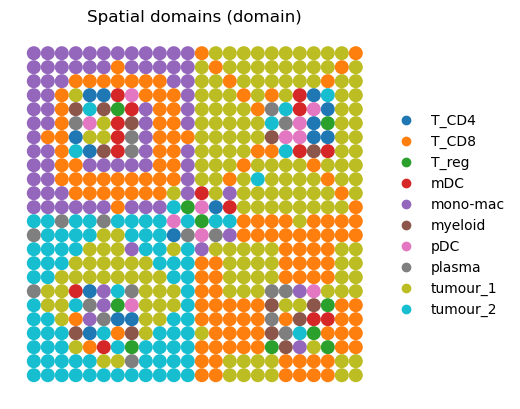

In [12]:
sc.pl.spatial(
    adata_prep,
    color='gt',
    spot_size=10,          # tune (0.5–2.5) depending on your coordinate scale
    frameon=False,
    title='Spatial domains (domain)'
)

In [14]:
# --- deps ---
import numpy as np
import pandas as pd
import scipy.sparse as sp
from sklearn.neighbors import NearestNeighbors

import torch
import torch.nn as nn

# =====================
# 1) Prep data & graph
# =====================
def _to_dense(X):
    return X.toarray() if sp.issparse(X) else np.asarray(X)

def standardize_features(X):
    mu = X.mean(0, keepdims=True)
    sd = X.std(0, keepdims=True) + 1e-6
    return (X - mu) / sd

#kNN
def build_knn_graph(coords, k=8, sigma=None):
    """
    coords: (N,2) or (N,3) spatial positions
    k: neighbors per node (excluding self)
    sigma: if set, edge weight = exp(-d^2/(2*sigma^2)); else weight = 1
    returns normalized adjacency Â as torch.sparse_coo_tensor
    """
    N = coords.shape[0]
    nbrs = NearestNeighbors(n_neighbors=k+1, metric='euclidean').fit(coords)
    dists, idx = nbrs.kneighbors(coords)              # idx: (N, k+1), includes self in col 0

    rows = np.repeat(np.arange(N), k)
    cols = idx[:, 1:].ravel()
    if sigma is None:
        data = np.ones_like(rows, dtype=np.float32)
    else:
        data = np.exp(-(dists[:, 1:].ravel()**2) / (2.0 * sigma**2)).astype(np.float32)

    A = sp.coo_matrix((data, (rows, cols)), shape=(N, N), dtype=np.float32)
    A = A + A.T                                      # symmetrize
    A.setdiag(1.0)                                   # self-loops

    deg = np.asarray(A.sum(1)).flatten()
    d_inv_sqrt = 1.0 / np.sqrt(deg + 1e-8)
    D_inv_sqrt = sp.diags(d_inv_sqrt.astype(np.float32))
    A_hat = (D_inv_sqrt @ A @ D_inv_sqrt).tocoo()

    indices = np.vstack([A_hat.row, A_hat.col])
    A_hat_t = torch.sparse_coo_tensor(
        indices, A_hat.data, (N, N), dtype=torch.float32
    ).coalesce()
    return A_hat_t

# =========================
# 2) Graph Autoencoder GCN
#多加神经网络（2层）
# =========================
class GCNLayer(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.0):
        super().__init__()
        self.lin = nn.Linear(in_dim, out_dim, bias=True)
        self.dropout = dropout

    def forward(self, A_hat, X):
        # A_hat: sparse (N,N), X: (N, F)
        X = torch.nn.functional.dropout(X, p=self.dropout, training=self.training)
        XW = self.lin(X)                              # (N, out_dim)
        H = torch.sparse.mm(A_hat, XW)               # graph smoothing
        return torch.nn.functional.relu(H)

class GraphAutoencoder(nn.Module):
    def __init__(self, in_dim, hid_dim=64, z_dim=16, n_classes=5, dropout=0.1, proj_dim=32):
        super().__init__()
        self.enc1 = GCNLayer(in_dim, hid_dim, dropout=dropout)
        self.enc2 = GCNLayer(hid_dim, z_dim, dropout=dropout)
        self.dec_recon = nn.Linear(z_dim, in_dim)
        #分类的loss.默认SD有类别。
        self.dec_cls   = nn.Linear(z_dim, n_classes)
        # projection head for contrastive learning
        self.proj = nn.Sequential(
            nn.Linear(z_dim, z_dim), nn.ReLU(inplace=True),
            nn.Linear(z_dim, proj_dim)
        )
    #Try VAE
    def forward(self, A_hat, X):
        h = self.enc1(A_hat, X)
        z = self.enc2(A_hat, h)              # (N, z_dim)
        
        ### DEBUG::add embedding?
        # h_sc = self.enc3(A_hat_sc, X_sc)
        # z_sc = self.enc4(A_hat_sc, h_sc)
        #############################
        x_hat = self.dec_recon(z)
        logits = self.dec_cls(z)             
        z_proj = self.proj(z)                # (N, proj_dim)
        return z, z_proj, x_hat, logits

    #对比学习
def supcon_loss(z_proj, y, mask, tau=0.2):
    """
    Supervised contrastive loss (Khosla et al. 2020).
    z_proj: (N, D) projected features. We L2-normalize inside.
    y:      (N,) int64 labels
    mask:   (N,) bool for labeled samples
    """
    z = torch.nn.functional.normalize(z_proj[mask], dim=1)
    y_lab = y[mask]
    if z.size(0) <= 1:
        return torch.tensor(0.0, device=z_proj.device)

    sim = torch.matmul(z, z.T) / tau                      # (L,L)
    sim = sim - torch.max(sim, dim=1, keepdim=True).values  # stability

    # positives mask (same label, excluding self)
    same = (y_lab.unsqueeze(0) == y_lab.unsqueeze(1))
    eye = torch.eye(same.size(0), dtype=torch.bool, device=z.device)
    pos_mask = same & (~eye)

    # denominator: exp(sim) over all j != i
    exp_sim = torch.exp(sim) * (~eye)
    denom = exp_sim.sum(dim=1, keepdim=True) + 1e-12

    # numerator: sum over positives
    num = (exp_sim * pos_mask).sum(dim=1) + 1e-12

    # if a sample has no positives, exclude it
    valid = pos_mask.any(dim=1)
    if valid.float().sum() == 0:
        return torch.tensor(0.0, device=z.device)

    loss_i = -torch.log(num / denom).masked_select(valid)
    return loss_i.mean()

#同一类别聚的更tense
class CenterLoss(torch.nn.Module):
    """Wen et al. 2016: center loss on z."""
    def __init__(self, n_classes, feat_dim):
        super().__init__()
        self.centers = torch.nn.Parameter(torch.zeros(n_classes, feat_dim))

    def forward(self, z, y, mask):
        z_lab = z[mask]
        y_lab = y[mask]
        if z_lab.size(0) == 0:
            return torch.tensor(0.0, device=z.device)
        c = self.centers.index_select(0, y_lab)   # (L, d)
        return ((z_lab - c) ** 2).sum(dim=1).mean()

######## DEBUG::添加了loss的计算函数
# --- MMD (RBF，多核版本，稳妥常用) ---
def mmd_rbf(x: torch.Tensor, y: torch.Tensor, gammas=(0.5, 1.0, 2.0, 4.0, 8.0)):
    # x: [Bx, d], y: [By, d]
    x2 = torch.cdist(x, x, p=2).pow(2)      # [Bx, Bx]
    y2 = torch.cdist(y, y, p=2).pow(2)      # [By, By]
    xy2 = torch.cdist(x, y, p=2).pow(2)     # [Bx, By]
    Kxx = 0.0; Kyy = 0.0; Kxy = 0.0
    for g in gammas:
        Kxx = Kxx + torch.exp(-g * x2)
        Kyy = Kyy + torch.exp(-g * y2)
        Kxy = Kxy + torch.exp(-g * xy2)
    # 无偏估计（去掉对角）
    Bx = x.shape[0]; By = y.shape[0]
    if Bx > 1:
        Kxx = (Kxx.sum() - Kxx.diag().sum()) / (Bx * (Bx - 1))
    else:
        Kxx = Kxx.mean()
    if By > 1:
        Kyy = (Kyy.sum() - Kyy.diag().sum()) / (By * (By - 1))
    else:
        Kyy = Kyy.mean()
    Kxy = Kxy.mean()
    return Kxx + Kyy - 2 * Kxy

# --- CORAL（二阶统计对齐，更快更简单） ---
def coral_loss(x: torch.Tensor, y: torch.Tensor, eps=1e-5):
    # 按列零均值
    x = x - x.mean(dim=0, keepdim=True)
    y = y - y.mean(dim=0, keepdim=True)
    Bx = x.shape[0]; By = y.shape[0]
    Cx = (x.T @ x) / (Bx - 1 + eps)         # [d, d]
    Cy = (y.T @ y) / (By - 1 + eps)
    d = x.shape[1]
    return ((Cx - Cy).pow(2).sum()) / (4.0 * d * d)

def make_srt_template(adata_srt, use_layer=None):
    """
    以 SRT 的基因顺序作为模板，返回：
      - X_srt_std: (N_srt, F_srt) 按 SRT 自身的 mu/sd 标准化后的矩阵
      - mu_srt, sd_srt: (F_srt,) 各列均值/方差（float32）
      - genes_srt: list[str] SRT 的基因顺序（模板）
    """
    X_srt_raw = _to_dense(adata_srt.layers[use_layer] if use_layer else adata_srt.X).astype(np.float32)
    genes_srt = pd.Index(adata_srt.var_names)

    mu_srt = X_srt_raw.mean(axis=0).astype(np.float32)
    sd_srt = (X_srt_raw.std(axis=0) + 1e-6).astype(np.float32)
    X_srt_std = ((X_srt_raw - mu_srt) / sd_srt).astype(np.float32)
    return X_srt_std, mu_srt, sd_srt, list(genes_srt)

def align_sc_to_srt_template(sc_adata, genes_srt, mu_srt, sd_srt,
                             sc_use_layer=None, fill_missing='srt_mean'):
    """
    生成与 SRT 同宽度 (F_srt) 的 scRNA 特征矩阵：
      - 对公共基因：直接按 SRT 的列位拷贝
      - 对 SRT 独有基因：按 fill_missing 填充（推荐 'srt_mean'）
      - 最后用 SRT 的 mu/sd 进行标准化
    
    返回：
      X_sc_std: (N_sc, F_srt)
      present_mask: (F_srt,) bool，标记哪些列在 scRNA 中存在
    """
    X_sc_raw = _to_dense(sc_adata.layers[sc_use_layer] if sc_use_layer else sc_adata.X).astype(np.float32)
    genes_sc  = pd.Index(sc_adata.var_names)

    # 构造从模板基因 -> scRNA 列索引的映射；-1 表示 scRNA 中缺失
    map_idx = genes_sc.get_indexer(genes_srt)  # np.array(shape=(F_srt,), dtype=int)

    N_sc, F_srt = X_sc_raw.shape[0], len(genes_srt)
    # 先整体用填充值铺满，再把存在的列覆盖进去（避免循环，速度快）
    if fill_missing == 'srt_mean':
        base = np.broadcast_to(mu_srt, (N_sc, F_srt)).copy()
    elif fill_missing == 'zero':
        base = np.zeros((N_sc, F_srt), dtype=np.float32)
    else:
        # 也可以传入标量或向量自定义填充值
        fill_val = np.asarray(fill_missing, dtype=np.float32)
        if fill_val.size == 1:
            base = np.full((N_sc, F_srt), float(fill_val), dtype=np.float32)
        else:
            assert fill_val.shape[0] == F_srt
            base = np.broadcast_to(fill_val, (N_sc, F_srt)).copy()

    present_mask = (map_idx >= 0)
    if present_mask.any():
        base[:, present_mask] = X_sc_raw[:, map_idx[present_mask]]

    # 用 SRT 的 mu/sd 做同尺度标准化
    X_sc_std = ((base - mu_srt) / sd_srt).astype(np.float32)
    return X_sc_std, present_mask

##########################################

# ====================
# 3) Full training run

import scanpy as sc

for ad in [adata_prep, sc_adata]:
    if 'log1p' not in ad.layers:
        ad_tmp = ad.copy()
        sc.pp.normalize_total(ad_tmp, target_sum=1e4)
        sc.pp.log1p(ad_tmp)
        ad.layers['log1p'] = ad_tmp.X.copy()
        del ad_tmp
#11.7



# ====================
def train_srt_gae(
    adata, sc_adata,       ## DEBUG sc_adata as input of scRNA data
    use_layer='log1p',        # e.g., 'log1p' if you stored normalized counts there; else None for .X #11.7 None
    k=8,                   # neighbors for spatial graph
    sigma=None,            # Gaussian edge weights; keep None to use unweighted graph
    hid_dim=64, z_dim=16,
    lr=1e-3, weight_decay=1e-4,
    epochs=200,
    alpha=1.0,             # weight for reconstruction loss
    beta=1.0,              # weight for domain classification loss
    gamma=0.1,             # weight for smoothness regularizer
    lam_con=1.0,      # weight for supervised contrastive loss
    lam_center=0.1,   # weight for center loss
    lam_decov=1e-3,   # (optional) decorrelate z (off-diagonal covariance)
    tau=0.2,
    treat_unknown_as_unlabeled=True, unknown_label='Unknown', 
    lam_mmd = 0.1, lam_coral=0.1,  #####DEBUG:: add mmd coral loss here
    lam_bal = 0,
    lam_bal_1 = 0.1,
    lam_ctdom = 0.0005,   ###11.10
    verbose=True
):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # 如果没这个 layer，抛错更安全（你外面已经统一建过了） 11.7
    if use_layer is not None and use_layer not in adata.layers:
        raise KeyError(f"{use_layer} not found in adata.layers")
    if use_layer is not None and use_layer not in sc_adata.layers:
        raise KeyError(f"{use_layer} not found in sc_adata.layers")

    # === SRT 特征模板 ===
    X_srt_std, mu_srt, sd_srt, genes_srt = make_srt_template(
        adata, use_layer=use_layer
    )
    X = torch.tensor(X_srt_std, device=device)
    N, F = X.shape

    # === scRNA 对齐到同一模板 ===
    X_sc_std, present_mask = align_sc_to_srt_template(
        sc_adata, genes_srt, mu_srt, sd_srt,
        sc_use_layer=use_layer,
        fill_missing='srt_mean'
    )
    X_sc = torch.tensor(X_sc_std, device=device)
    
    ####DEBUG not aligned
    # # -- features (assume adata already log-normalized; else do it before)
    # X_np = _to_dense(adata.layers[use_layer] if use_layer else adata.X).astype(np.float32)
    # X_np = standardize_features(X_np)                # zero-mean/unit-var per gene
    # N, F = X_np.shape
    # X = torch.tensor(X_np, device=device)
    
    #  add new route for X <- X_srt_std
    # === 准备 SRT（模板 + 标准化）===
    X_srt_std, mu_srt, sd_srt, genes_srt = make_srt_template(adata, use_layer = use_layer)    ## 11.7
    X = torch.tensor(X_srt_std, device=device)  # (N_srt, F_srt)
    N, F = X.shape

    # === 准备 scRNA：按 SRT 模板对齐 + 填充 + 用 SRT 的 mu/sd 标准化 ===
    X_sc_std, present_mask = align_sc_to_srt_template(
        sc_adata, genes_srt, mu_srt, sd_srt, sc_use_layer = use_layer, fill_missing='srt_mean'  ### 11.7
    )
    X_sc = torch.tensor(X_sc_std, device=device)  # (N_sc, F_srt)
    
        # === 取 scRNA 的 cellType 标签，用于新的约束 === 11.10
    # if 'cellType' not in sc_adata.obs:
    #     has_ct_label = False
    # else:
    #     ct_sc = sc_adata.obs['cellType'].astype('category')
    #     ct_classes = list(ct_sc.cat.categories)
    #     ct_codes = ct_sc.cat.codes.to_numpy().astype(np.int64)
    #     ct = torch.tensor(ct_codes, device=device, dtype=torch.long)
    #     has_ct_label = True
    # === 取 scRNA 的 cellType 标签，用于 ctype-domain 约束 ===
    # === 取 scRNA 的 cellType 标签，用于 ctype-domain 约束 ===
    if 'cellType' in sc_adata.obs:
        ct_sc = sc_adata.obs['cellType'].astype('category')
        ct_classes = list(ct_sc.cat.categories)
        ct_codes = ct_sc.cat.codes.to_numpy().astype(np.int64)
        ct = torch.tensor(ct_codes, device=device, dtype=torch.long)
        has_ct_label = True
    else:
        has_ct_label = False



    
    
    
    
    
    
    
    
    idx = torch.arange(X_sc.shape[0], device=device)
    
    ########DEBUG
    # 1) Identity 图（最省事）
    # A_hat_sc = torch.sparse_coo_tensor(
    #     torch.stack([idx, idx], dim=0), torch.ones_like(idx, dtype=torch.float32),
    #     (X_sc.shape[0], X_sc.shape[0]), dtype=torch.float32, device=device
    # ).coalesce()
    
    # 或 2) 用表达PCA做 kNN（更稳）：
    from sklearn.decomposition import PCA
    coords_sc = PCA(n_components=min(50, X_sc.shape[1]-1), random_state=0).fit_transform(X_sc_std)
    A_hat_sc = build_knn_graph(coords_sc, k=15, sigma=None).to(device)     ####: DEBUG
    
    ##############################
    # -- graph from spatial coords
    #input 
    coords = np.asarray(adata.obsm['spatial'])
    A_hat = build_knn_graph(coords, k=k, sigma=sigma).to(device)

    # -- labels 
    gt = adata.obs['domain'].astype('category') #### used to be 'gt'
    if unknown_label in gt.cat.categories:
        gt = gt.cat.remove_categories([unknown_label])  # rows == Unknown become NaN

    mask_labeled = ~gt.isna().to_numpy()               # use this to mask your CE loss
    y_codes = gt.cat.codes.to_numpy().astype(np.int64)                   # unlabeled are already -1


    # gt = adata.obs['gt'].astype('category')
    classes = list(gt.cat.categories)
    # y_codes = gt.cat.codes.to_numpy()                # Unknown may be -1 if not in categories; ensure mapping
    # If you want to treat a specific category as unlabeled:
    # if treat_unknown_as_unlabeled and unknown_label in classes:
    #     y_codes = gt.cat.rename_categories({unknown_label: np.nan}).cat.codes.to_numpy()

    # mask_labeled = ~np.isnan(y_codes)
    # y_codes = np.where(np.isnan(y_codes), -1, y_codes).astype(int)
    
    

    
    n_classes = len(classes)
    
    #y:domain lable
    y = torch.tensor(y_codes, device=device, dtype=torch.long)
    mask = torch.tensor(mask_labeled, dtype=torch.bool, device=device)

    # -- model
    model = GraphAutoencoder(in_dim=F, hid_dim=hid_dim, z_dim=z_dim,
                             n_classes=n_classes, dropout=0.1, proj_dim=32).to(device)
    ### DEBUG model for sc_adata
    # model_sc = GraphAutoencoder(in_dim=F_sc, hid_dim=hid_dim, z_dim=z_dim,
    #                          n_classes=n_classes, dropout=0.1, proj_dim=32).to(device)
    
    center_crit = CenterLoss(n_classes=n_classes, feat_dim=z_dim).to(device)

    #optimization
    # optionally separate LR for center params (often smaller)
    opt = torch.optim.Adam([
        {'params': model.parameters(), 'lr': lr, 'weight_decay': weight_decay},
        {'params': center_crit.parameters(), 'lr': lr * 0.5, 'weight_decay': 0.0}
    ])

    adata.uns['gae_template'] = {
        'use_layer': use_layer,
        'genes_srt': genes_srt,
        'mu_srt': mu_srt,
        'sd_srt': sd_srt,
    }#11.7
    
    for epoch in range(1, epochs+1):
        model.train(); opt.zero_grad()
        z, z_proj,  x_hat, logits = model(A_hat, X)     
        z_sc, z_proj_sc, x_hat_sc, logits_sc = model(A_hat_sc, X_sc)   ######DEBUG:: add z_proj_sc as new model output

        loss_recon = torch.nn.functional.mse_loss(x_hat, X)  #### X_hat z-decoder output X_hat as estimation of X, X is data input

        
        #########Add weight on loss     11.8
        # y_codes: SRT 上的 domain 标签（仅 labeled）
        lab = y_codes[mask_labeled]
        counts = np.bincount(lab, minlength=n_classes).astype(np.float32)
        freq = counts / counts.sum()
        # 反比权重，防止小类被忽略；再归一化到均值为1
        w = 1.0 / (freq + 1e-6)
        w = w / w.mean()
        ce_weight = torch.tensor(w, device=device, dtype=torch.float32)
        # print("class weights:", ce_weight)
        
        
        if mask.any():
            # loss_cls = torch.nn.functional.cross_entropy(logits[mask], y[mask])
            loss_cls = torch.nn.functional.cross_entropy(logits[mask], y[mask], weight=ce_weight)  ###   11.8
            loss_con = supcon_loss(z_proj, y, mask, tau=tau)
            loss_ctr = center_crit(z, y, mask)
        else:
            loss_cls = torch.tensor(0.0, device=device)
            loss_con = torch.tensor(0.0, device=device)
            loss_ctr = torch.tensor(0.0, device=device)

        # smoothness (your original)
        smooth = torch.sparse.mm(A_hat, z) - z
        loss_smooth = (smooth * smooth).sum() / N

        # (optional) DeCov: penalize off-diagonal covariance of z (promotes disentanglement)
        if lam_decov > 0:
            zc = z - z.mean(dim=0, keepdim=True)
            C = (zc.T @ zc) / (N - 1)
            decov = (C - torch.diag(torch.diag(C))).pow(2).mean()
        else:
            decov = torch.tensor(0.0, device=device)
            
            
        ######DEBUG::add loss component
        mmd_loss_val = mmd_rbf(z_proj,z_proj_sc)   #z_proj_sc as new embedding for scRNA data
        coral_loss_val = coral_loss(z_proj,z_proj_sc)    #,eps)
        
        ##########
        import torch.nn.functional as F

        # 训练前
        prior = torch.tensor(freq, device=device)  # 上面算 freq 的那行

        # 每个 epoch 里，在 forward 后加：
        with torch.no_grad():
            prob = F.softmax(logits, dim=1)

        if mask.any():
            p_mean = prob[mask].mean(dim=0)
        else:
            p_mean = prob.mean(dim=0)

        loss_bal = ((p_mean - prior) ** 2).sum()

        
        
        prob = F.softmax(logits, dim=1)
        p_mean = prob[mask].mean(0) if mask.any() else prob.mean(0)
        entropy_batch = - (p_mean * (p_mean + 1e-8).log()).sum()
        # 惩罚 -entropy 就是奖励高熵
        loss_bal_1 = F.kl_div(p_mean.log(), prior, reduction='sum')



        # === 新增：cellType - domain 分布分离约束 === 11.10
#         if has_ct_label and lam_ctdom > 0:
#             prob_sc = F.softmax(logits_sc, dim=1)        # [N_sc, K]，SC 对各 domain 的预测概率
#             p_list = []

#             # 对每个 cell type，算该类型下的平均 domain 分布 p_t(d)
#             for t_id in range(len(ct_classes)):
#                 mask_t = (ct == t_id)
#                 if mask_t.any():
#                     p_t = prob_sc[mask_t].mean(dim=0)    # [K]
#                     p_list.append(p_t)

#             if len(p_list) >= 2:
#                 p_stack = torch.stack(p_list, dim=0)     # [T_valid, K]

#                 # 1) 每个 cell type 的 domain 分布要更尖锐（低熵）
#                 ent = - (p_stack * (p_stack + 1e-8).log()).sum(dim=1).mean()

#                 # 2) 不同 cell type 的 domain 分布要彼此不同：平均 pairwise MSE 距离
#                 #    距离越大越好，所以在 loss 里用 ent - dist
#                 dist = 0.0
#                 cnt = 0
#                 for i in range(len(p_list)):
#                     for j in range(i + 1, len(p_list)):
#                         dist = dist + ((p_list[i] - p_list[j]) ** 2).mean()
#                         cnt += 1
#                 dist = dist / cnt

#                 # 最终约束：减小熵，同时增大不同 cell type 之间的差距
#                 loss_ctdom = ent - dist
#             else:
#                 loss_ctdom = torch.tensor(0.0, device=device)
#         else:
#             loss_ctdom = torch.tensor(0.0, device=device)
        # === cellType - domain 分布约束，防止塌缩 ===
        if has_ct_label and lam_ctdom > 0:
            prob_sc = F.softmax(logits_sc, dim=1)        # [N_sc, K]
            K = prob_sc.size(1)

            # (1) 全体 SC 的 domain 边缘分布 p(d)
            p_global = prob_sc.mean(dim=0)               # [K]

            # 惩罚塌缩到某个 domain：让 p_global 接近均匀
            p_uni = torch.full_like(p_global, 1.0 / K)
            loss_marg = F.kl_div(p_global.log(), p_uni, reduction='sum')

            # (2) 条件分布 p(d|c)：每个 cell type 内部的 domain 分布
            p_ct_list = []
            ent_list = []

            for t_id in range(len(ct_classes)):
                mask_t = (ct == t_id)
                if mask_t.sum() < 20:
                    continue  # 太少的类型跳过，避免噪声
                p_t = prob_sc[mask_t].mean(dim=0)        # [K]
                p_ct_list.append(p_t)
                ent_t = - (p_t * (p_t + 1e-8).log()).sum()
                ent_list.append(ent_t)

            if len(p_ct_list) >= 2:
                p_stack = torch.stack(p_ct_list, dim=0)

                # 平均条件熵: 希望小一点 -> 每个 cell type 更集中到少数 domain
                ent_cond = torch.stack(ent_list).mean()

                # 不同 cell type 的 p(d|c) 要彼此不同
                pair_dist = 0.0
                cnt = 0
                for i in range(len(p_ct_list)):
                    for j in range(i + 1, len(p_ct_list)):
                        pair_dist += ((p_ct_list[i] - p_ct_list[j]) ** 2).mean()
                        cnt += 1
                pair_dist = pair_dist / cnt

                # 总的：避免塌缩( loss_marg ) + 让每个 type 更“专一”( ent_cond ) - 拉开 type 间差异( pair_dist )
                loss_ctdom = ent_cond + loss_marg - pair_dist
            else:
                loss_ctdom = torch.tensor(0.0, device=device)
        else:
            loss_ctdom = torch.tensor(0.0, device=device)


        
        
        

        loss = (alpha * loss_recon
                + beta * loss_cls
                + gamma * loss_smooth
                + lam_con * loss_con
                + lam_center * loss_ctr
                + lam_decov * decov
                + lam_mmd * mmd_loss_val   ###DEBUG MMD loss
                + lam_coral * coral_loss_val
                + lam_bal * loss_bal
                + lam_bal_1 * loss_bal_1
                + lam_ctdom * loss_ctdom)
  

        loss.backward(); opt.step()

        if verbose and epoch % 25 == 0:
            with torch.no_grad():
                acc = (logits[mask].argmax(1) == y[mask]).float().mean().item() if mask.any() else float('nan')
            print(f"Ep{epoch:03d} | L={loss.item():.3f} "
                  f"[rec {loss_recon.item():.3f} cls {loss_cls.item():.3f} sm {loss_smooth.item():.3f} "
                  f"con {loss_con.item():.3f} ctr {loss_ctr.item():.3f} dc {decov.item():.3f}] acc {acc:.3f}")

    # save results back to AnnData
    model.eval()
    with torch.no_grad():
        z, z_proj, x_hat, logits = model(A_hat, X)
        pred = logits.argmax(1).detach().cpu().numpy()

    adata.obsm['gae_latent'] = z.detach().cpu().numpy().astype(np.float32)
    adata.layers['gae_recon'] = x_hat.detach().cpu().numpy().astype(np.float32)
    adata.obs['pred_gt'] = pd.Categorical.from_codes(pred, classes)

    return model, A_hat_sc
    


In [15]:
# If your adata is raw counts, first do:
# import scanpy as sc
# sc.pp.normalize_total(adata, target_sum=1e4); sc.pp.log1p(adata)

# model = train_srt_gae(
#     adata_prep,
#     use_layer=None,     # or the name of your normalized/log1p layer
#     k=8, sigma=None,    # try sigma ~ median neighbor distance to weight edges
#     hid_dim=512, z_dim=128,
#     epochs=1024, alpha=1.0, beta=1.0, gamma=0.1,
#     treat_unknown_as_unlabeled=True, unknown_label='Unknown'
# )

model,model1 = train_srt_gae(
    adata_prep, sc_adata,
    use_layer= 'log1p',     # or the name of your normalized/log1p layer  #11.7 None
    k=8, sigma=None,    # try sigma ~ median neighbor distance to weight edges
    hid_dim=512, z_dim=128,
    epochs=2024, alpha=1.0, beta=1.0, gamma=0.1,        
    # lam_con=0.0, lam_center=0.0, lam_decov=0.0,   ###11.7 
    treat_unknown_as_unlabeled=True, unknown_label='Unknown', lam_mmd = 0.1, lam_coral=0
)

# Results:
# - adata.obsm['gae_latent'] : (N, z_dim) embedding
# - adata.layers['gae_recon']: reconstructed expression
# - adata.obs['pred_gt']     : predicted domain label

/tmp/ipykernel_28121/1873095670.py:112: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1762103288612/work/aten/src/ATen/Context.cpp:233.)
  sim = torch.matmul(z, z.T) / tau                      # (L,L)
/tmp/ipykernel_28121/1873095670.py:463: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministi

Ep025 | L=3.401 [rec 0.985 cls 1.810 sm 0.083 con 0.447 ctr 0.980 dc 0.000] acc 0.691
Ep050 | L=2.962 [rec 0.958 cls 1.531 sm 0.222 con 0.232 ctr 1.675 dc 0.000] acc 0.785
Ep075 | L=2.612 [rec 0.933 cls 1.260 sm 0.353 con 0.125 ctr 2.164 dc 0.000] acc 0.837
Ep100 | L=2.356 [rec 0.913 cls 1.028 sm 0.485 con 0.089 ctr 2.460 dc 0.000] acc 0.852
Ep125 | L=2.132 [rec 0.900 cls 0.843 sm 0.572 con 0.061 ctr 2.451 dc 0.000] acc 0.896
Ep150 | L=1.959 [rec 0.893 cls 0.705 sm 0.621 con 0.048 ctr 2.329 dc 0.000] acc 0.936
Ep175 | L=1.811 [rec 0.883 cls 0.590 sm 0.675 con 0.038 ctr 2.181 dc 0.000] acc 0.941
Ep200 | L=1.717 [rec 0.878 cls 0.502 sm 0.712 con 0.045 ctr 2.094 dc 0.000] acc 0.969
Ep225 | L=1.598 [rec 0.874 cls 0.423 sm 0.747 con 0.029 ctr 1.881 dc 0.000] acc 0.974
Ep250 | L=1.526 [rec 0.868 cls 0.360 sm 0.756 con 0.031 ctr 1.835 dc 0.000] acc 0.984
Ep275 | L=1.475 [rec 0.866 cls 0.325 sm 0.774 con 0.032 ctr 1.670 dc 0.000] acc 0.983
Ep300 | L=1.402 [rec 0.863 cls 0.281 sm 0.780 con 0.02

In [16]:
adata_prep

AnnData object with n_obs × n_vars = 576 × 1000
    obs: 'cell_count', 'region_id', 'second_sampling', 'gt', 'domain', 'pred_gt'
    var: 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'density', 'proportion_names', 'log1p', 'hvg', 'domain_domain_genes', 'domain_colors', 'gt_colors', 'gae_template'
    obsm: 'proportions', 'spatial', 'gae_latent'
    layers: 'log1p', 'gae_recon'

/opt/micromamba/envs/py310/lib/python3.10/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)
/opt/micromamba/envs/py310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-07 15:53:41.076431: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-07 15:53:41.135508: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the followin

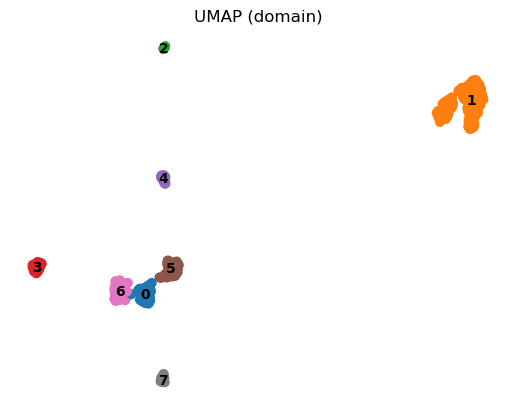

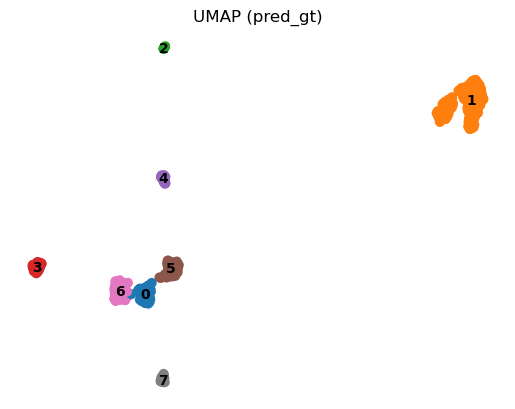

In [18]:
import scanpy as sc
import numpy as np
import pandas as pd
####DEBUG ::: add single cell mapping info?
### sc_adata.obs.cellType? umap

# Ensure your model run saved this:
Z = adata_prep.obsm.get('gae_latent')
assert Z is not None, "No embedding found at adata.obsm['gae_latent']"

# UMAP from the embedding
sc.pp.neighbors(adata_prep, use_rep='gae_latent', n_neighbors=15, metric='cosine')
sc.tl.umap(adata_prep, min_dist=0.3, spread=1.0)

for col in ['domain', 'pred_gt']:
    if col in adata_prep.obs and not pd.api.types.is_categorical_dtype(adata_prep.obs[col]):
        adata_prep.obs[col] = adata.obs[col].astype('category')

# Ground-truth domain
sc.pl.umap(adata_prep, color='domain', frameon=False, legend_loc='on data', title='UMAP (domain)')

# If you also have model predictions from the decoder:
if 'pred_gt' in adata_prep.obs:
    sc.pl.umap(adata_prep, color='pred_gt', frameon=False, legend_loc='on data', title='UMAP (pred_gt)')




In [19]:
#先用全量细胞做一次“临时预测”，据此在 cellType × 预测的 domain 的二维表上均衡抽样出一个代表性子集；
#再只对这个子集构图并跑模型，得到 latent 与最终预测。这样既加速/省显存，又避免被大类或单一 domain 淹没。


#把训练好的空间图自编码器（GAE）拿来给新的 scRNA 数据做空间域（domain）预测，
#同时产出该模型的潜在表示（embedding）。
#为兼顾速度与效果，它先全量快速粗预测→据此均衡抽样→对子集做正式推理。

import numpy as np
import pandas as pd
import scipy.sparse as sp
import torch
import torch.nn.functional as F
import scanpy as sc

def _to_dense(X): 
    return X.toarray() if sp.issparse(X) else np.asarray(X)


#对全量 scRNA 细胞做一次**“不建图（身份图）”的快速临时预测**，得到每个细胞对各 domain 的概率和 argmax 预测。
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

def _provisional_pred(
    sc_adata,
    adata_train,
    model,
    train_layer='log1p',      # 仅在没有模板时作为默认 use_layer
    target_sum=1e4,           # 不再直接用；保留给兼容逻辑
    device=None,
    A_sc=None
):
    """
    用训练好的 GAE 模型，对 sc_adata 全部细胞做一次预测。
    关键点：严格复用 SRT 训练时的模板 (genes_srt, mu_srt, sd_srt, use_layer)，
    保证特征空间和 encoder 训练阶段一致。
    """
    if device is None:
        device = next(model.parameters()).device

    # ===== 1. 读取或构建模板 =====
    if 'gae_template' in adata_train.uns:
        tpl = adata_train.uns['gae_template']
        use_layer = tpl.get('use_layer', train_layer)
        genes_srt = pd.Index(tpl['genes_srt'])
        mu_srt = np.asarray(tpl['mu_srt'], dtype=np.float32)
        sd_srt = np.asarray(tpl['sd_srt'], dtype=np.float32)
    else:
        # 如果训练时还没存模板，这里用和训练一致的方式现算一份
        use_layer = train_layer  # 建议你的 train_srt_gae 也用这个 layer
        X_srt_std, mu_srt, sd_srt, genes_srt = make_srt_template(
            adata_train,
            use_layer=use_layer
        )
        adata_train.uns['gae_template'] = {
            'use_layer': use_layer,
            'genes_srt': list(genes_srt),
            'mu_srt': mu_srt,
            'sd_srt': sd_srt,
        }
        genes_srt = pd.Index(genes_srt)

    # ===== 2. 按模板对齐 sc_adata 特征 =====
    # 这里非常关键：用 align_sc_to_srt_template，而不是自己重新算 mu/sd
    X_sc_std, _ = align_sc_to_srt_template(
        sc_adata,
        genes_srt=genes_srt,
        mu_srt=mu_srt,
        sd_srt=sd_srt,
        sc_use_layer=use_layer,
        fill_missing='srt_mean'
    )

    X_t = torch.tensor(X_sc_std, dtype=torch.float32, device=device)

    # ===== 3. 构建图（默认 identity；如果外面传了 A_sc 就用外面的）=====
    if A_sc is None or (isinstance(A_sc, (int, float)) and A_sc == 0):
        N = X_sc_std.shape[0]
        idx = np.vstack([np.arange(N), np.arange(N)])
        A = torch.sparse_coo_tensor(
            idx,
            np.ones(N, dtype=np.float32),
            (N, N),
            dtype=torch.float32,
            device=device,
        ).coalesce()
    else:
        A = A_sc.to(device)

    # ===== 4. 前向预测 =====
    model.eval()
    with torch.no_grad():
        _, _, _, logits = model(A, X_t)
        proba = F.softmax(logits, dim=1).cpu().numpy()
        pred_idx = proba.argmax(1)
        
        

    return pred_idx, proba




# def _balanced_indices_by_ct_and_pred(
#     sc_adata,
#     pred_idx,
#     proba,
#     classes,
#     ct_key='cellType',
#     max_per_type=500,
#     domain_balance='equal',
#     rng_seed=0,
#     min_cells_per_domain=50,   # ⭐ 你关心的参数：希望每个 domain 至少保留多少个细胞（按临时预测）
# ):
#     """
#     在 cellType (行) × provisional domain (列) 上做均衡抽样，并兜底保证：
#     只要某个 domain 在临时预测里出现过，就尽量在子集中留至少
#     min_cells_per_domain 个属于该 domain 的细胞（按 provisional labels）。

#     参数
#     ----
#     sc_adata : AnnData
#         单细胞 AnnData（完整数据）。
#     pred_idx : (N,) int array
#         临时预测的 domain index (0..C-1)，通常来自 _provisional_pred。
#     proba : (N, C) float array
#         临时预测的 softmax 概率矩阵。
#     classes : list[str]
#         domain 名称列表，顺序要与 pred_idx / proba 列一致。
#     ct_key : str
#         用作行的 cellType 键。
#     max_per_type : int
#         每个 cellType 最多保留多少个细胞（抽样前的软约束）。
#     domain_balance : {'equal', 'proportional'}
#         在列方向 (domain) 上如何分配总名额。
#     rng_seed : int
#         随机数种子（目前主要用于兼容接口，函数内部几乎不用随机）。
#     min_cells_per_domain : int
#         希望子集中每个 domain 至少留多少个细胞（如果有那么多可选）。

#     返回
#     ----
#     keep_idx : np.ndarray
#         排好序的被选中细胞的行索引（基于原始 sc_adata.obs 的行号）。
#     """
#     rng = np.random.default_rng(rng_seed)

#     # ==== 准备基本信息 ====
#     ct = sc_adata.obs[ct_key].astype('category')
#     ct_cats = list(ct.cat.categories)
#     dom_cats = list(classes)  # 列顺序

#     # 构造一个 DataFrame：cellType, provisional domain, 行索引, conf(对该 provisional 的概率)
#     df = pd.DataFrame({
#         'ct': ct.astype(str).values,
#         'dom': pd.Categorical.from_codes(pred_idx, dom_cats).astype(str),
#         'row': np.arange(sc_adata.n_obs)
#     })
#     prob_df = pd.DataFrame(proba, index=sc_adata.obs_names, columns=dom_cats)
#     df['conf'] = prob_df.to_numpy()[np.arange(sc_adata.n_obs), pred_idx]

#     # availability A[ct, dom]：每个 cellType × provisional domain 的可选数量
#     A = (
#         df.groupby(['ct', 'dom'])
#           .size()
#           .unstack(fill_value=0)
#           .reindex(index=ct_cats, columns=dom_cats, fill_value=0)
#     )
#     avail_ct = A.sum(axis=1)   # 每个 cellType 可选数量
#     avail_dom = A.sum(axis=0)  # 每个 domain 可选数量（按 provisional labels）

#     # ==== 行目标：每个 cellType 最多 max_per_type ====
#     R = pd.Series({ct_: min(max_per_type, int(avail_ct[ct_])) for ct_ in ct_cats})
#     total_target = int(R.sum())
#     if total_target == 0:
#         raise ValueError("No available cells to sample with the requested constraints.")

#     # ==== 列目标：各 domain 总体目标 C[d] ====
#     if domain_balance == 'equal':
#         base = total_target // len(dom_cats)
#         C = pd.Series({d: min(int(avail_dom[d]), base) for d in dom_cats})
#         rem = total_target - int(C.sum())
#         if rem > 0:
#             # 优先给还有富余空间的 domain
#             order = sorted(dom_cats, key=lambda d: avail_dom[d] - C[d], reverse=True)
#             for d in order:
#                 if rem == 0:
#                     break
#                 if C[d] < avail_dom[d]:
#                     C[d] += 1
#                     rem -= 1
#     elif domain_balance == 'proportional':
#         C = (avail_dom / avail_dom.sum() * total_target).round().astype(int)
#         # 不能超过 availability
#         over = (C - avail_dom).clip(lower=0)
#         C -= over
#         diff = total_target - int(C.sum())
#         if diff > 0:
#             order = (avail_dom - C).sort_values(ascending=False).index
#             for d in order:
#                 if diff == 0:
#                     break
#                 if C[d] < avail_dom[d]:
#                     C[d] += 1
#                     diff -= 1
#         elif diff < 0:
#             order = C.sort_values(ascending=False).index
#             for d in order:
#                 if diff == 0:
#                     break
#                 if C[d] > 0:
#                     C[d] -= 1
#                     diff += 1
#     else:
#         raise ValueError("domain_balance must be 'equal' or 'proportional'.")

#     # ==== 初始配额 Q[ct, dom]：在每个 cellType 内按比例分配到各 domain ====
#     P_row = A.div(A.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)
#     Q = (P_row.mul(R, axis=0)).round().astype(int)
#     Q = np.minimum(Q, A)  # 不超过可选数量

#     # ==== 调整行：保证每个 cellType 的总数尽量等于 R[ct] ====
#     row_def = (R - Q.sum(axis=1)).astype(int)
#     for ct_ in ct_cats:
#         deficit = int(row_def.get(ct_, 0))
#         if deficit <= 0:
#             continue
#         room = (A.loc[ct_] - Q.loc[ct_]).clip(lower=0)
#         order = room.sort_values(ascending=False).index
#         for d in order:
#             if deficit == 0:
#                 break
#             add = min(deficit, int(room[d]))
#             Q.loc[ct_, d] += add
#             deficit -= add

#     # ==== 调整列：尽量接近 C[d] ====
#     col_def = (C - Q.sum(axis=0)).astype(int)
#     for d in dom_cats:
#         deficit = int(col_def.get(d, 0))
#         if deficit <= 0:
#             continue
#         room_ct = (A[d] - Q[d]).clip(lower=0)
#         slack_ct = (R - Q.sum(axis=1)).clip(lower=0)
#         score = (
#             pd.concat([room_ct, slack_ct], axis=1)
#               .min(axis=1)
#               .sort_values(ascending=False)
#         )
#         for ct_ in score.index:
#             if deficit == 0:
#                 break
#             can = int(min(room_ct[ct_], slack_ct[ct_]))
#             if can <= 0:
#                 continue
#             add = min(deficit, can)
#             Q.loc[ct_, d] += add
#             deficit -= add

#     Q = np.minimum(Q, A)  # 再保险

#     # ==== 按 (ct, dom) + conf 选具体行索引 ====
#     keep = []
#     grouped = df.groupby(['ct', 'dom'], sort=False)
#     for ct_ in ct_cats:
#         for d in dom_cats:
#             need = int(Q.loc[ct_, d]) if (ct_ in Q.index and d in Q.columns) else 0
#             if need <= 0:
#                 continue
#             if (ct_, d) not in grouped.groups:
#                 continue
#             rows = (
#                 grouped.get_group((ct_, d))
#                        .sort_values('conf', ascending=False)['row']
#                        .to_numpy()
#             )
#             keep.append(rows[:need])

#     if not keep:
#         raise ValueError("No cells selected after balancing—check availability and targets.")
#     keep_idx = np.sort(np.concatenate(keep))
#     kept_set = set(keep_idx.tolist())

#     # ==== 兜底：保证每个有候选的 domain 至少 min_cells_per_domain 个（按 provisional） ====
#     # 当前子集里各 domain 的数量（按 provisional）
#     selected_df = df.loc[df['row'].isin(keep_idx)]
#     kept_dom_counts = (
#         selected_df['dom']
#         .value_counts()
#         .reindex(dom_cats, fill_value=0)
#     )

#     for d in dom_cats:
#         # 如果这个 domain 在全局临时预测里根本没有候选细胞，没法补
#         if avail_dom[d] <= 0:
#             continue

#         current = int(kept_dom_counts.get(d, 0))
#         if current >= min_cells_per_domain:
#             continue

#         need_extra = min_cells_per_domain - current
#         if need_extra <= 0:
#             continue

#         # 在这个 domain 里，按 conf 从高到低找“还没被选过”的细胞
#         cand_rows = (
#             df.loc[df['dom'] == d]
#               .sort_values('conf', ascending=False)['row']
#               .to_numpy()
#         )
#         added = 0
#         for r in cand_rows:
#             if r not in kept_set:
#                 keep_idx = np.append(keep_idx, r)
#                 kept_set.add(r)
#                 added += 1
#                 if added >= need_extra:
#                     break
#         # 如果 avail_dom[d] 本身 < min_cells_per_domain，就最多只能补到 avail_dom[d]

#     keep_idx = np.sort(keep_idx)
#     return keep_idx




# 用 cellType × 临时domain 的分布做均衡抽样，挑出子集。
def _balanced_indices_by_ct_and_pred(
    sc_adata, pred_idx, proba, classes,
    ct_key='cellType', max_per_type=500, domain_balance='equal', rng_seed=0
):
    """
    Choose a balanced subset across cellType (rows) and pred_domain (cols).
    Strategy:
      - row targets: R_ct = min(max_per_type, available in ct)
      - col targets: equal share (or 'proportional' to availability)
      - initial quota: floor(R_ct * p(ct,dom)), p from observed cross-tab
      - adjust to approach domain targets; clip by availability
      - within each (ct,dom), pick highest-confidence cells (top proba for dom)
    Returns: np.ndarray of kept row indices (sorted).
    """
    rng = np.random.default_rng(rng_seed)
    ct = sc_adata.obs[ct_key].astype('category')
    ct_cats = list(ct.cat.categories)
    dom_cats = list(classes)           # columns order

    # availability lists per (ct, dom)
    df = pd.DataFrame({
        'ct': ct.astype(str).values,
        'dom': pd.Categorical.from_codes(pred_idx, dom_cats).astype(str),
        'row': np.arange(sc_adata.n_obs)
    })
    # Attach confidences for sorting
    prob_df = pd.DataFrame(proba, index=sc_adata.obs_names, columns=dom_cats)
    df['conf'] = prob_df.to_numpy()[np.arange(sc_adata.n_obs), pred_idx]

    # availability counts A[ct,dom]
    A = df.groupby(['ct','dom']).size().unstack(fill_value=0).reindex(index=ct_cats, columns=dom_cats, fill_value=0)
    avail_ct = A.sum(axis=1)     # available per ct
    avail_dom = A.sum(axis=0)    # available per dom

    # row targets
    R = pd.Series({ct_: min(max_per_type, int(avail_ct[ct_])) for ct_ in ct_cats})
    total_target = int(R.sum())
    if total_target == 0:
        raise ValueError("No available cells to sample with the requested constraints.")

    # domain targets
    if domain_balance == 'equal':
        # equal share, but not exceeding availability
        base = total_target // len(dom_cats)
        C = pd.Series({d: min(int(avail_dom[d]), base) for d in dom_cats})
        # distribute remainder one-by-one to domains with remaining availability
        rem = total_target - int(C.sum())
        if rem > 0:
            order = sorted(dom_cats, key=lambda d: avail_dom[d] - C[d], reverse=True)
            for d in order:
                if rem == 0: break
                if C[d] < avail_dom[d]:
                    C[d] += 1; rem -= 1
    elif domain_balance == 'proportional':
        C = (avail_dom / avail_dom.sum() * total_target).round().astype(int)
        # clip to availability, then fix total by adding/removing to closest
        over = (C - avail_dom).clip(lower=0)
        C -= over
        diff = total_target - int(C.sum())
        if diff > 0:
            order = (avail_dom - C).sort_values(ascending=False).index
            for d in order:
                if diff == 0: break
                if C[d] < avail_dom[d]:
                    C[d] += 1; diff -= 1
        elif diff < 0:
            order = (C).sort_values(ascending=False).index
            for d in order:
                if diff == 0: break
                if C[d] > 0:
                    C[d] -= 1; diff += 1
    else:
        raise ValueError("domain_balance must be 'equal' or 'proportional'.")

    # initial quotas per (ct,dom) proportional within ct
    P_row = A.div(A.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)
    Q = (P_row.mul(R, axis=0)).round().astype(int)
    # clip by availability
    Q = np.minimum(Q, A)

    # adjust rows to match R exactly
    row_def = (R - Q.sum(axis=1)).astype(int)
    for ct_ in ct_cats:
        deficit = int(row_def.get(ct_, 0))
        if deficit <= 0: continue
        # add to domains with remaining availability in this ct
        room = (A.loc[ct_] - Q.loc[ct_]).clip(lower=0)
        order = room.sort_values(ascending=False).index
        for d in order:
            if deficit == 0: break
            add = min(deficit, int(room[d]))
            Q.loc[ct_, d] += add
            deficit -= add

    # adjust columns to match C approximately
    col_def = (C - Q.sum(axis=0)).astype(int)
    for d in dom_cats:
        deficit = int(col_def.get(d, 0))
        if deficit <= 0: continue
        # add cells in column d from cell types that still have room (avail-Q)
        room_ct = (A[d] - Q[d]).clip(lower=0)              # per ct
        # prefer cts where R not yet met
        slack_ct = (R - Q.sum(axis=1)).clip(lower=0)
        # score ct by min(room, slack)
        score = (pd.concat([room_ct, slack_ct], axis=1).min(axis=1)).sort_values(ascending=False)
        for ct_ in score.index:
            if deficit == 0: break
            can = int(min(room_ct[ct_], slack_ct[ct_]))
            if can <= 0: continue
            add = min(deficit, can)
            Q.loc[ct_, d] += add
            deficit -= add
            
            

    # final clip (safety)
    Q = np.minimum(Q, A)

    # --- pick actual indices: highest-confidence per (ct,dom) ---
    keep = []
    # create per-group sorted indices by confidence (desc)
    grouped = df.groupby(['ct','dom'], sort=False)
    for ct_ in ct_cats:
        for d in dom_cats:
            need = int(Q.loc[ct_, d]) if (ct_ in Q.index and d in Q.columns) else 0
            if need <= 0: continue
            if (ct_, d) not in grouped.groups: continue
            rows = grouped.get_group((ct_, d)).sort_values('conf', ascending=False)['row'].to_numpy()
            keep.append(rows[:need])

    if not keep:
        raise ValueError("No cells selected after balancing—check availability and targets.")
    keep_idx = np.sort(np.concatenate(keep))
    return keep_idx

def embed_and_predict_sc(
    sc_adata,
    adata_train,
    model,
    train_layer='log1p',
    k_sc=8,
    target_sum=1e4,
    use_identity_graph=False,
    max_per_type=1000,
    rng_seed=0,
    domain_balance='equal',   # 'equal' or 'proportional'
    A_sc=0
):
    device = next(model.parameters()).device
    model.eval()

    # classes from training
    genes_train = pd.Index(adata_train.var_names)
    if 'gae_classes' in adata_train.uns:
        classes = list(adata_train.uns['gae_classes'])
    else:
        classes = list(adata_train.obs['pred_gt'].astype('category').cat.categories)
    n_classes = model.dec_cls.out_features
    assert len(classes) == n_classes, "Class count mismatch with model head."

    # ---- PASS 1: provisional predictions on ALL cells ----
    pred_idx_full, proba_full = _provisional_pred(sc_adata, adata_train, model, train_layer, target_sum, device, A_sc)
    # print(set(pred_idx_full))

    # ---- Balanced subset across cellType and provisional pred_domain ----
    keep_idx = _balanced_indices_by_ct_and_pred(
        sc_adata, pred_idx_full, proba_full, classes,
        ct_key='cellType', max_per_type=max_per_type,
        domain_balance=domain_balance, rng_seed=rng_seed
    )
    sc_sub = sc_adata[keep_idx].copy()
    
    print(set( pred_idx_full[keep_idx]))
    
    # 子集对应的 PASS1 预测（预备标签）
    pred_idx_prelim_sub = pred_idx_full[keep_idx]
    proba_prelim_sub = proba_full[keep_idx, :]

    sc_sub.obs['pred_domain_prelim'] = pd.Categorical.from_codes(
        pred_idx_prelim_sub,
        classes
    )


    # ---- PASS 2: final normalization / features / graph ----
    sc.pp.normalize_total(sc_sub, target_sum=target_sum)
    sc.pp.log1p(sc_sub)
    sc_sub.layers['log1p'] = sc_sub.X.copy()

    common = genes_train.intersection(sc_sub.var_names)
    X_sc_common = _to_dense(sc_sub[:, common].layers[train_layer])
    X_sc = np.zeros((sc_sub.n_obs, len(genes_train)), dtype=np.float32)
    X_sc[:, genes_train.get_indexer(common)] = X_sc_common

    X_tr = _to_dense(adata_train.layers[train_layer])
    mu = X_tr.mean(0, keepdims=True); sd = X_tr.std(0, keepdims=True) + 1e-6
    X_sc_std = (X_sc - mu) / sd

#     if use_identity_graph:
#         N = sc_sub.n_obs
#         idx = np.vstack([np.arange(N), np.arange(N)])
#         A_sc = torch.sparse_coo_tensor(idx, np.ones(N, dtype=np.float32), (N, N)).coalesce().to(device)
        
#     else:
#         feat_knn = X_sc_std
#         labels_sub = sc_sub.obs['cellType']
#         A_sc = build_knn_graph_from_features(
#             feat_knn, labels_sub, k=k_sc, sigma=None, k_min=1, allow_cross_fill=True
#         ).to(device)
#     A_sc = A_sc.to(device)
    from sklearn.decomposition import PCA
    coords_sc = PCA(n_components=min(50, X_sc.shape[1]-1), random_state=0).fit_transform(X_sc_std)
    A_sc = build_knn_graph(coords_sc, k=15, sigma=None).to(device)
    
    # ---- PASS 2: run encoder/decoder on the balanced subset ----
#     X_t = torch.tensor(X_sc_std, dtype=torch.float32, device=device)
#     with torch.no_grad():
#         z_sc, _, _, logits_sc = model(A_sc, X_t)
#         prob_sc = F.softmax(logits_sc, dim=1).cpu().numpy()
#         pred_idx = prob_sc.argmax(axis=1)

#     # ---- write outputs ----
#     sc_sub.obsm['gae_latent'] = z_sc.cpu().numpy().astype(np.float32)
#     sc_sub.obs['pred_domain'] = pd.Categorical.from_codes(pred_idx, classes)
#     sc_sub.obsm['pred_domain_proba'] = pd.DataFrame(prob_sc, index=sc_sub.obs_names, columns=classes)
# ---- PASS 2: run encoder/decoder on the balanced subset ----
# ---- PASS 2: run encoder/decoder on the balanced subset ----
# ---- PASS 2: run encoder/decoder on the balanced subset ----
    X_t = torch.tensor(X_sc_std, dtype=torch.float32, device=device)
    with torch.no_grad():
        z_sc, _, _, logits_sc = model(A_sc, X_t)
        prob_sc = F.softmax(logits_sc, dim=1).cpu().numpy()
        pred_idx_pass2 = prob_sc.argmax(axis=1)

    # ================= 新增：PASS2 之后的兜底修正 =================
    # 目标：保证每个 domain（特别是 domain1）至少有若干个细胞

    pred_idx_final = pred_idx_pass2.copy()

    # 子集里 PASS1 的标签 & 概率（上面已经算过，如果你没存，就再算一遍）
    pred_idx_prelim_sub = pred_idx_full[keep_idx]
    proba_prelim_sub = proba_full[keep_idx, :]  # shape: (n_sub, n_classes)

    # 1) 当前 PASS2 预测下，每个 domain 有多少细胞？
    dom_counts_pass2 = np.bincount(pred_idx_pass2, minlength=len(classes))

    # 2) 设定一个“最终最少细胞数”的门槛
    #    - 对所有 domain 用一个默认值，比如 20
    #    - 对你特别关心的 domain1，可以设更高一点
    min_cells_default = 20
    min_cells_per_domain_final = {
        name: min_cells_default for name in classes
    }
    # 特别保护 domain1（如果存在的话）
    if 'domain1' in min_cells_per_domain_final:
        min_cells_per_domain_final['domain1'] = 50   # 举例：至少 50 个

    # 3) 遍历每个 domain，看看是否需要“抢救”
    for d, dom_name in enumerate(classes):
        target_min = min_cells_per_domain_final.get(dom_name, min_cells_default)
        current = int(dom_counts_pass2[d])

        if current >= target_min:
            continue  # 这个 domain 已经够多了，无需改

        # 子集里，PASS1 预测属于这个 domain 的细胞
        mask_sub = (pred_idx_prelim_sub == d)
        if not np.any(mask_sub):
            # PASS1 在子集里都没有这个 domain，没法补
            continue

        cand_idx_sub = np.where(mask_sub)[0]

        # 按 PASS1 对该 domain 的概率，从高到低排序
        scores = proba_prelim_sub[cand_idx_sub, d]
        order = np.argsort(scores)[::-1]
        cand_idx_sub = cand_idx_sub[order]

        # 需要额外抢救多少个细胞？
        need_extra = target_min - current
        rescued = 0

        for idx_sub in cand_idx_sub:
            if rescued >= need_extra:
                break
            # 已经是这个 domain 了就不用改
            if pred_idx_final[idx_sub] == d:
                continue
            pred_idx_final[idx_sub] = d
            rescued += 1

    # ================= 兜底修正结束 =================

    # ---- write outputs ----
    sc_sub.obsm['gae_latent'] = z_sc.cpu().numpy().astype(np.float32)
    sc_sub.obs['pred_domain'] = pd.Categorical.from_codes(pred_idx_final, classes)
    sc_sub.obsm['pred_domain_proba'] = pd.DataFrame(
        prob_sc, index=sc_sub.obs_names, columns=classes
)



    # provenance: show achieved balance
    ct_counts = sc_sub.obs['cellType'].value_counts().to_dict()
    dom_counts = sc_sub.obs['pred_domain'].value_counts().to_dict()
    sc_sub.uns['subsample_info'] = {
        'strategy': 'balanced_ct_x_pred_domain',
        'max_per_type': int(max_per_type),
        'domain_balance': domain_balance,
        'rng_seed': int(rng_seed),
        'kept_counts_by_cellType': ct_counts,
        'kept_counts_by_pred_domain': dom_counts
    }
    return sc_sub


In [20]:
sc_adata.obs['cellType'] = sc_adata.obs['cell_type']

In [21]:
print('pred_domain' in sc_adata.obs.columns)
print('cellType'   in sc_adata.obs.columns)


False
True


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def plot_celltype_by_pred_domain(adata, ct_key='cellType', dom_key='pred_domain',
                                 sort_by_total=True, figsize=(8,4), annotate=False):
    """
    Stacked bar plot:
      - x-axis: cell types
      - bar height: #cells per cell type
      - colored segments: counts of each pred_domain within the cell type
    """
    # sanity checks
    if ct_key not in adata.obs or dom_key not in adata.obs:
        raise KeyError(f"'{ct_key}' or '{dom_key}' not found in adata.obs")

    ct = adata.obs[ct_key].astype('category')
    dom = adata.obs[dom_key].astype('category')

    # counts matrix: rows=cellType, cols=pred_domain
    M = pd.crosstab(ct, dom).astype(int)

    # order cell types by total count
    totals = M.sum(axis=1)
    if sort_by_total:
        M = M.loc[totals.sort_values(ascending=False).index]
        totals = totals.loc[M.index]

    # colors (one color per domain)
    K = M.shape[1]
    cmap = ListedColormap(plt.cm.tab20.colors[:K])
    dom_colors = {d: cmap(i) for i, d in enumerate(M.columns)}

    # plot
    ax = plt.figure(figsize=figsize).gca()
    bottom = np.zeros(M.shape[0], dtype=float)
    x = np.arange(M.shape[0])

    for j, d in enumerate(M.columns):
        vals = M[d].to_numpy()
        ax.bar(x, vals, bottom=bottom, color=dom_colors[d], label=str(d), width=0.8, linewidth=0)
        bottom += vals

    ax.set_xticks(x)
    ax.set_xticklabels([str(i) for i in M.index], rotation=45, ha='right')
    ax.set_ylabel('Number of cells')
    ax.set_title(f'Cells per {ct_key} colored by {dom_key}')
    ax.legend(title=dom_key, bbox_to_anchor=(1.02,1), loc='upper left', frameon=False)
    ax.set_xlim(-0.6, len(x)-0.4)

    # optional annotations: show totals on top or percentages inside segments
    if annotate:
        for i, total in enumerate(totals):
            ax.text(i, total + max(totals)*0.01, str(total), ha='center', va='bottom', fontsize=8)
        # Example for percent labels per segment (commented; can clutter):
        # for i in range(M.shape[0]):
        #     cum = 0
        #     for d in M.columns:
        #         v = M.iloc[i][d]
        #         if v > 0:
        #             ax.text(i, cum + v/2, f"{100*v/float(totals.iloc[i]):.0f}%", ha='center', va='center', fontsize=7, color='white')
        #         cum += v

    plt.tight_layout()
    plt.show()

GAE classes: ['0', '1', '2', '3', '4', '5', '6', '7']
pred_domain
6    594
5    337
0    239
1    217
3    116
7    100
4     75
2     39
Name: count, dtype: int64


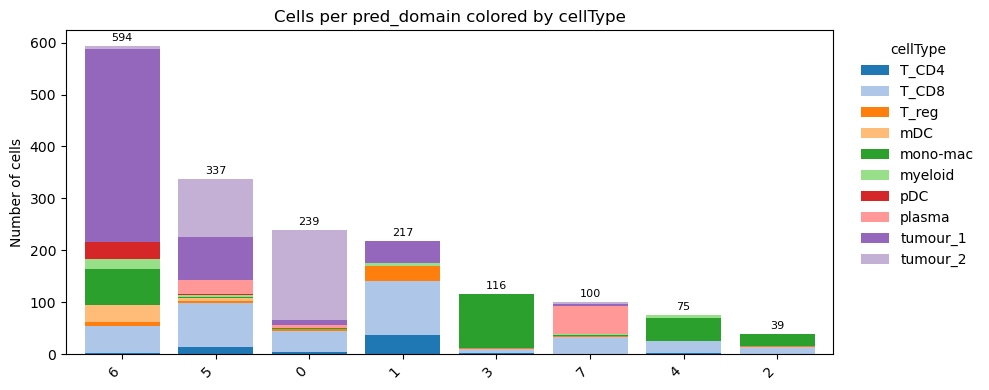

In [24]:
import numpy as np
import pandas as pd
import torch
import scanpy as sc

# ========= 0. 指定训练用的空间数据 =========
# 就是你之前训练 GAE / HMRF 用的那个 AnnData
adata_train = adata_prep          # <--- 关键：用你的 adata_prep

# ========= 1. 确保训练数据里有 log1p =========
if "log1p" not in adata_train.layers:
    ad_tmp = adata_train.copy()
    sc.pp.normalize_total(ad_tmp, target_sum=1e4)
    sc.pp.log1p(ad_tmp)
    adata_train.layers["log1p"] = ad_tmp.X.copy()
    del ad_tmp

# ========= 2. 定义 domain 类别顺序（要和训练时一致）=========
if "gae_classes" in adata_train.uns:
    classes = list(adata_train.uns["gae_classes"])
else:
    # 按你现在的设置，GMM+HMRF 的标签在 adata_prep.obs['domain']
    if "domain" in adata_train.obs.columns:
        label_key = "domain"
    elif "pred_gt" in adata_train.obs.columns:
        label_key = "pred_gt"
    else:
        raise KeyError("在 adata_prep.obs 里找不到用于训练的 domain 标签（比如 'domain' 或 'pred_gt'）")

    classes = list(adata_train.obs[label_key].astype("category").cat.categories)

print("GAE classes:", classes)

# ========= 3. 给 sc_adata 建 identity graph（全细胞；简单可靠）=========
device = next(model.parameters()).device

N = sc_adata.n_obs
idx = np.vstack([np.arange(N), np.arange(N)])
A_sc = torch.sparse_coo_tensor(
    idx,
    np.ones(N, dtype=np.float32),
    (N, N),
    dtype=torch.float32,
).coalesce()

# ========= 4. 用 _provisional_pred 对“全体 sc 细胞”做预测 =========
# 确保你上面已经定义的是这个版本的 _provisional_pred：
#   - 输入里有 adata_train
#   - 最后是 A = A_sc.to(device)
pred_idx_full, proba_full = _provisional_pred(
    sc_adata=sc_adata,
    adata_train=adata_train,
    model=model,
    train_layer="log1p",
    target_sum=1e4,
    device=device,
    A_sc=A_sc,
)

# ========= 5. 写回 sc_adata.obs =========
sc_adata.obs["pred_domain"] = pd.Categorical.from_codes(pred_idx_full, classes)

sc_adata.obsm["pred_domain_proba"] = pd.DataFrame(
    proba_full,
    index=sc_adata.obs_names,
    columns=classes,
)

print(sc_adata.obs["pred_domain"].value_counts())

# ========= 6. 全细胞统计图（每个 domain 的 cellType 构成）=========
plot_celltype_by_pred_domain(
    sc_adata,
    ct_key="pred_domain",   # x 轴: 预测 domain
    dom_key="cellType",     # 颜色: cellType
    sort_by_total=True,
    figsize=(10, 4),
    annotate=True,
)


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge
from matplotlib.collections import PatchCollection

def plot_spatial_pies(
    st_adata,
    spot_type_prop,                  # DataFrame: index = spot ids, columns = cell types, values in [0,1]
    coord_key='spatial',             # st_adata.obsm key with (x,y) coords
    radius=15,                       # pie radius in data units (adjust for your slide scale)
    alpha=0.95,
    max_types_per_spot=None,         # e.g., 4 -> keep top-4 types per spot for readability
    celltype_colors=None,            # dict {cell_type: color}; else auto palette
    background='white',              # background color of axes
    edgecolor='none',                # pie edge color
    linewidth=0.0,
    legend=True,
    figsize=(8, 8)
):
    # --- align and fetch coordinates ---
    coords = np.asarray(st_adata.obsm[coord_key])[:, :2]
    spot_index = st_adata.obs_names
    # align rows to st_adata order
    prop = spot_type_prop.reindex(spot_index).fillna(0.0).copy()

    # normalize rows to sum=1 (safety)
    s = prop.sum(axis=1).replace(0, np.nan)
    prop = prop.div(s, axis=0).fillna(0.0)

    cell_types = prop.columns.tolist()

    # --- colors ---
    if celltype_colors is None:
        # auto palette
        import matplotlib.cm as cm
        cmap = cm.get_cmap('tab20', len(cell_types))
        celltype_colors = {ct: cmap(i) for i, ct in enumerate(cell_types)}
    colors = [celltype_colors[ct] for ct in cell_types]

    # --- helper to create wedges for one spot ---
    def wedges_for_row(center, proportions):
        vals = proportions.values.astype(float)
        if max_types_per_spot is not None and max_types_per_spot < len(vals):
            # keep only top-k and renormalize
            topk = np.argpartition(-vals, max_types_per_spot-1)[:max_types_per_spot]
            mask = np.zeros_like(vals, dtype=bool); mask[topk] = True
            vals = np.where(mask, vals, 0.0)
            total = vals.sum()
            vals = vals / total if total > 0 else vals

        # build wedges (angles in degrees)
        wedges = []
        start = 0.0
        for frac, col in zip(vals, colors):
            if frac <= 0:
                continue
            theta = frac * 360.0
            wedges.append(Wedge(center, r=radius, theta1=start, theta2=start+theta, facecolor=col,
                                edgecolor=edgecolor, linewidth=linewidth))
            start += theta
        return wedges

    # --- make all pies ---
    patches = []
    for (x, y), (_, row) in zip(coords, prop.iterrows()):
        patches.extend(wedges_for_row((x, y), row))

    # --- plot ---
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_facecolor(background)
    pc = PatchCollection(patches, match_original=True, alpha=alpha)
    ax.add_collection(pc)

    # axes limits to fit all pies
    xmin, ymin = coords.min(axis=0) - radius*1.2
    xmax, ymax = coords.max(axis=0) + radius*1.2
    ax.set_xlim(xmin, xmax); ax.set_ylim(ymax, ymin)  # flip y if your image origin is top-left
    ax.set_aspect('equal')
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title('Spot-wise cell-type proportions (pie charts)')

    # legend
    if legend:
        # dummy handles
        from matplotlib.patches import Patch
        handles = [Patch(facecolor=celltype_colors[ct], label=ct) for ct in cell_types]
        ax.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, title='Cell type')

    plt.tight_layout()
    plt.show()
    return fig, ax


/tmp/ipykernel_28121/4077836901.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', len(cell_types))


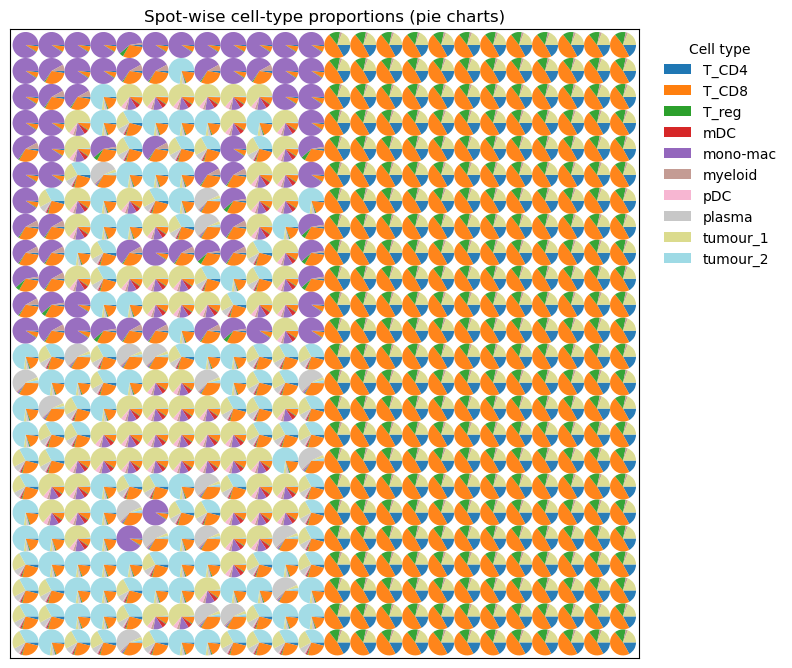

In [26]:
# ===== [26] 里已经跑了（示例）=====
# plot_celltype_by_pred_domain(sc_adata, ct_key='cellType', dom_key='pred_domain',
#                              sort_by_total=True, figsize=(10,4), annotate=True)

# ===== 直接接在 [26] block 后面的代码 =====

# 1) 用「刚才画柱状图用的同一个 sc_adata（未 filter）」计算：
#    每个 pred_domain 内的 cellType 比例分布
ct_key = 'cellType'
dom_key = 'pred_domain'

ct = sc_adata.obs[ct_key].astype('category')
dom = sc_adata.obs[dom_key].astype('category')

# 行：domain；列：cellType
M_dom_ct = pd.crosstab(dom, ct).astype(float)

# 每个 domain 内做归一化，得到「该 domain 的 cellType 组成比例」
dom_prop = M_dom_ct.div(M_dom_ct.sum(axis=1), axis=0)  # 行和=1

# 2) 把这些 domain-level 的 cellType 比例，复制到空间数据的每个 spot 上
#    要求：同一 domain 里的所有饼图长得一模一样
sp_dom_key = 'domain'   # adata_prep.obs 里对应 domain 的列名，如不同请改
spot_dom = adata_prep.obs[sp_dom_key].astype(str)

cell_types = dom_prop.columns

hard_prop_star = pd.DataFrame(
    0.0,
    index=adata_prep.obs_names,
    columns=cell_types,
    dtype=float
)

for d in dom_prop.index:
    mask = (spot_dom == str(d))
    if mask.any():
        # 该 domain 下所有 spot 的 cellType 比例都设成 dom_prop.loc[d]
        hard_prop_star.loc[mask, :] = dom_prop.loc[d].values

# 3) 规范一下：只对非全零行做一次归一化，确保每个 spot 行和为 1
row_sums = hard_prop_star.sum(axis=1)
valid = row_sums > 0
hard_prop_star.loc[valid, :] = hard_prop_star.loc[valid, :].div(row_sums[valid], axis=0)

# 4) 画空间饼图：
#    每个 domain 中的所有饼图使用相同的 cellType 比例（来自步骤 1 的结果）
_ = plot_spatial_pies(
    adata_prep,
    hard_prop_star,
    coord_key='spatial',
    radius=5,
    legend=True
)


In [27]:
print(sc_adata.obs['pred_domain'].value_counts())


pred_domain
6    594
5    337
0    239
1    217
3    116
7    100
4     75
2     39
Name: count, dtype: int64


{0, 1, 2, 3, 4, 5, 6, 7}
AnnData object with n_obs × n_vars = 1717 × 90052
    obs: 'spot_id', 'cell_type', 'CellType', 'cellType', 'pred_domain', 'pred_domain_prelim'
    uns: 'log1p', 'subsample_info'
    obsm: 'spatial', 'pred_domain_proba', 'gae_latent'
    layers: 'log1p'


/tmp/ipykernel_28121/1863032079.py:39: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(sc_adata.obs[col]):


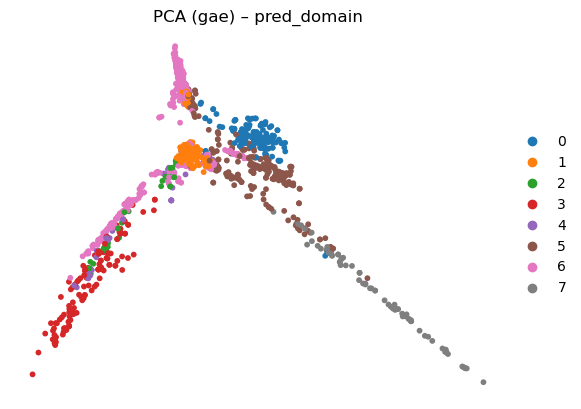

/tmp/ipykernel_28121/1863032079.py:39: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(sc_adata.obs[col]):


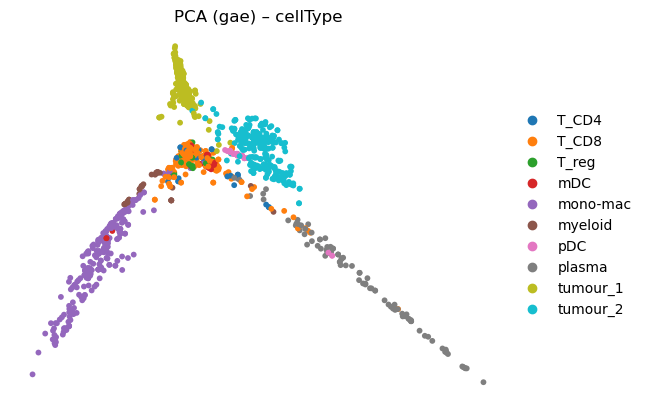

In [28]:
from sklearn.decomposition import PCA
import scanpy as sc
import anndata as ad

# 1. 读入 sc 数据
# sc_adata = ad.read_h5ad('/dongqishi/cellmap/MOB/MOB_sce.h5ad')

# 2. 确保有 log1p 层
if 'log1p' not in sc_adata.layers:
    tmp = sc_adata.copy()
    sc.pp.normalize_total(tmp, target_sum=1e4)
    sc.pp.log1p(tmp)
    sc_adata.layers['log1p'] = tmp.X.copy()
    del tmp

# 3. 用训练好的 model + adata_prep 做预测（不要传 model1/A_sc）
sc_adata = embed_and_predict_sc(
    sc_adata=sc_adata,
    adata_train=adata_prep,
    model=model,
    train_layer='log1p',
    k_sc=8,
    max_per_type=1000,
    target_sum=1e4,
    use_identity_graph=False,   # 或者保持默认，关键是不传旧图
    A_sc=None
)

print(sc_adata)

# 4. 拿 embedding 做 PCA & 可视化
Z = sc_adata.obsm['gae_latent']

pca = PCA(n_components=20, random_state=0)
sc_adata.obsm['X_pca_gae'] = pca.fit_transform(Z)

for col in ['pred_domain', 'cellType']:
    if col in sc_adata.obs:
        if not pd.api.types.is_categorical_dtype(sc_adata.obs[col]):
            sc_adata.obs[col] = sc_adata.obs[col].astype('category')
        sc.pl.embedding(
            sc_adata,
            basis='pca_gae',
            color=col,
            frameon=False,
            title=f'PCA (gae) – {col}'
        )


In [30]:
len(model1)

1717

Kept 1717 / 1717 cells (dropped 0).


/tmp/ipykernel_28121/1645276351.py:32: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(sc_adata_filtered.obs[col]):


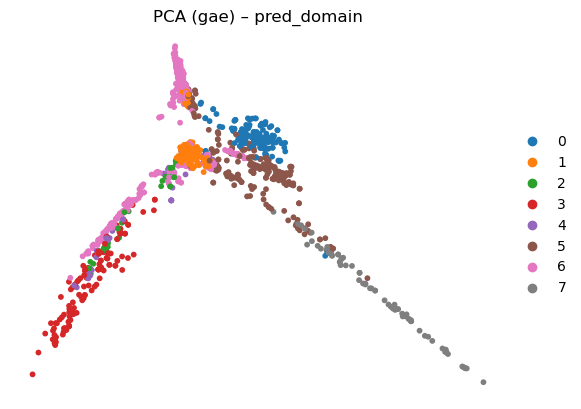

/tmp/ipykernel_28121/1645276351.py:32: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(sc_adata_filtered.obs[col]):


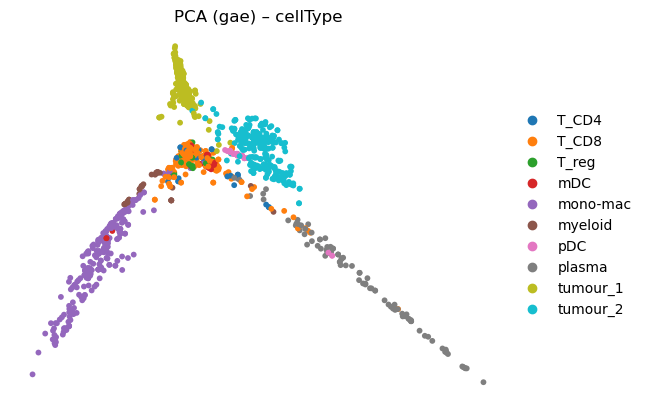

In [31]:
import numpy as np
import pandas as pd

# 1) Get the proba matrix (we stored it as a DataFrame; handle array too)
proba = sc_adata.obsm['pred_domain_proba']
if isinstance(proba, np.ndarray):
    proba_df = pd.DataFrame(proba, index=sc_adata.obs_names)
else:
    proba_df = proba  # already a DataFrame

# 2) Build keep mask: max prob per cell ≥ 0.5 (ignoring NaNs)
rowmax = proba_df.max(axis=1, skipna=True)
keep = rowmax >= 0.1

# 3) Subset AnnData
sc_adata_filtered = sc_adata[keep].copy()

# (optional) See how many were dropped
n_drop = (~keep).sum()
print(f"Kept {keep.sum()} / {len(keep)} cells (dropped {n_drop}).")

# 1) take the embedding you saved earlier
Z = sc_adata_filtered.obsm['gae_latent']   # shape (n_spots, z_dim)

# 2) PCA on the embedding
pca = PCA(n_components=20, random_state=0)
sc_adata_filtered.obsm['X_pca_gae'] = pca.fit_transform(Z)

# Plot PCA/UMAP of the sc embeddings, colored by predicted domain:
for col in ['pred_domain', 'cellType']:
    if col in sc_adata_filtered.obs:
        if not pd.api.types.is_categorical_dtype(sc_adata_filtered.obs[col]):
            sc_adata_filtered.obs[col] = sc_adata_filtered.obs[col].astype('category')
        sc.pl.embedding(sc_adata_filtered, basis='pca_gae', color=col, frameon=False, title=f'PCA (gae) – {col}')

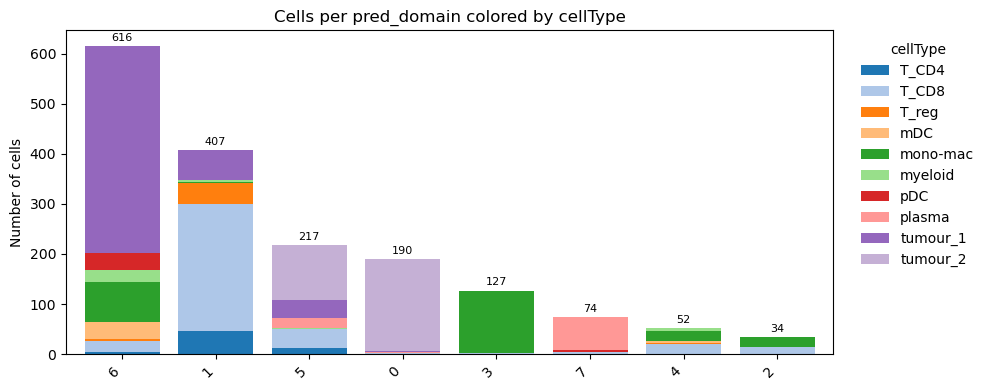

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def plot_celltype_by_pred_domain(adata, ct_key='cellType', dom_key='pred_domain',
                                 sort_by_total=True, figsize=(8,4), annotate=False):
    """
    Stacked bar plot:
      - x-axis: cell types
      - bar height: #cells per cell type
      - colored segments: counts of each pred_domain within the cell type
    """
    # sanity checks
    if ct_key not in adata.obs or dom_key not in adata.obs:
        raise KeyError(f"'{ct_key}' or '{dom_key}' not found in adata.obs")

    ct = adata.obs[ct_key].astype('category')
    dom = adata.obs[dom_key].astype('category')

    # counts matrix: rows=cellType, cols=pred_domain
    M = pd.crosstab(ct, dom).astype(int)

    # order cell types by total count
    totals = M.sum(axis=1)
    if sort_by_total:
        M = M.loc[totals.sort_values(ascending=False).index]
        totals = totals.loc[M.index]

    # colors (one color per domain)
    K = M.shape[1]
    cmap = ListedColormap(plt.cm.tab20.colors[:K])
    dom_colors = {d: cmap(i) for i, d in enumerate(M.columns)}

    # plot
    ax = plt.figure(figsize=figsize).gca()
    bottom = np.zeros(M.shape[0], dtype=float)
    x = np.arange(M.shape[0])

    for j, d in enumerate(M.columns):
        vals = M[d].to_numpy()
        ax.bar(x, vals, bottom=bottom, color=dom_colors[d], label=str(d), width=0.8, linewidth=0)
        bottom += vals

    ax.set_xticks(x)
    ax.set_xticklabels([str(i) for i in M.index], rotation=45, ha='right')
    ax.set_ylabel('Number of cells')
    ax.set_title(f'Cells per {ct_key} colored by {dom_key}')
    ax.legend(title=dom_key, bbox_to_anchor=(1.02,1), loc='upper left', frameon=False)
    ax.set_xlim(-0.6, len(x)-0.4)

    # optional annotations: show totals on top or percentages inside segments
    if annotate:
        for i, total in enumerate(totals):
            ax.text(i, total + max(totals)*0.01, str(total), ha='center', va='bottom', fontsize=8)
        # Example for percent labels per segment (commented; can clutter):
        # for i in range(M.shape[0]):
        #     cum = 0
        #     for d in M.columns:
        #         v = M.iloc[i][d]
        #         if v > 0:
        #             ax.text(i, cum + v/2, f"{100*v/float(totals.iloc[i]):.0f}%", ha='center', va='center', fontsize=7, color='white')
        #         cum += v

    plt.tight_layout()
    plt.show()

# usage:
plot_celltype_by_pred_domain(sc_adata_filtered, ct_key='pred_domain', dom_key='cellType', sort_by_total=True, figsize=(10,4), annotate=True)


/tmp/ipykernel_28121/4077836901.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', len(cell_types))


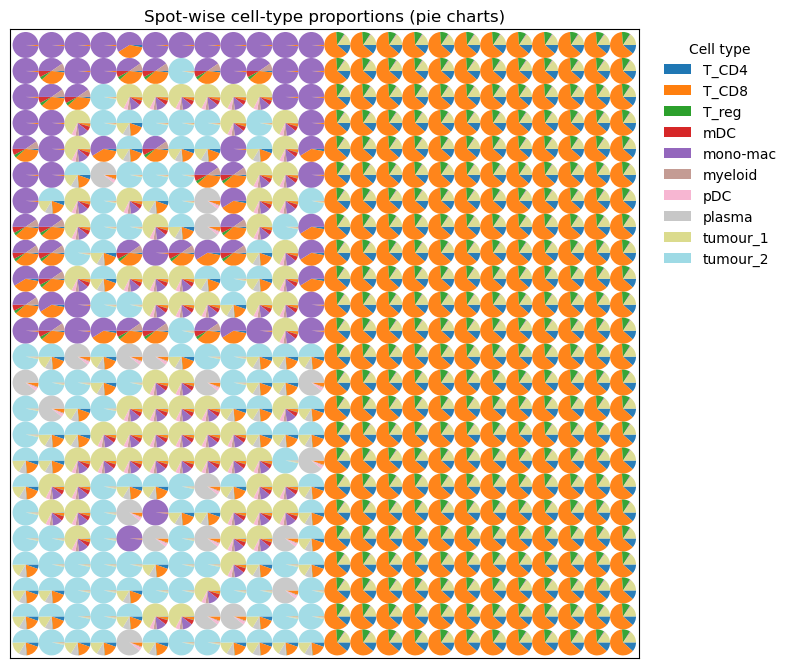

In [33]:
# ===== [26] 里已经跑了（示例）=====
# plot_celltype_by_pred_domain(sc_adata, ct_key='cellType', dom_key='pred_domain',
#                              sort_by_total=True, figsize=(10,4), annotate=True)

# ===== 直接接在 [26] block 后面的代码 =====

# 1) 用「刚才画柱状图用的同一个 sc_adata（未 filter）」计算：
#    每个 pred_domain 内的 cellType 比例分布
ct_key = 'cellType'
dom_key = 'pred_domain'

ct = sc_adata.obs[ct_key].astype('category')
dom = sc_adata.obs[dom_key].astype('category')

# 行：domain；列：cellType
M_dom_ct = pd.crosstab(dom, ct).astype(float)

# 每个 domain 内做归一化，得到「该 domain 的 cellType 组成比例」
dom_prop = M_dom_ct.div(M_dom_ct.sum(axis=1), axis=0)  # 行和=1

# 2) 把这些 domain-level 的 cellType 比例，复制到空间数据的每个 spot 上
#    要求：同一 domain 里的所有饼图长得一模一样
sp_dom_key = 'domain'   # adata_prep.obs 里对应 domain 的列名，如不同请改
spot_dom = adata_prep.obs[sp_dom_key].astype(str)

cell_types = dom_prop.columns

hard_prop_star = pd.DataFrame(
    0.0,
    index=adata_prep.obs_names,
    columns=cell_types,
    dtype=float
)

for d in dom_prop.index:
    mask = (spot_dom == str(d))
    if mask.any():
        # 该 domain 下所有 spot 的 cellType 比例都设成 dom_prop.loc[d]
        hard_prop_star.loc[mask, :] = dom_prop.loc[d].values

# 3) 规范一下：只对非全零行做一次归一化，确保每个 spot 行和为 1
row_sums = hard_prop_star.sum(axis=1)
valid = row_sums > 0
hard_prop_star.loc[valid, :] = hard_prop_star.loc[valid, :].div(row_sums[valid], axis=0)

# 4) 画空间饼图：
#    每个 domain 中的所有饼图使用相同的 cellType 比例（来自步骤 1 的结果）
_ = plot_spatial_pies(
    adata_prep,
    hard_prop_star,
    coord_key='spatial',
    radius=5,
    legend=True
)


In [34]:
import numpy as np
import pandas as pd
import anndata as ad
from scipy.sparse import issparse, csr_matrix

def _to_dense(X):
    return X.A if issparse(X) else np.asarray(X)

def _to_dense(X):
    if issparse(X):
        return X.toarray()   # 用 toarray() 代替 .A
    else:
        return np.asarray(X)

def _add_noise(X, sigma=0.01, nonneg=False, integer=False, clip_min=0.0):
    """
    Add small Gaussian noise. If `integer` is True, round to ints (for raw counts).
    """
    Xn = X + np.random.normal(0.0, sigma, size=X.shape).astype(np.float32)
    if nonneg:
        Xn = np.maximum(Xn, clip_min)
    if integer:
        Xn = np.rint(Xn).astype(np.int32)
    return Xn

def augment_domains_equalize(
    adata,
    domain_key='pred_domain',
    ct_key='cellType',
    layer=None,                 # None -> use .X ; else use adata.layers[layer]
    target_per_domain=None,     # None -> max count among domains; or int (e.g., 600)
    keep_ct_proportions=True,   # maintain cellType proportions within each domain
    noise_sigma=0.01,           # std of Gaussian jitter in the working space
    nonneg=True,                # clip to >=0 after noise
    integer=False,              # round to ints (set True if you're augmenting raw counts)
    random_state=0
):
    """
    Returns NEW AnnData where each `pred_domain` has (approximately) equal number of cells
    via oversampling with light noise. Metadata is copied; new obs_names get suffixes.
    """
    rng = np.random.default_rng(random_state)

    # --- inputs & working matrix ---
    assert domain_key in adata.obs, f"'{domain_key}' not found in adata.obs"
    assert ct_key in adata.obs, f"'{ct_key}' not found in adata.obs"

    dom = adata.obs[domain_key].astype('category')
    ct  = adata.obs[ct_key].astype('category')

    X_base = adata.layers[layer] if layer is not None else adata.X
    X_np = _to_dense(X_base).astype(np.float32)

    # --- counts & targets ---
    counts = dom.value_counts()
    if counts.empty:
        raise ValueError("No domains found.")
    if target_per_domain is None:
        target_per_domain = int(counts.max())
    target_per_domain = int(target_per_domain)

    # --- collect augmented rows ---
    aug_rows = []
    aug_obs  = []
    aug_uns  = []  # not used; placeholder if you want to track provenance per row

    # precompute index lists per (domain, cellType)
    df_idx = (
        pd.DataFrame({'row': np.arange(adata.n_obs), 'dom': dom.astype(str).values, 'ct': ct.astype(str).values})
        .groupby(['dom','ct'])['row'].apply(np.array)
    )
    # domain-only groups
    dom_groups = pd.Series(np.arange(adata.n_obs)).groupby(dom.astype(str).values).apply(np.array)

    for d, idx_dom in dom_groups.items():
        n_cur = idx_dom.size
        if n_cur >= target_per_domain:
            continue
        deficit = target_per_domain - n_cur

        if keep_ct_proportions:
            # split deficit across cell types proportionally (at least 1 if available)
            ct_counts = (ct.iloc[idx_dom].astype(str).value_counts()).reindex(ct.cat.categories.astype(str), fill_value=0)
            if ct_counts.sum() == 0:
                continue
            props = (ct_counts / ct_counts.sum()).to_numpy()
            alloc = np.floor(props * deficit).astype(int)
            # distribute remainder
            rem = deficit - alloc.sum()
            order = np.argsort(-props)  # highest proportion first
            for a in order:
                if rem == 0: break
                alloc[a] += 1; rem -= 1
            for ct_name, need in zip(ct.cat.categories.astype(str), alloc):
                if need <= 0: continue
                key = (d, ct_name)
                if key not in df_idx.index: 
                    continue
                pool = df_idx.loc[key]
                if pool.size == 0: 
                    continue
                # sample with replacement from this (domain, cellType) pool
                pick = rng.choice(pool, size=need, replace=True)
                aug_rows.append(pick)
        else:
            # ignore cellType proportions; sample from domain pool
            pick = rng.choice(idx_dom, size=deficit, replace=True)
            aug_rows.append(pick)

    if len(aug_rows) == 0:
        # nothing to add; return a copy
        return adata.copy()

    aug_idx = np.concatenate(aug_rows)
    X_aug  = X_np[aug_idx].copy()
    # X_aug  = _add_noise(X_aug, sigma=noise_sigma, nonneg=nonneg, integer=integer, clip_min=0.0)

    # --- build new obs for augmented cells (copy rows, tweak names) ---
    obs_aug = adata.obs.iloc[aug_idx].copy()
    # ensure unique names: append suffix with running counter
    base_names = adata.obs_names.to_numpy()
    aug_names = [f"{base_names[i]}__aug{j}" for j, i in enumerate(aug_idx)]
    obs_aug.index = pd.Index(aug_names)

    # --- assemble final AnnData: original + augmented ---
    # stack matrices
    X_new = np.vstack([X_np, X_aug]).astype(np.float32)
    obs_new = pd.concat([adata.obs, obs_aug], axis=0)
    var_new = adata.var.copy()

    # layers: if you augmented a layer, carry all layers forward (augmented layer updated, others duplicated)
    layers_new = {}
    for key, arr in adata.layers.items():
        arr_np = _to_dense(arr).astype(np.float32)
        if key == layer or (layer is None and key is None):
            # for the working layer (or .X if layer is None), use X_new later
            continue
        # duplicate selected rows for augmented records (noisy versions are only in the working matrix)
        layers_new[key] = np.vstack([arr_np, arr_np[aug_idx]]).astype(np.float32)

    # obsm/obsp: duplicate rows if present (no noise)
    obsm_new = {}
    for key, M in adata.obsm.items():
        M_np = np.asarray(M)
        obsm_new[key] = np.vstack([M_np, M_np[aug_idx]])

    obsp_new = {}
    for key, M in adata.obsp.items():
        # leave pairwise mats as-is (they won’t match new size); drop them
        # (recompute neighbors/graphs later on augmented data)
        continue

    # create AnnData
    ad_out = ad.AnnData(
        X=X_new if layer is None else _to_dense(adata.X),  # if augmenting .X, use X_new; else keep original .X
        obs=obs_new,
        var=var_new,
        obsm=obsm_new
    )
    # set layers
    if layer is None:
        # we already set X_new with noise; copy other layers
        for k, L in layers_new.items():
            ad_out.layers[k] = L
    else:
        # we augmented a specific layer: set that layer to X_new; copy other layers; update .X with original stacking
        ad_out.layers = layers_new
        ad_out.layers[layer] = X_new

    # provenance
    ad_out.uns = adata.uns.copy()
    ad_out.uns['domain_augmentation'] = {
        'domain_key': domain_key,
        'ct_key': ct_key,
        'target_per_domain': target_per_domain,
        'keep_ct_proportions': keep_ct_proportions,
        'noise_sigma': float(noise_sigma),
        'nonneg': bool(nonneg),
        'integer': bool(integer),
        'augmented_n': int(len(aug_idx)),
        'random_state': int(random_state),
    }

    return ad_out


In [35]:
sc_adata_filtered = augment_domains_equalize(
    sc_adata_filtered,
    domain_key='pred_domain',
    ct_key='cellType',
    layer=None,          # or None to work on .X
    target_per_domain=None, # None -> use max domain count
    keep_ct_proportions=True,
    noise_sigma=0.01,
    nonneg=True,
    integer=False,
    random_state=0
)

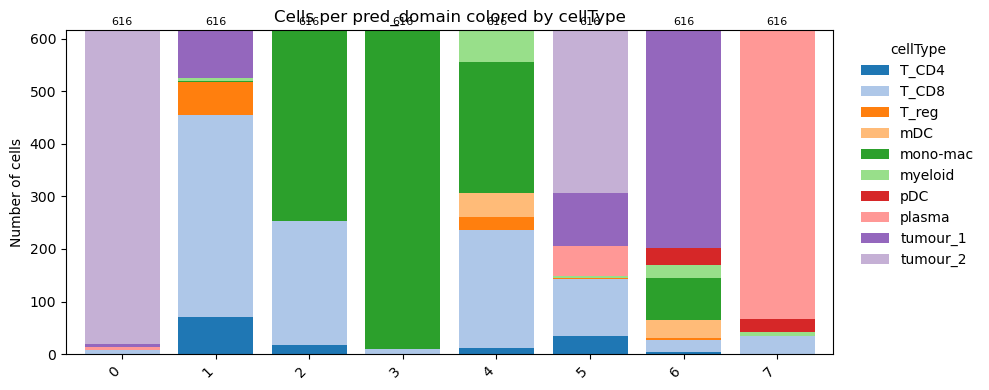

In [37]:

plot_celltype_by_pred_domain(sc_adata_filtered, ct_key='pred_domain', dom_key='cellType', sort_by_total=True, figsize=(10,4), annotate=True)


/tmp/ipykernel_28121/4077836901.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', len(cell_types))


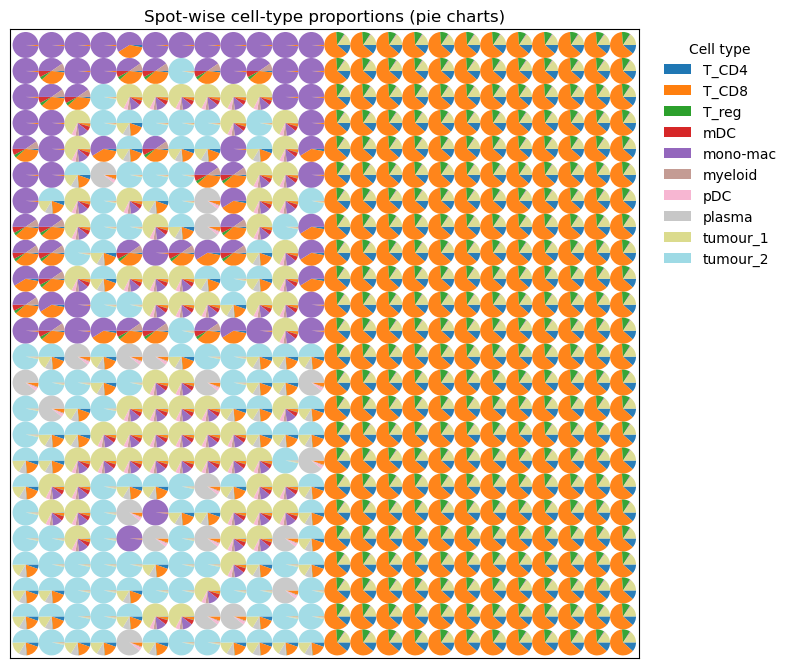

In [38]:
# ===== [26] 里已经跑了（示例）=====
# plot_celltype_by_pred_domain(sc_adata, ct_key='cellType', dom_key='pred_domain',
#                              sort_by_total=True, figsize=(10,4), annotate=True)

# ===== 直接接在 [26] block 后面的代码 =====

# 1) 用「刚才画柱状图用的同一个 sc_adata（未 filter）」计算：
#    每个 pred_domain 内的 cellType 比例分布
ct_key = 'cellType'
dom_key = 'pred_domain'

ct = sc_adata.obs[ct_key].astype('category')
dom = sc_adata.obs[dom_key].astype('category')

# 行：domain；列：cellType
M_dom_ct = pd.crosstab(dom, ct).astype(float)

# 每个 domain 内做归一化，得到「该 domain 的 cellType 组成比例」
dom_prop = M_dom_ct.div(M_dom_ct.sum(axis=1), axis=0)  # 行和=1

# 2) 把这些 domain-level 的 cellType 比例，复制到空间数据的每个 spot 上
#    要求：同一 domain 里的所有饼图长得一模一样
sp_dom_key = 'domain'   # adata_prep.obs 里对应 domain 的列名，如不同请改
spot_dom = adata_prep.obs[sp_dom_key].astype(str)

cell_types = dom_prop.columns

hard_prop_star = pd.DataFrame(
    0.0,
    index=adata_prep.obs_names,
    columns=cell_types,
    dtype=float
)

for d in dom_prop.index:
    mask = (spot_dom == str(d))
    if mask.any():
        # 该 domain 下所有 spot 的 cellType 比例都设成 dom_prop.loc[d]
        hard_prop_star.loc[mask, :] = dom_prop.loc[d].values

# 3) 规范一下：只对非全零行做一次归一化，确保每个 spot 行和为 1
row_sums = hard_prop_star.sum(axis=1)
valid = row_sums > 0
hard_prop_star.loc[valid, :] = hard_prop_star.loc[valid, :].div(row_sums[valid], axis=0)

# 4) 画空间饼图：
#    每个 domain 中的所有饼图使用相同的 cellType 比例（来自步骤 1 的结果）
_ = plot_spatial_pies(
    adata_prep,
    hard_prop_star,
    coord_key='spatial',
    radius=5,
    legend=True
)


In [40]:
import torch
import torch.nn.functional as F

def ot_match_prob(
    X, Y,
    metric: str = "cosine",      # "cosine" or "euclidean"
    eps: float = 0.05,           # entropic regularization
    iters: int = 80,             # Sinkhorn iterations
    row_mass=None,               # shape [N], default: ones
    col_mass=None,               # shape [M], default: uniform scaled so sum == N
    standardize: bool = False,   # z-score features before computing cost
    device:str = None,
    return_torch: bool = True,   # return torch.Tensor (else numpy)
):
    """
    X: (N, D) cells/features
    Y: (M, D) spots/features
    Returns P: (N, M) row-stochastic soft matching probabilities.
    """
    # ---- to torch ----
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    Xt = torch.as_tensor(X, dtype=torch.float32, device=device)
    Yt = torch.as_tensor(Y, dtype=torch.float32, device=device)
    N, D = Xt.shape; M, D2 = Yt.shape
    assert D == D2, "Feature dims must match"

    # ---- optional standardization (joint z-score) ----
    if standardize:
        Z = torch.cat([Xt, Yt], dim=0)
        mu = Z.mean(dim=0, keepdim=True)
        sd = Z.std(dim=0, keepdim=True) + 1e-6
        Xt = (Xt - mu) / sd
        Yt = (Yt - mu) / sd

    # ---- cost matrix C (smaller is better) ----
    if metric.lower() == "cosine":
        # cosine distance = 1 - cosine similarity
        Xt_n = F.normalize(Xt, dim=1)
        Yt_n = F.normalize(Yt, dim=1)
        C = 1.0 - torch.matmul(Xt_n, Yt_n.T)  # [N,M]
    elif metric.lower() == "euclidean":
        # squared Euclidean distance
        x2 = (Xt**2).sum(dim=1, keepdim=True)        # [N,1]
        y2 = (Yt**2).sum(dim=1, keepdim=True).T      # [1,M]
        C = x2 + y2 - 2.0 * Xt @ Yt.T                # [N,M]
        C = torch.clamp(C, min=0.0)
    else:
        raise ValueError("metric must be 'cosine' or 'euclidean'")

    # ---- entropic kernel ----
    K = torch.exp(-C / eps).clamp(min=1e-12)

    # ---- marginals ----
    if row_mass is None:
        r = torch.ones(N, device=device)
    else:
        r = torch.as_tensor(row_mass, dtype=torch.float32, device=device)
        assert r.shape == (N,)

    if col_mass is None:
        c = torch.full((M,), float(N) / M, device=device)
    else:
        c = torch.as_tensor(col_mass, dtype=torch.float32, device=device)
        assert c.shape == (M,)
        # scale so sum(c) ~= sum(r)
        c = c * (r.sum() / (c.sum() + 1e-12))

    # ---- Sinkhorn (balanced) ----
    u = torch.ones_like(r)
    v = torch.ones_like(c)
    for _ in range(iters):
        Kv = K @ v + 1e-12
        u = r / Kv
        KTu = K.T @ u + 1e-12
        v = c / KTu

    P = (u[:, None] * K) * v[None, :]        # [N,M]
    # numerical tidy: ensure exact row-stochastic if r==1
    if row_mass is None:
        P = P / (P.sum(dim=1, keepdim=True) + 1e-12)

    return P if return_torch else P.detach().cpu().numpy()


In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_cells_spatial(
    sc_adata,
    df_xy,                 # DataFrame indexed by cell IDs, with columns ['x','y']
    color_keys=('pred_domain','cellType'),
    s=6, alpha=0.85, figsize=(6,5), title_prefix=''
):
    # 1) align rows (keep only cells present in both)
    idx = sc_adata.obs_names.intersection(df_xy.index)
    if len(idx) == 0:
        raise ValueError("No overlapping cell IDs between sc_adata and df_xy.")
    xy = df_xy.loc[idx, ['x','y']].astype(float).to_numpy()

    def _plot_one(color_key):
        if color_key not in sc_adata.obs:
            raise KeyError(f"'{color_key}' not found in sc_adata.obs")
        cats = sc_adata.obs.loc[idx, color_key].astype('category')
        categories = list(cats.cat.categories)

        # color palette
        # use tab20/tab20b/tab20c concatenated if many categories
        base = list(plt.cm.tab20.colors) + list(plt.cm.tab20b.colors) + list(plt.cm.tab20c.colors)
        if len(categories) > len(base):
            # repeat if needed (rare)
            rep = int(np.ceil(len(categories)/len(base)))
            palette = (base * rep)[:len(categories)]
        else:
            palette = base[:len(categories)]
        color_map = dict(zip(categories, palette))

        plt.figure(figsize=figsize)
        for cat in categories:
            m = (cats == cat).to_numpy()
            if not m.any(): 
                continue
            plt.scatter(xy[m, 0], xy[m, 1],
                        s=s, alpha=alpha, c=[color_map[cat]],
                        label=str(cat), edgecolors='none')

        plt.gca().set_aspect('equal', adjustable='datalim')
        plt.xlabel('x'); plt.ylabel('y')
        ttl = f"{title_prefix}{color_key}"
        plt.title(ttl)
        # move legend outside if many entries
        ncat = len(categories)
        if ncat <= 12:
            plt.legend(frameon=False, markerscale=2)
        else:
            plt.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc='upper left', ncol=1, fontsize=8)
        plt.tight_layout()
        plt.show()

    # 2) make the two plots
    for key in color_keys:
        _plot_one(key)


In [43]:
import numpy as np
import pandas as pd
import torch
from scipy.optimize import linear_sum_assignment

# 你已有的 OT 内核（保持不变）
# def ot_match_prob(...): ...

def map_cells_to_spots_dom_ct(
    sc_adata, st_adata,
    emb_key_sc='gae_latent', emb_key_st='gae_latent',
    sc_domain_key='pred_domain', st_domain_key='gt',
    sc_type_key='cellType',
    metric='cosine', eps=0.05, iters=200,
    standardize=False,
    assignment_mode='argmax',   # === NEW: 'argmax' 或 'balanced'
    random_state=0
):
    """
    按 (domain × cellType) 分桶做 OT / 落位。
    Returns:
      P_full: dict[(domain, cellType)] -> torch.Tensor [Nc_bucket, Ns_domain]
      assigned_spot_for_cell: pd.Series (index=sc cells) -> mapped spot (global names)
      spot_type_prop: DataFrame (spots x cellTypes) proportions
    """
    rng = np.random.default_rng(random_state)

    # --- 取 embedding 与标签（与旧版相同） ---
    Z_sc = np.asarray(sc_adata.obsm[emb_key_sc], dtype=np.float32)
    Z_st = np.asarray(st_adata.obsm[emb_key_st], dtype=np.float32)

    sc_dom = sc_adata.obs[sc_domain_key].astype('category')
    st_dom = st_adata.obs[st_domain_key].astype('category')
    sc_ct  = sc_adata.obs[sc_type_key].astype('category')

    sc_index = sc_adata.obs_names
    st_index = st_adata.obs_names

    # === CHANGED: 交集 domain，且准备 cellType 类别 ===
    domains = [d for d in sc_dom.cat.categories if d in set(st_dom.cat.categories)]
    cell_types = list(sc_ct.cat.categories)
    if len(domains) == 0:
        raise ValueError("No overlapping domain labels between sc_adata and st_adata.")

    P_full = {}  # === CHANGED: 键变成 (domain, cellType)
    assigned_spot_for_cell = pd.Series(index=sc_index, dtype='object')

    for d in domains:  # 先按 domain 分桶（与旧版一致）
        idx_st = np.where(st_dom.values == d)[0]
        if len(idx_st) == 0:
            continue
        Y = Z_st[idx_st]  # Ns × D

        # === CHANGED: 再按 cellType 细分 ===
        for t in cell_types:
            # 当前桶：同 domain & 同 cellType 的 sc 索引
            mask_sc = (sc_dom.values == d) & (sc_ct.values == t)
            idx_sc = np.where(mask_sc)[0]
            if len(idx_sc) == 0:
                continue

            X = Z_sc[idx_sc]  # Nc × D

            # —— 该桶内做 OT（与旧版一致）——
            P = ot_match_prob(
                X, Y,
                metric=metric, eps=eps, iters=iters,
                row_mass=None, col_mass=None,
                standardize=standardize, device=None, return_torch=True
            )  # [Nc, Ns]
            P_full[(d, t)] = P

            # —— 该桶内的硬指派（=== CHANGED: 细粒度到 cellType 桶）——
            Pn = P.detach().cpu().numpy()
            Nc, Ns = Pn.shape

            if assignment_mode == 'balanced':
                # 均匀容量：该 cellType 在该 domain 内，尽量平均分摊到 Ns 个 spot
                q, r = divmod(Nc, Ns)
                caps = np.full(Ns, q, dtype=int)
                # 轻微扰动以避免总是前 r 个 spot 多 1（可按随机置换）
                order = np.arange(Ns)  # 或 rng.permutation(Ns)
                caps[order[:r]] += 1   # sum(caps) == Nc

                # 扩展列并跑匈牙利
                col_ids = np.repeat(np.arange(Ns), caps)      # 长度 Nc
                P_exp = Pn[:, col_ids]                        # Nc × Nc
                cost = -np.log(P_exp + 1e-12)
                row_ind, col_ind = linear_sum_assignment(cost)
                spot_local = col_ids[col_ind]                 # 每个细胞对应一个原 spot 索引（0..Ns-1）

            else:  # 'argmax'：简单快速
                spot_local = Pn.argmax(axis=1)

            # 写回全局 spot 名
            mapped_global = pd.Index(st_index[idx_st][spot_local])
            assigned_spot_for_cell.iloc[idx_sc] = mapped_global.values

    # 去掉没有落位的细胞（极端情况下）
    assigned_spot_for_cell = assigned_spot_for_cell.dropna()

    # --- 聚合成 spot × cellType 的计数/占比（与旧版一致） ---
    df_map = pd.DataFrame({
        'cell': assigned_spot_for_cell.index,
        'spot': assigned_spot_for_cell.values,
        'cellType': sc_ct.reindex(assigned_spot_for_cell.index).astype('category').astype(str)
    })
    counts = df_map.groupby(['spot', 'cellType']).size().unstack(fill_value=0)
    counts = counts.reindex(columns=cell_types, fill_value=0)

    spot_totals = counts.sum(axis=1).replace(0, np.nan)
    spot_type_prop = counts.div(spot_totals, axis=0).fillna(0.0)
    spot_type_prop = spot_type_prop.reindex(st_index, fill_value=0.0)

    # 可选：写回 SRT obs
    for ct in spot_type_prop.columns:
        st_adata.obs[f'prop_{ct}'] = spot_type_prop[ct].astype(np.float32)
    st_adata.obs['mapped_cell_count'] = counts.sum(axis=1).reindex(st_index).fillna(0).astype(int)

    return P_full, assigned_spot_for_cell, spot_type_prop


In [44]:
def build_spot_type_prop_soft(P_full, sc_adata, st_adata,
                              sc_domain_key='pred_domain', st_domain_key='domain',
                              sc_type_key='cellType'):
    st_dom = st_adata.obs[st_domain_key].astype('category')
    st_index = st_adata.obs_names
    cell_types = list(sc_adata.obs[sc_type_key].astype('category').cat.categories)
    out = pd.DataFrame(0.0, index=st_index, columns=cell_types)
    for (d, t), P in P_full.items():
        if d not in st_dom.cat.categories: continue
        idx_st = np.where(st_dom.values == d)[0]
        mass = P.detach().cpu().numpy().sum(axis=0)      # Ns_dom
        out.loc[st_index[idx_st], t] += mass
    row_sum = out.sum(axis=1).replace(0, np.nan)
    return out.div(row_sum, axis=0).fillna(0.0)

/tmp/ipykernel_28121/3578071492.py:41: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1762103288612/work/aten/src/ATen/Context.cpp:233.)
  C = 1.0 - torch.matmul(Xt_n, Yt_n.T)  # [N,M]
/tmp/ipykernel_28121/3578071492.py:73: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses 

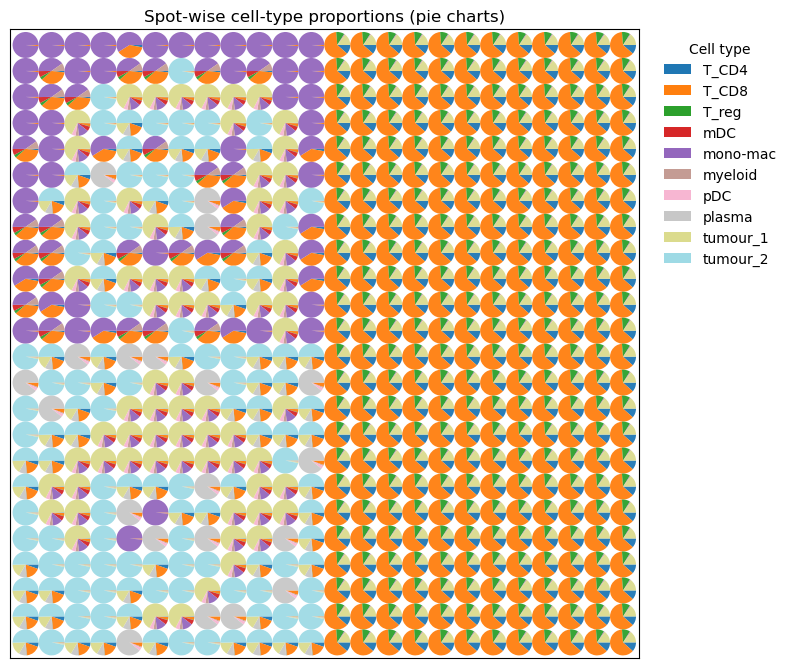

In [45]:
P_full, assigned, spot_type_prop = map_cells_to_spots_dom_ct(
    sc_adata_filtered, adata_prep,
    emb_key_sc='gae_latent', emb_key_st='gae_latent',
    sc_domain_key='pred_domain', st_domain_key='domain',
    sc_type_key='cellType',
    metric='cosine', eps=0.05, iters=200,   #0.05，200 10.30为了渐变改动
    standardize=False,
    assignment_mode='argmax'      # 或 'balanced'
)

spot_type_prop_soft = build_spot_type_prop_soft(P_full, sc_adata_filtered, adata_prep)
_ = plot_spatial_pies(adata_prep, spot_type_prop_soft, coord_key='spatial', radius=5, legend=True)

In [46]:
import numpy as np
import pandas as pd
from scipy.optimize import linear_sum_assignment

def _largest_remainder_rounding(x, total=None):
    """
    将非负实数向量 x 整数化，使和为 total（默认 round(sum(x))）。
    采用最大余数法（Hamilton method）。
    """
    x = np.asarray(x, dtype=float)
    x = np.clip(x, 0.0, None)
    if total is None:
        total = int(np.rint(x.sum()))
    base = np.floor(x).astype(int)
    rem = total - base.sum()
    if rem < 0:
        # 罕见：浮点误差或 total 过小，回退到直接 round 并微调
        base = np.round(x).astype(int)
        diff = total - base.sum()
        if diff == 0:
            return base
        # 按小数部分远离 round 的方向微调
        frac = x - np.floor(x)
        order = np.argsort(frac)  # 从小到大
        ptr = 0
        while diff != 0 and ptr < len(order):
            j = order[ptr] if diff > 0 else order[-(ptr+1)]
            base[j] += 1 if diff > 0 else -1
            diff = total - base.sum()
            ptr += 1
        return np.clip(base, 0, None)
    if rem == 0:
        return base
    # 分配给小数部分最大的前 rem 个
    frac = x - np.floor(x)
    order = np.argsort(-frac)  # 从大到小
    base[order[:rem]] += 1
    return base

def hard_assign_cells_from_soft(
    P_full, sc_adata, st_adata,
    sc_domain_key='pred_domain', st_domain_key='gt', sc_type_key='cellType',
    p_eps=1e-12, random_state=0
):
    """
    用软分配 P_full（键为 (domain, cellType)）在每个 domain 内一次性做容量约束匈牙利求解，
    返回每个细胞最终映射到的 spot（全局名）。
    """
    rng = np.random.default_rng(random_state)

    st_dom = st_adata.obs[st_domain_key].astype('category')
    sc_dom = sc_adata.obs[sc_domain_key].astype('category')
    sc_ct  = sc_adata.obs[sc_type_key].astype('category')

    st_index = st_adata.obs_names
    sc_index = sc_adata.obs_names

    domains = [d for d in sc_dom.cat.categories if d in set(st_dom.cat.categories)]

    assigned_spot = pd.Series(index=sc_index, dtype=object)

    for d in domains:
        # 该域的 spots（列顺序必须与 P_full 中一致）
        idx_st = np.where(st_dom.values == d)[0]
        Ns = len(idx_st)
        if Ns == 0:
            continue

        # 收集该域所有类型的 (cells, P)
        rows_all = []
        idx_sc_all = []

        for t in sc_ct.cat.categories:
            key = (d, t)
            if key not in P_full:
                continue
            P = P_full[key]
            # 统一成 numpy
            if hasattr(P, 'detach'):
                Pn = P.detach().cpu().numpy()
            else:
                Pn = np.asarray(P, dtype=float)

            # 行对应的细胞索引（与构造 P 时一致）
            mask_sc = (sc_dom.values == d) & (sc_ct.values == t)
            idx_sc = np.where(mask_sc)[0]
            if Pn.shape[0] != len(idx_sc) or Pn.shape[1] != Ns:
                raise ValueError(f"Shape mismatch at domain={d}, type={t}: "
                                 f"P={Pn.shape}, rows={len(idx_sc)}, cols={Ns}")
            rows_all.append(Pn)
            idx_sc_all.append(idx_sc)

        if not rows_all:
            continue

        P_all = np.vstack(rows_all)                 # (Nc_dom, Ns)
        idx_sc_all = np.concatenate(idx_sc_all)     # (Nc_dom,)
        Nc_dom = P_all.shape[0]

        # 列容量：按列和的期望人数整数化
        col_mass = P_all.sum(axis=0)                # (Ns,)
        if col_mass.sum() <= 0:
            # 退化情况：全 0，均匀容量
            caps_total = _largest_remainder_rounding(np.ones(Ns) * (Nc_dom / max(Ns,1)), total=Nc_dom)
        else:
            caps_total = _largest_remainder_rounding(col_mass, total=Nc_dom)

        # 扩展列并匈牙利
        col_ids = np.repeat(np.arange(Ns), caps_total)  # 长度 Nc_dom
        if col_ids.size != Nc_dom:
            raise RuntimeError("Capacity expansion size mismatch.")

        P_exp = P_all[:, col_ids]                       # (Nc_dom, Nc_dom)
        cost  = -np.log(P_exp + p_eps)

        row_ind, col_ind = linear_sum_assignment(cost)
        spot_local = col_ids[col_ind]                   # (Nc_dom,)

        # 写回全局 spot 名
        mapped_global = pd.Index(st_index[idx_st][spot_local])
        assigned_spot.iloc[idx_sc_all] = mapped_global.values

    # 极少数没覆盖的（比如没有 domain 交集），丢弃
    assigned_spot = assigned_spot.dropna()

    return assigned_spot


In [47]:
# 细胞→spot 的指派结果不变：每个细胞仍然分到它的那个 spot，没有丢任何一个，也不会多用。
#裁剪做的事：对已经分到第 j 个 spot 的细胞，如果该细胞的合成坐标离这个 spot 太远（超过允许半径），就沿着“细胞 → spot”的直线把点拉回到半径边界内。指派不变、容量不变、assigned_spot_for_cell_soft 不变。
#影响范围：只改变散点坐标图的“云”轮廓，让它不跑出原始位点边界太远；不会改变柱状/饼图里的spot_type_prop、spot_type_prop_soft等占比与计数。
import numpy as np
import pandas as pd
from scipy.spatial import KDTree, ConvexHull
from matplotlib.path import Path

# —— 通用：在任意“inside(p)”定义的区域内做 Bridson Poisson 采样 ——
def poisson_disk_in_region(inside_fn, mins, maxs, r, k=30, seed=0):
    rng = np.random.default_rng(seed)
    cell = r/np.sqrt(2)
    nx = int(np.ceil((maxs[0]-mins[0])/cell)); ny = int(np.ceil((maxs[1]-mins[1])/cell))
    grid = -np.ones((nx, ny), dtype=int)
    def gcoords(p): return (np.floor((p - mins)/cell)).astype(int)

    # seed
    for _ in range(2000):
        p0 = rng.uniform(mins, maxs)
        if inside_fn(p0): break
    else:
        raise RuntimeError("Failed to seed inside support region.")
    samples=[p0]; active=[0]; gx,gy=gcoords(p0); grid[gx,gy]=0

    def valid(p):
        if not inside_fn(p): return False
        gx,gy=gcoords(p)
        if gx<0 or gy<0 or gx>=nx or gy>=ny: return False
        i0=max(gx-2,0); i1=min(gx+3,nx); j0=max(gy-2,0); j1=min(gy+3,ny)
        for ix in range(i0,i1):
            for iy in range(j0,j1):
                s=grid[ix,iy]
                if s==-1: continue
                if np.linalg.norm(samples[s]-p) < r: return False
        return True

    while active:
        i = rng.choice(active)
        c = samples[i]; found=False
        for _ in range(k):
            rad = rng.uniform(r, 2*r); ang = rng.uniform(0, 2*np.pi)
            cand = c + rad*np.array([np.cos(ang), np.sin(ang)])
            if valid(cand):
                samples.append(cand); active.append(len(samples)-1)
                gx,gy=gcoords(cand); grid[gx,gy]=len(samples)-1; found=True; break
        if not found: active.remove(i)
    return np.asarray(samples, dtype=np.float32)

def _parse_xy_str(arr_like):
    s = pd.Series(arr_like, dtype=str).str.strip().str.lower().str.replace('×','x', regex=False)
    xy = np.vstack(s.str.split('x', n=1, expand=True).astype(float).to_numpy())
    return xy  # (N,2)

from typing import Optional  # <— 新增

def assign_cell_locations_from_coord_strings(
    assigned_spot_for_cell: pd.Series,
    min_dist=None, k_nn=8, seed=0,
    support_mode: str = 'union_disks',
    support_radius_factor: float = 1.1,
    clip_to_spot: bool = False,
    clip_radius_factor: float = 1.3,
    clip_radius_abs: Optional[float] = None  # <— 这里改了
):
    """
    返回细胞合成坐标，并带两道“防越界”护栏：
      1) 采样支持域可选 union_of_disks（更贴着原始位点边界）；
      2) 赋值后将点裁剪到每个 spot 的局部半径之内（可自动估计或用绝对值）。
    """
    rng = np.random.default_rng(seed)

    # 1) capacities & unique spots
    spot_str = assigned_spot_for_cell.astype(str).values
    unique_spots, inverse = np.unique(spot_str, return_inverse=True)
    cap = np.bincount(inverse)
    S = len(unique_spots); N = len(spot_str)
    print(unique_spots[:5])
    
    # 2) parse spot coordinates
    XY_spot = _parse_xy_str(unique_spots)  # (S,2)

    # 2.1 估计全局/局部最近邻尺度（用于支持域半径与裁剪半径）
    tree_spot = KDTree(XY_spot)
    # 最近邻（排除自身，取第2个）
    dists, _ = tree_spot.query(XY_spot, k=min(4, S))  # (S, k)
    # 对每个 spot 的局部尺度取第2小距离（或第k小的中位数）
    local_scale = dists[:, 1] if dists.shape[1] >= 2 else np.full(S, np.median(dists))
    global_scale = np.median(local_scale) if S > 1 else (np.max(XY_spot, axis=0) - np.min(XY_spot, axis=0)).mean()

    # 3) 构造采样支持域
    if support_mode == 'convex_hull' or S < 3:
        # 原来的凸包（S<3 时做轻微外扩的矩形）
        if S >= 3:
            hull = ConvexHull(XY_spot)
            poly = XY_spot[hull.vertices]
            Ppoly = Path(poly)
            mins = poly.min(axis=0); maxs = poly.max(axis=0)
            inside_fn = lambda p: Ppoly.contains_point(p)
        else:
            mins = XY_spot.min(axis=0); maxs = XY_spot.max(axis=0)
            pad = 0.05*(maxs - mins + 1e-6)
            mins = mins - pad; maxs = maxs + pad
            inside_fn = lambda p: (mins[0] <= p[0] <= maxs[0]) and (mins[1] <= p[1] <= maxs[1])
    elif support_mode == 'union_disks':
        # 用“spot 的并集缓冲圆”作为支持域：p 若在任一圆内即有效
        R = support_radius_factor * global_scale
        mins = XY_spot.min(axis=0) - R
        maxs = XY_spot.max(axis=0) + R
        def inside_fn(p):
            # 快速近邻查询：如果与最近 spot 的距离 <= R 就算 inside
            dist, _ = tree_spot.query(p, k=1)
            return dist <= R
    else:
        raise ValueError(f"Unknown support_mode: {support_mode}")

    # 4) blue-noise 采样（≈N）
    # 若未指定 min_dist，则按支持域面积粗估（凸包情况）；union_disks 下用全局尺度
    if min_dist is None:
        if support_mode == 'convex_hull' and S >= 3:
            area = ConvexHull(XY_spot).volume
            min_dist = 0.9*np.sqrt(area / (N*np.pi))
        else:
            min_dist = 0.6 * global_scale  # 更保守一些，避免过稀
    pts = poisson_disk_in_region(inside_fn, mins, maxs, r=min_dist, k=30, seed=seed)
    tries=0
    while pts.shape[0] < N and tries < 5:
        min_dist *= 0.9
        pts = poisson_disk_in_region(inside_fn, mins, maxs, r=min_dist, k=30, seed=seed+tries+1)
        tries += 1
    if pts.shape[0] > N:
        pts = pts[rng.choice(pts.shape[0], size=N, replace=False)]
    elif pts.shape[0] < N:
        # 兜底：均匀拒绝采样直到补足
        extra=[]
        for _ in range(200000):
            q = rng.uniform(mins, maxs)
            if inside_fn(q): extra.append(q)
            if len(extra)+pts.shape[0] >= N: break
        if extra: pts = np.vstack([pts, np.asarray(extra, dtype=np.float32)])

    # 5) capacity-respecting 最近邻分配到 spots（与你原逻辑一致）
    tree = KDTree(XY_spot)
    kq = min(k_nn, S)
    _, knn_idx = tree.query(pts, k=kq)
    if knn_idx.ndim == 1: knn_idx = knn_idx[:, None]

    remaining = cap.copy()
    assigned_point_to_spot = -np.ones(N, dtype=int)
    for p in rng.permutation(N):
        for j in knn_idx[p]:
            if remaining[j] > 0:
                assigned_point_to_spot[p] = j
                remaining[j] -= 1
                break
        if assigned_point_to_spot[p] < 0:
            order = np.argsort(np.linalg.norm(XY_spot - pts[p], axis=1))
            for j in order:
                if remaining[j] > 0:
                    assigned_point_to_spot[p] = j
                    remaining[j] -= 1
                    break
    if (assigned_point_to_spot < 0).any() or remaining.sum() != 0:
        raise RuntimeError("Capacity assignment failed; try larger k_nn or smaller min_dist.")

    # 6) （新增）按 spot 做半径裁剪，限制每个 cell 不要离其 spot 太远
    if clip_to_spot:
        # 每个 spot 的裁剪半径：优先绝对值，其次自适应（= factor * 局部最近邻尺度）
        if clip_radius_abs is not None:
            r_clip = np.full(S, float(clip_radius_abs), dtype=float)
        else:
            r_clip = clip_radius_factor * local_scale  # (S,)

        # 投影：dist > r_clip_j 时，沿方向缩放到半径上
#         delta = pts - XY_spot[assigned_point_to_spot]
#         dist = np.linalg.norm(delta, axis=1) + 1e-12
#         r_allowed = r_clip[assigned_point_to_spot]
#         over = dist > r_allowed
#         if np.any(over):
#             scale = (r_allowed[over] / dist[over])[:, None]
#             pts[over] = XY_spot[assigned_point_to_spot[over]] + delta[over] * scale
            
            
            
            
            
            
    if clip_to_spot:
        if clip_radius_abs is not None:
            r_clip = np.full(S, float(clip_radius_abs), dtype=float)
        else:
            r_clip = clip_radius_factor * local_scale  # (S,)

        delta = pts - XY_spot[assigned_point_to_spot]
        dist  = np.linalg.norm(delta, axis=1) + 1e-12
        r_allowed = r_clip[assigned_point_to_spot]
        over = dist > r_allowed
        if np.any(over):
            u = rng.random(over.sum())                       # 0-1
            scale = (r_allowed[over] * np.sqrt(u) / dist[over])[:, None]
            # 关键：√u 让半径在 [0, r_allowed] 均匀分布（圆盘均匀）
            pts[over] = XY_spot[assigned_point_to_spot[over]] + delta[over] * scale








    # 7) map points to cells per spot；随机配对避免偏置
    cell_xy = np.zeros((N,2), dtype=np.float32)
    per_spot_points = {j: [] for j in range(S)}
    for p, j in enumerate(assigned_point_to_spot):
        per_spot_points[j].append(p)
    for j in range(S):
        pts_j = np.asarray(per_spot_points[j], int)
        cells_j = np.where(inverse == j)[0]
        m = min(len(pts_j), len(cells_j))
        perm = rng.permutation(m)
        cell_xy[cells_j[:m]] = pts[pts_j[perm]]

    return pd.DataFrame(cell_xy, index=assigned_spot_for_cell.index, columns=['x','y'])




#################################################################
import numpy as np
import pandas as pd

def assign_cell_locations_from_coord_strings(
    assigned_spot_for_cell: pd.Series,
    sc_adata,
    st_adata=None,
    sc_spatial_key: str = "spatial",
    st_spatial_key: str = "spatial",
    place_mode: str = "use_sc_spatial",   # "use_sc_spatial" 或 "shift_to_spot"
):
    """
    用 sc_adata.obsm[sc_spatial_key] 作为细胞坐标来源。
    - place_mode="use_sc_spatial": 直接返回单细胞真实坐标（不依赖 spot 坐标）
    - place_mode="shift_to_spot": 让每个 spot 内的细胞云团整体平移到该 spot 的中心（需要 st_adata）
    """

    # 1) 对齐细胞坐标顺序到 assigned_spot_for_cell.index
    if not hasattr(sc_adata, "obs_names"):
        raise ValueError("sc_adata 必须是 AnnData，且包含 obs_names。")
    if sc_spatial_key not in sc_adata.obsm:
        raise ValueError(f"sc_adata.obsm 中找不到 {sc_spatial_key!r}。")

    cell_names = sc_adata.obs_names
    idx = cell_names.get_indexer(assigned_spot_for_cell.index)
    if (idx < 0).any():
        bad = assigned_spot_for_cell.index[np.where(idx < 0)[0][:5]]
        raise ValueError(
            "assigned_spot_for_cell.index 与 sc_adata.obs_names 不匹配，无法对齐坐标。"
            f" 例子: {list(bad)}"
        )

    XY_cell = np.asarray(sc_adata.obsm[sc_spatial_key], dtype=float)[idx, :2]
    out = pd.DataFrame(XY_cell, index=assigned_spot_for_cell.index, columns=["x", "y"])

    # 2) 只用 sc 坐标：直接返回
    if place_mode == "use_sc_spatial":
        return out

    # 3) 平移到 spot：需要 st_adata 的 spot 中心坐标
    if place_mode != "shift_to_spot":
        raise ValueError(f"未知 place_mode: {place_mode!r}")

    if st_adata is None:
        raise ValueError("place_mode='shift_to_spot' 需要传入 st_adata。")
    if st_spatial_key not in st_adata.obsm:
        raise ValueError(f"st_adata.obsm 中找不到 {st_spatial_key!r}。")

    XY_spot_all = np.asarray(st_adata.obsm[st_spatial_key], dtype=float)[:, :2]
    n_spots = XY_spot_all.shape[0]

    # 3.1 把 assigned_spot_for_cell 的值映射成 spot 坐标
    spot_assign = assigned_spot_for_cell.copy()

    # 你的 spot 值像 141/112/...，优先按“行号/整数索引”处理
    spot_idx = pd.to_numeric(spot_assign, errors="coerce").astype("Int64")

    if spot_idx.notna().all():
        spot_idx_np = spot_idx.to_numpy(dtype=int)
        if (spot_idx_np < 0).any() or (spot_idx_np >= n_spots).any():
            raise ValueError(
                "assigned_spot_for_cell 里的 spot 索引超出 st_adata 范围。"
                f" st_adata.n_obs={n_spots}, 索引最小/最大={spot_idx_np.min()}/{spot_idx_np.max()}"
            )
        spot_xy_per_cell = XY_spot_all[spot_idx_np]
    else:
        # 如果不是整数索引，则按 spot 名称匹配 st_adata.obs_names
        spot_names = st_adata.obs_names
        j = spot_names.get_indexer(spot_assign.astype(str))
        if (j < 0).any():
            bad = spot_assign.iloc[np.where(j < 0)[0][:5]].tolist()
            raise ValueError(
                "assigned_spot_for_cell 的 spot 名在 st_adata.obs_names 中找不到。"
                f" 例子: {bad}"
            )
        spot_xy_per_cell = XY_spot_all[j]

    # 3.2 对每个 spot 分组，把该组细胞云团的均值平移到 spot 中心
    out_shifted = out.copy()
    spot_key = spot_assign.astype(str).to_numpy()
    for s in np.unique(spot_key):
        m = (spot_key == s)
        if not np.any(m):
            continue
        center_cell = out.loc[m, ["x", "y"]].to_numpy().mean(axis=0)
        center_spot = spot_xy_per_cell[m].mean(axis=0)  # 同一 spot 内应相同，取均值更稳
        delta = center_spot - center_cell
        out_shifted.loc[m, ["x", "y"]] = out.loc[m, ["x", "y"]].to_numpy() + delta

    return out_shifted


In [48]:
assigned_spot_for_cell_soft = hard_assign_cells_from_soft(
    P_full,
    sc_adata=sc_adata_filtered,
    st_adata=adata_prep,
    sc_domain_key='pred_domain',
    st_domain_key='domain',
    sc_type_key='cellType',
    p_eps=1e-12,
    random_state=0
)


# out_soft = assign_cell_locations_from_coord_strings(
#     assigned_spot_for_cell_soft,
#     min_dist=None,
#     k_nn=8,
#     seed=0,
#     support_mode='union_disks',       # 采样只在“spot 的缓冲区并集”内
#     support_radius_factor=1.1,        # 并集半径=1.1×中位最近邻距（可调小更紧）
#     clip_to_spot=True,                # 赋值后再对每个点做半径裁剪
#     clip_radius_factor=1.3,           # 每个 spot 的裁剪半径=1.3×其局部最近邻尺度
#     clip_radius_abs=None              # 也可以直接给绝对像素半径，例如 2.5
# )

#############
out_soft = assign_cell_locations_from_coord_strings(
    assigned_spot_for_cell_soft,
    sc_adata=sc_adata_filtered,
    place_mode="use_sc_spatial",
)


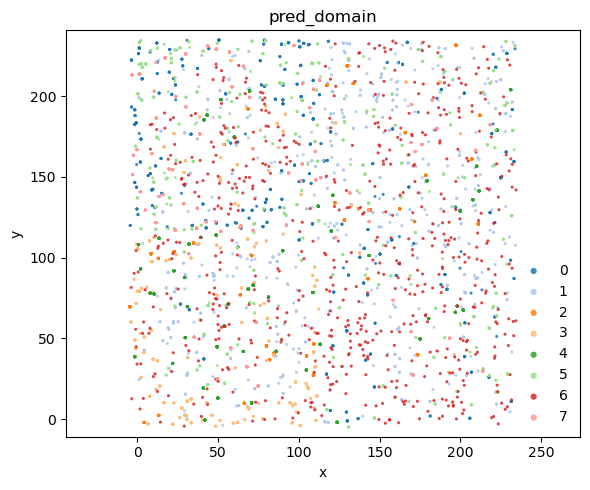

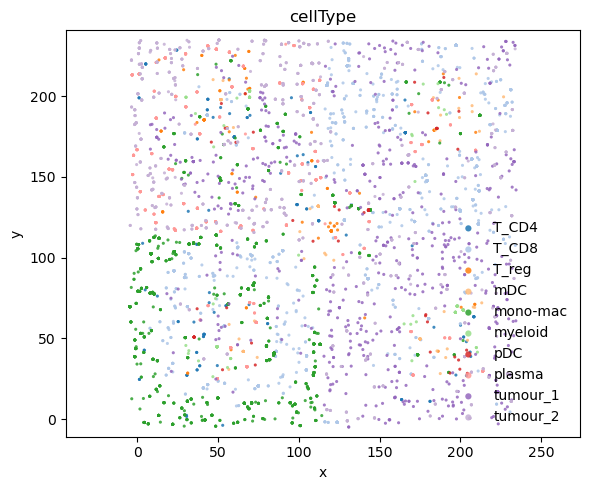

In [49]:
plot_cells_spatial(sc_adata_filtered, out_soft, color_keys=('pred_domain','cellType'), s=5)

In [50]:
sc_adata_filtered.obs

,spot_id,cell_type,CellType,cellType,pred_domain,pred_domain_prelim
0_1,0,mono-mac,mono-mac,mono-mac,2,3
1_11,1,mono-mac,mono-mac,mono-mac,6,6
1_16,1,mono-mac,mono-mac,mono-mac,3,3
1_17,1,mono-mac,mono-mac,mono-mac,2,2
2_23,2,mono-mac,mono-mac,mono-mac,3,3
...,...,...,...,...,...,...
371_3666__aug3206,371,plasma,plasma,plasma,7,7
530_5295__aug3207,530,plasma,plasma,plasma,7,7
510_5084__aug3208,510,plasma,plasma,plasma,7,7
297_2925__aug3209,297,plasma,plasma,plasma,7,7


In [51]:
sc_adata.obs

,spot_id,cell_type,CellType,cellType,pred_domain,pred_domain_prelim
0_1,0,mono-mac,mono-mac,mono-mac,2,3
1_11,1,mono-mac,mono-mac,mono-mac,6,6
1_16,1,mono-mac,mono-mac,mono-mac,3,3
1_17,1,mono-mac,mono-mac,mono-mac,2,2
2_23,2,mono-mac,mono-mac,mono-mac,3,3
...,...,...,...,...,...,...
575_5731,575,tumour_1,tumour_1,tumour_1,1,5
575_5732,575,tumour_1,tumour_1,tumour_1,5,5
575_5736,575,tumour_2,tumour_2,tumour_2,0,0
575_5737,575,tumour_1,tumour_1,tumour_1,1,5


In [52]:
# 记录SIMO算法总流程结束时间
simo_end_time = time.time()
elapsed_seconds = simo_end_time - simo_start_time
print(f"算法总流程耗时: {elapsed_seconds:.2f} 秒")

算法总流程耗时: 60.13 秒


/tmp/ipykernel_28121/3738156165.py:13: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(sc_adata.obs['cellType']):


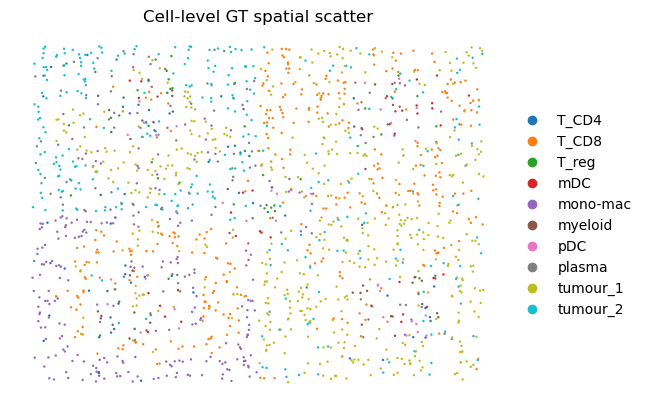

In [53]:
import scanpy as sc
import pandas as pd

# 确保标签是 category
if 'cellType' not in sc_adata.obs.columns:
    if 'CellType' in sc_adata.obs.columns:
        sc_adata.obs['cellType'] = sc_adata.obs['CellType'].astype(str)
    elif 'cell_type' in sc_adata.obs.columns:
        sc_adata.obs['cellType'] = sc_adata.obs['cell_type'].astype(str)
    else:
        raise KeyError("sc_adata.obs 中没有 cellType / CellType / cell_type")

if not pd.api.types.is_categorical_dtype(sc_adata.obs['cellType']):
    sc_adata.obs['cellType'] = sc_adata.obs['cellType'].astype('category')

# 直接画 spatial scatter
sc.pl.embedding(
    sc_adata,
    basis='spatial',
    color='cellType',
    frameon=False,
    size=12,
    title='Cell-level GT spatial scatter'
)

In [54]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    adjusted_mutual_info_score,
    mutual_info_score,
    homogeneity_score,
    completeness_score,
    v_measure_score
)

def clustering_metrics_from_obs(
    adata,
    true_key="gt",
    pred_key="domain",
    exclude_true_labels=("Unknown",),
    exclude_pred_labels=(),
    dropna=True,
    average_method="arithmetic",   # NMI/AMI 的 average_method
):
    """
    计算：ARI, NMI, AMI, MI, homogeneity, completeness, v-measure

    - exclude_true_labels: 过滤 true_key 中不想参与评估的标签（如 'Unknown'）
    - exclude_pred_labels: 同理过滤 pred_key
    - dropna: 是否丢弃 NA
    """
    y_true = adata.obs[true_key].astype(str)
    y_pred = adata.obs[pred_key].astype(str)

    mask = np.ones(len(adata), dtype=bool)

    if dropna:
        mask &= y_true.notna().values & y_pred.notna().values

    if exclude_true_labels:
        mask &= ~y_true.isin(list(exclude_true_labels)).values

    if exclude_pred_labels:
        mask &= ~y_pred.isin(list(exclude_pred_labels)).values

    y_true_m = y_true[mask].values
    y_pred_m = y_pred[mask].values

    if len(y_true_m) == 0:
        raise ValueError("过滤后没有样本可用于计算指标，请检查过滤条件 / 标签列名。")

    res = {
        "n_used": int(len(y_true_m)),
        "n_true_classes": int(pd.Series(y_true_m).nunique()),
        "n_pred_classes": int(pd.Series(y_pred_m).nunique()),
        "ARI": adjusted_rand_score(y_true_m, y_pred_m),
        "NMI": normalized_mutual_info_score(y_true_m, y_pred_m, average_method=average_method),
        "AMI": adjusted_mutual_info_score(y_true_m, y_pred_m, average_method=average_method),
        "MI": mutual_info_score(y_true_m, y_pred_m),  # 未归一化、未校正的互信息（量纲依赖类别数）
        "homogeneity": homogeneity_score(y_true_m, y_pred_m),
        "completeness": completeness_score(y_true_m, y_pred_m),
        "v_measure": v_measure_score(y_true_m, y_pred_m),
    }

    # 交叉表（可选，但很有用）
    ctab = pd.crosstab(pd.Series(y_true_m, name=true_key),
                       pd.Series(y_pred_m, name=pred_key))

    return pd.Series(res), ctab


# === 按你 notebook 的设定：gt vs domain，过滤 Unknown ===
metrics, crosstab = clustering_metrics_from_obs(
    adata_prep,
    true_key="gt",
    pred_key="domain",
    exclude_true_labels=("Unknown",),   # 与你现有代码一致
)

print(metrics)
display(crosstab)


n_used            576.000000
n_true_classes     10.000000
n_pred_classes      8.000000
ARI                 0.246460
NMI                 0.372316
AMI                 0.349826
MI                  0.632377
homogeneity         0.350627
completeness        0.396864
v_measure           0.372316
dtype: float64


domain,0,1,2,3,4,5,6,7
gt,,,,,,,,
T_CD4,5,6,0,0,0,3,0,1
T_CD8,12,93,0,0,0,10,28,0
T_reg,0,6,0,1,0,2,1,0
mDC,5,8,0,0,0,2,0,0
mono-mac,0,5,11,37,23,1,1,0
myeloid,2,7,1,0,2,0,1,0
pDC,2,7,0,0,0,2,0,0
plasma,0,7,0,0,0,1,0,11
tumour_1,3,141,0,0,0,2,37,0


In [55]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from skimage.metrics import structural_similarity as ssim

# =========================================================
# 0) 你 notebook 里已经有这些对象：
#    - adata               : 原始 ST AnnData（GT proportions 在这里）
#    - adata_prep          : 训练/映射后的 ST AnnData（spatial 坐标在这里）
#    - spot_type_prop_soft : 预测的 spot × celltype 比例
#
# 如果你想评估“硬分配”结果，把下面一行改成：
# pred_df = spot_type_prop.copy()
# =========================================================
pred_df = spot_type_prop_soft.copy()

# 输出目录（可改）
out_dir = Path("./e_metrics_full")
out_dir.mkdir(parents=True, exist_ok=True)

out_per = out_dir / "e_metrics_per_celltype.csv"
out_sum = out_dir / "e_metrics_summary.csv"
out_variants = out_dir / "e_metrics_summary_variants.csv"
out_box = out_dir / "e_metrics_boxplot.png"
out_heat_gt_pred = out_dir / "qc_heatmap_gt_vs_pred.png"
out_heat_diff = out_dir / "qc_heatmap_diff.png"


# =========================================================
# 1) 从 adata 提取 GT: spot × celltype proportions
# =========================================================
def get_truth_prop_from_adata(
    adata,
    obsm_key="proportions",
    names_key="proportion_names",
):
    if obsm_key not in adata.obsm:
        raise KeyError(f"adata.obsm['{obsm_key}'] 不存在。")

    X = adata.obsm[obsm_key]

    if isinstance(X, pd.DataFrame):
        truth_df = X.copy()
        truth_df.index = adata.obs_names.astype(str)
        if truth_df.columns.isnull().any():
            if names_key in adata.uns:
                truth_df.columns = list(map(str, adata.uns[names_key]))
        return truth_df

    X = np.asarray(X)

    if X.ndim != 2:
        raise ValueError(f"adata.obsm['{obsm_key}'] 应为二维矩阵，当前 shape={X.shape}")

    if names_key in adata.uns:
        celltype_names = list(map(str, adata.uns[names_key]))
    else:
        celltype_names = [f"celltype_{i}" for i in range(X.shape[1])]

    if len(celltype_names) != X.shape[1]:
        raise ValueError(
            f"cell type 名称数({len(celltype_names)})和 proportions 列数({X.shape[1]})不一致。"
        )

    truth_df = pd.DataFrame(
        X,
        index=adata.obs_names.astype(str),
        columns=celltype_names,
    )
    return truth_df


truth_df = get_truth_prop_from_adata(adata)

# 统一 index / columns 类型
truth_df.index = truth_df.index.astype(str)
truth_df.columns = truth_df.columns.astype(str)

pred_df = pred_df.copy()
pred_df.index = pred_df.index.astype(str)
pred_df.columns = pred_df.columns.astype(str)


# =========================================================
# 2) 取空间坐标
#    优先用 adata_prep.obsm['spatial']；没有就退回 adata
# =========================================================
st_for_coord = adata_prep if "adata_prep" in globals() else adata

if "spatial" not in st_for_coord.obsm:
    raise KeyError("找不到 st_for_coord.obsm['spatial']。")

coords = np.asarray(st_for_coord.obsm["spatial"])
if coords.ndim != 2 or coords.shape[1] < 2:
    raise ValueError(f"spatial 坐标应至少为 N×2，当前 shape={coords.shape}")

coord_df = pd.DataFrame(
    coords[:, :2],
    index=st_for_coord.obs_names.astype(str),
    columns=["x", "y"],
)

# 只评估 truth / pred / spatial 三者共同拥有的 spots
common_spots = truth_df.index.intersection(pred_df.index).intersection(coord_df.index)
if len(common_spots) == 0:
    raise ValueError("truth_df、pred_df、coord_df 没有共同 spots。")

truth_df = truth_df.loc[common_spots].copy()
pred_df = pred_df.loc[common_spots].copy()
coord_df = coord_df.loc[common_spots].copy()

# 列对齐：cell types 取并集，不存在的补 0
all_ct = sorted(set(truth_df.columns).union(set(pred_df.columns)))
truth_df = truth_df.reindex(columns=all_ct, fill_value=0.0)
pred_df = pred_df.reindex(columns=all_ct, fill_value=0.0)

# 可选：重新归一化每个 spot 的比例和为 1
def row_normalize(df):
    s = df.sum(axis=1).replace(0, np.nan)
    return df.div(s, axis=0).fillna(0.0)

truth_df = row_normalize(truth_df)
pred_df = row_normalize(pred_df)


# =========================================================
# 3) 用 spatial 坐标构建 2D 网格
#    你原始脚本用 array_row/array_col；
#    现在没有 tissue_positions.csv，就直接把 obsm['spatial']
#    离散成网格来算 heatmap / SSIM。
# =========================================================
def build_spatial_index(coord_df, round_decimals=3):
    c = coord_df.copy()
    c["x_r"] = c["x"].astype(float).round(round_decimals)
    c["y_r"] = c["y"].astype(float).round(round_decimals)

    xs = np.sort(c["x_r"].unique())
    ys = np.sort(c["y_r"].unique())

    x_to_col = {x: i for i, x in enumerate(xs)}
    y_to_row = {y: i for i, y in enumerate(ys)}

    spot_to_rc = pd.DataFrame(
        {
            "row": c["y_r"].map(y_to_row).astype(int),
            "col": c["x_r"].map(x_to_col).astype(int),
        },
        index=c.index,
    )
    return spot_to_rc, len(ys), len(xs)


spot_to_rc, n_rows, n_cols = build_spatial_index(coord_df, round_decimals=3)


def build_grid(values: pd.Series):
    grid = np.full((n_rows, n_cols), np.nan, dtype=float)
    for spot, val in values.items():
        if spot not in spot_to_rc.index:
            continue
        r = int(spot_to_rc.loc[spot, "row"])
        c = int(spot_to_rc.loc[spot, "col"])
        grid[r, c] = float(val)
    return grid


def smooth_grid_with_nan(arr: np.ndarray, sigma: float) -> np.ndarray:
    valid = np.isfinite(arr)
    if not np.any(valid):
        return arr.copy()
    filled = np.where(valid, arr, 0.0)
    w = valid.astype(float)
    num = gaussian_filter(filled, sigma=sigma)
    den = gaussian_filter(w, sigma=sigma)
    out = np.divide(num, np.maximum(den, 1e-12))
    out[~valid] = np.nan
    return out


def safe_ssim_2d(x2d: np.ndarray, y2d: np.ndarray, data_range: float) -> float:
    h, w = x2d.shape
    min_dim = min(h, w)
    if min_dim < 3:
        return np.nan
    win = min(7, min_dim)
    if win % 2 == 0:
        win -= 1
    if win < 3:
        return np.nan
    return float(ssim(x2d, y2d, data_range=data_range, win_size=win))


# =========================================================
# 4) 指标函数
# =========================================================
def rmse(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    return float(np.sqrt(np.mean((x - y) ** 2)))


def uqi(x, y, eps=1e-12):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mu_x, mu_y = x.mean(), y.mean()
    var_x, var_y = x.var(), y.var()
    cov_xy = np.mean((x - mu_x) * (y - mu_y))
    return float((4 * cov_xy * mu_x * mu_y) / ((var_x + var_y) * (mu_x ** 2 + mu_y ** 2) + eps))


def ergas(rmse_list, mean_list, h_over_l=1.0, eps=1e-12):
    rmse_arr = np.asarray(rmse_list, dtype=float)
    mean_arr = np.asarray(mean_list, dtype=float)
    return float(100.0 * h_over_l * np.sqrt(np.mean((rmse_arr ** 2) / (mean_arr ** 2 + eps))))


def compute_per_celltype(truth_df, pred_df, smooth_sigma=None, thresh=None, log1p=False):
    rows = []
    rmse_list = []
    mean_list = []

    for ct in truth_df.columns:
        x_grid = build_grid(truth_df[ct])
        y_grid = build_grid(pred_df[ct])

        valid = np.isfinite(x_grid) & np.isfinite(y_grid)
        if not np.any(valid):
            rows.append(
                {
                    "celltype": ct,
                    "rmse": np.nan,
                    "relative_rmse_pct": np.nan,
                    "ssim": np.nan,
                    "uqi": np.nan,
                    "mean_truth": np.nan,
                }
            )
            continue

        if thresh is not None:
            x_grid = np.where(valid & (x_grid < thresh), 0.0, x_grid)
            y_grid = np.where(valid & (y_grid < thresh), 0.0, y_grid)

        if log1p:
            x_grid = np.where(valid, np.log1p(x_grid), x_grid)
            y_grid = np.where(valid, np.log1p(y_grid), y_grid)

        if smooth_sigma is not None and smooth_sigma > 0:
            x_grid = smooth_grid_with_nan(x_grid, smooth_sigma)
            y_grid = smooth_grid_with_nan(y_grid, smooth_sigma)

        x = x_grid[valid]
        y = y_grid[valid]

        r = rmse(x, y)
        mean_truth = float(x.mean())
        rel_r = float(100.0 * r / max(mean_truth, 1e-12))

        data_range = max(x.max(), y.max()) - min(x.min(), y.min())
        if data_range == 0:
            s = 1.0
        else:
            x_img = np.where(valid, x_grid, 0.0)
            y_img = np.where(valid, y_grid, 0.0)
            s = safe_ssim_2d(x_img, y_img, data_range=data_range)

        u = uqi(x, y)

        rmse_list.append(r)
        mean_list.append(mean_truth)

        rows.append(
            {
                "celltype": ct,
                "rmse": r,
                "relative_rmse_pct": rel_r,
                "ssim": s,
                "uqi": u,
                "mean_truth": mean_truth,
            }
        )

    out = pd.DataFrame(rows)

    summary = {
        "n_spots_used": int(truth_df.shape[0]),
        "n_celltypes_used": int(truth_df.shape[1]),
        "rmse_mean": float(out["rmse"].mean()),
        "relative_rmse_pct_mean": float(
            out["relative_rmse_pct"].replace([np.inf, -np.inf], np.nan).mean()
        ),
        "ssim_mean": float(out["ssim"].mean()),
        "uqi_mean": float(out["uqi"].mean()),
        "ergas": float(ergas(rmse_list, mean_list)),
        "smooth_sigma": float(smooth_sigma or 0.0),
        "threshold": float(thresh or 0.0),
        "log1p": bool(log1p),
    }
    return out, summary


# =========================================================
# 5) Baseline
# =========================================================
per, summary = compute_per_celltype(truth_df, pred_df)
per.to_csv(out_per, index=False)
pd.DataFrame([summary]).to_csv(out_sum, index=False)

# =========================================================
# 6) Variants
# =========================================================
variants = [dict(variant="baseline", **summary)]

for sigma in [0.5, 1.0, 1.5]:
    _, summ = compute_per_celltype(truth_df, pred_df, smooth_sigma=sigma)
    variants.append(dict(variant=f"smooth_sigma_{sigma}", **summ))

for t in [0.005, 0.01, 0.02]:
    _, summ = compute_per_celltype(truth_df, pred_df, thresh=t)
    variants.append(dict(variant=f"thresh_{t}", **summ))

_, summ = compute_per_celltype(truth_df, pred_df, log1p=True)
variants.append(dict(variant="log1p", **summ))

for sigma in [0.5, 1.0]:
    _, summ = compute_per_celltype(truth_df, pred_df, smooth_sigma=sigma, log1p=True)
    variants.append(dict(variant=f"log1p_smooth_{sigma}", **summ))

pd.DataFrame(variants).to_csv(out_variants, index=False)


# =========================================================
# 7) Boxplot
# =========================================================
fig, axes = plt.subplots(1, 4, figsize=(12, 4), dpi=150)

axes[0].boxplot(per["rmse"].dropna())
axes[0].set_title("RMSE")

axes[1].boxplot(per["relative_rmse_pct"].replace([np.inf, -np.inf], np.nan).dropna())
axes[1].set_title("Relative RMSE (%)")

axes[2].boxplot(per["ssim"].dropna())
axes[2].set_title("SSIM")

axes[3].boxplot(per["uqi"].dropna())
axes[3].set_title("UQI")

for ax in axes:
    ax.set_xticks([])

fig.suptitle("Per-celltype metrics")
fig.tight_layout()
fig.savefig(out_box, bbox_inches="tight")
plt.close(fig)


# =========================================================
# 8) GT vs Pred heatmaps
# =========================================================
plt.style.use("seaborn-v0_8-darkgrid")

n = len(all_ct)
fig, axes = plt.subplots(n, 2, figsize=(10, 2.5 * n), dpi=200)
if n == 1:
    axes = np.array([axes])

fig.patch.set_facecolor("white")

for i, ct in enumerate(all_ct):
    gt_grid = build_grid(truth_df[ct])
    pr_grid = build_grid(pred_df[ct])

    finite_vals = np.concatenate([
        gt_grid[np.isfinite(gt_grid)],
        pr_grid[np.isfinite(pr_grid)],
    ])
    vmax = float(np.nanmax(finite_vals)) if finite_vals.size > 0 else 1e-6
    if (not np.isfinite(vmax)) or vmax == 0:
        vmax = 1e-6

    ax = axes[i, 0]
    im1 = ax.imshow(
        gt_grid,
        origin="lower",
        vmin=0,
        vmax=vmax,
        cmap="magma",
        interpolation="bilinear",
    )
    ax.set_title(f"{ct} - Ground Truth", fontsize=11, fontweight="bold", pad=10)
    ax.axis("off")
    cbar1 = plt.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)
    cbar1.ax.tick_params(labelsize=8)

    ax = axes[i, 1]
    im2 = ax.imshow(
        pr_grid,
        origin="lower",
        vmin=0,
        vmax=vmax,
        cmap="magma",
        interpolation="bilinear",
    )
    ax.set_title(f"{ct} - Prediction", fontsize=11, fontweight="bold", pad=10)
    ax.axis("off")
    cbar2 = plt.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)
    cbar2.ax.tick_params(labelsize=8)

fig.suptitle(
    "Cell-type spatial distribution: Ground Truth vs Prediction",
    fontsize=14,
    fontweight="bold",
    y=0.995,
)
fig.tight_layout()
fig.savefig(out_heat_gt_pred, bbox_inches="tight", facecolor="white", edgecolor="none")
plt.close(fig)


# =========================================================
# 9) Pred - GT diff heatmaps
# =========================================================
fig, axes = plt.subplots(n, 1, figsize=(4, 2.0 * n), dpi=150)
if n == 1:
    axes = [axes]

for i, ct in enumerate(all_ct):
    gt_grid = build_grid(truth_df[ct])
    pr_grid = build_grid(pred_df[ct])
    diff = pr_grid - gt_grid

    finite_vals = diff[np.isfinite(diff)]
    vlim = float(np.nanmax(np.abs(finite_vals))) if finite_vals.size > 0 else 1e-6
    if (not np.isfinite(vlim)) or vlim == 0:
        vlim = 1e-6

    ax = axes[i]
    im = ax.imshow(diff, origin="lower", vmin=-vlim, vmax=vlim, cmap="coolwarm")
    ax.set_title(f"{ct}: Pred - GT", fontsize=8)
    ax.axis("off")
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=7)

fig.suptitle("Prediction minus Ground Truth")
fig.tight_layout()
fig.savefig(out_heat_diff, bbox_inches="tight")
plt.close(fig)


# =========================================================
# 10) 打印结果
# =========================================================
print("=== Summary ===")
print(pd.Series(summary))

print("\n=== Per-celltype metrics (head) ===")
print(per.head())

print("\nSaved:")
print(out_per)
print(out_sum)
print(out_variants)
print(out_box)
print(out_heat_gt_pred)
print(out_heat_diff)

=== Summary ===
n_spots_used                     576
n_celltypes_used                  10
rmse_mean                   0.181877
relative_rmse_pct_mean    262.208939
ssim_mean                   0.152958
uqi_mean                    0.202188
ergas                     280.804016
smooth_sigma                     0.0
threshold                        0.0
log1p                          False
dtype: object

=== Per-celltype metrics (head) ===
   celltype      rmse  relative_rmse_pct      ssim       uqi  mean_truth
0     T_CD4  0.111262         308.224597  0.012026 -0.090765    0.036098
1     T_CD8  0.433552         209.913107 -0.004078  0.112457    0.206539
2     T_reg  0.094388         339.958612  0.007725 -0.045687    0.027765
3       mDC  0.090251         376.774917  0.010948 -0.039531    0.023954
4  mono-mac  0.156256         106.770875  0.487793  0.828817    0.146347

Saved:
e_metrics_full/e_metrics_per_celltype.csv
e_metrics_full/e_metrics_summary.csv
e_metrics_full/e_metrics_summary_varia

In [56]:
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_squared_error
from scipy.spatial.distance import jensenshannon

def compute_spot_level(truth_df, pred_df):
    rows = []

    for spot in truth_df.index:
        x = truth_df.loc[spot].values
        y = pred_df.loc[spot].values

        # PCC / SPCC
        if np.all(x == x[0]) or np.all(y == y[0]):
            pcc = np.nan
            spcc = np.nan
        else:
            pcc, _ = pearsonr(x, y)
            spcc, _ = spearmanr(x, y)

        # RMSE
        rmse = np.sqrt(mean_squared_error(x, y))

        # JS
        x_norm = x / (x.sum() + 1e-12)
        y_norm = y / (y.sum() + 1e-12)
        try:
            js = jensenshannon(x_norm, y_norm)
        except:
            js = np.nan

        rows.append({
            "spot": spot,
            "PCC": pcc,
            "SPCC": spcc,
            "RMSE": rmse,
            "JS": js,
        })

    df = pd.DataFrame(rows).set_index("spot")

    summary = {
        "mean": df.mean(numeric_only=True),
        "median": df.median(numeric_only=True),
    }

    return df, summary

spot_df, spot_summary = compute_spot_level(truth_df, pred_df)

print("=== Spot-level (head) ===")
print(spot_df.head())

print("\n=== Spot-level mean ===")
print(spot_summary["mean"])

print("\n=== Spot-level median ===")
print(spot_summary["median"])

=== Spot-level (head) ===
           PCC      SPCC      RMSE        JS
spot                                        
0     0.994695  0.500000  0.037815  0.193232
1     0.999891  0.745356  0.006534  0.071347
2     0.995585  0.500000  0.034468  0.185918
3     0.982975  0.500000  0.065779  0.247045
4     0.822028  0.642529  0.177504  0.411317

=== Spot-level mean ===
PCC     0.458491
SPCC    0.328367
RMSE    0.193748
JS      0.510385
dtype: float64

=== Spot-level median ===
PCC     0.571611
SPCC    0.400059
RMSE    0.214644
JS      0.523910
dtype: float64


In [57]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr
from scipy.spatial.distance import jensenshannon
from sklearn.metrics import mean_squared_error
from skimage.metrics import structural_similarity as ssim

warnings.filterwarnings("ignore")


# =========================================================
# 0) 选择预测结果
#    soft:
# pred_df = spot_type_prop_soft.copy()
#    hard:
# pred_df = spot_type_prop.copy()
# =========================================================
pred_df = spot_type_prop_soft.copy()

out_dir = Path("./spot_proportion_metrics")
out_dir.mkdir(parents=True, exist_ok=True)

out_spot = out_dir / "spot_level_metrics.csv"
out_summary = out_dir / "spot_level_summary.csv"


# =========================================================
# 1) 工具函数
# =========================================================
def normalize_index(idx):
    return pd.Index(pd.Series(idx).astype(str).str.replace(r'["\']', '', regex=True).str.strip())


def normalize_columns(cols):
    return pd.Index(pd.Series(cols).astype(str).str.replace(r'["\']', '', regex=True).str.strip())


def get_truth_prop_from_adata(adata, obsm_key="proportions", names_key="proportion_names"):
    if obsm_key not in adata.obsm:
        raise KeyError(f"adata.obsm['{obsm_key}'] 不存在。")

    X = adata.obsm[obsm_key]

    if isinstance(X, pd.DataFrame):
        truth_df = X.copy()
        truth_df.index = adata.obs_names.astype(str)
        if names_key in adata.uns and len(truth_df.columns) != len(adata.uns[names_key]):
            truth_df.columns = list(map(str, adata.uns[names_key]))
        return truth_df

    X = np.asarray(X)
    if X.ndim != 2:
        raise ValueError(f"adata.obsm['{obsm_key}'] 应为二维矩阵，当前 shape={X.shape}")

    if names_key not in adata.uns:
        raise KeyError(f"adata.uns['{names_key}'] 不存在，无法获取 cell type 名称。")

    cell_types = list(map(str, adata.uns[names_key]))
    if len(cell_types) != X.shape[1]:
        raise ValueError(
            f"cell type 数量和 proportion 列数不一致: {len(cell_types)} vs {X.shape[1]}"
        )

    return pd.DataFrame(X, index=adata.obs_names.astype(str), columns=cell_types)


def row_normalize(df):
    s = df.sum(axis=1).replace(0, np.nan)
    return df.div(s, axis=0).fillna(0.0)


def uqi(x, y, eps=1e-12):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mu_x, mu_y = x.mean(), y.mean()
    var_x, var_y = x.var(), y.var()
    cov_xy = np.mean((x - mu_x) * (y - mu_y))
    return float((4 * cov_xy * mu_x * mu_y) / ((var_x + var_y) * (mu_x**2 + mu_y**2) + eps))


def ergas(rmse_list, mean_list, h_over_l=1.0, eps=1e-12):
    rmse_arr = np.asarray(rmse_list, dtype=float)
    mean_arr = np.asarray(mean_list, dtype=float)
    return float(100.0 * h_over_l * np.sqrt(np.mean((rmse_arr ** 2) / (mean_arr ** 2 + eps))))


# =========================================================
# 2) 对齐 GT / Pred
# =========================================================
truth_df = get_truth_prop_from_adata(adata).copy()
pred_df = pred_df.copy()

truth_df.index = normalize_index(truth_df.index)
truth_df.columns = normalize_columns(truth_df.columns)

pred_df.index = normalize_index(pred_df.index)
pred_df.columns = normalize_columns(pred_df.columns)

common_spots = truth_df.index.intersection(pred_df.index)
if len(common_spots) == 0:
    raise ValueError("GT 和预测结果没有共同 spots。")

truth_df = truth_df.loc[common_spots].copy()
pred_df = pred_df.loc[common_spots].copy()

all_ct = sorted(set(truth_df.columns).union(set(pred_df.columns)))
truth_df = truth_df.reindex(columns=all_ct, fill_value=0.0)
pred_df = pred_df.reindex(columns=all_ct, fill_value=0.0)

# 推荐：按每个 spot 归一化为概率分布
truth_df = row_normalize(truth_df)
pred_df = row_normalize(pred_df)

truth_df = truth_df.sort_index().sort_index(axis=1)
pred_df = pred_df.sort_index().sort_index(axis=1)

ref = np.nan_to_num(truth_df.values, nan=0.0)
pred = np.nan_to_num(pred_df.values, nan=0.0)


# =========================================================
# 3) 逐个 spot 计算 composition 指标
# =========================================================
rows = []
rmse_list = []
mean_truth_list = []

for i, spot in enumerate(truth_df.index):
    x = ref[i, :]
    y = pred[i, :]

    # PCC / SPCC
    if np.all(x == x[0]) or np.all(y == y[0]):
        pcc = np.nan
        spcc = np.nan
    else:
        pcc, _ = pearsonr(x, y)
        spcc, _ = spearmanr(x, y)

    # SSIM：对 1×K composition 向量计算
    x_norm = x / (x.sum() + 1e-12)
    y_norm = y / (y.sum() + 1e-12)
    try:
        dr = max(x_norm.max(), y_norm.max()) - min(x_norm.min(), y_norm.min())
        if dr == 0:
            ssim_val = 1.0
        else:
            # win_size=1 通常不稳定，因此这里更保守：
            # 对短向量直接返回 nan；对足够长的向量用最小奇数窗口
            k = len(x_norm)
            if k < 3:
                ssim_val = np.nan
            else:
                win = min(7, k)
                if win % 2 == 0:
                    win -= 1
                if win < 3:
                    ssim_val = np.nan
                else:
                    ssim_val = float(
                        ssim(
                            x_norm.reshape(1, -1),
                            y_norm.reshape(1, -1),
                            data_range=dr,
                            win_size=win,
                            channel_axis=None,
                        )
                    )
    except Exception:
        ssim_val = np.nan

    # RMSE
    rmse_val = float(np.sqrt(mean_squared_error(x, y)))

    # JS
    try:
        js_val = float(jensenshannon(x_norm, y_norm))
    except Exception:
        js_val = np.nan

    # UQI
    uqi_val = uqi(x, y)

    mean_truth = float(x.mean())

    rmse_list.append(rmse_val)
    mean_truth_list.append(mean_truth)

    rows.append(
        {
            "spot": spot,
            "PCC": pcc,
            "SPCC": spcc,
            "SSIM": ssim_val,
            "RMSE": rmse_val,
            "JS": js_val,
            "UQI": uqi_val,
            "mean_truth": mean_truth,
        }
    )

spot_metrics = pd.DataFrame(rows)


# =========================================================
# 4) 全局汇总
# =========================================================
summary = {
    "n_spots_used": int(truth_df.shape[0]),
    "n_celltypes_used": int(truth_df.shape[1]),
    "PCC_mean": float(spot_metrics["PCC"].mean()),
    "SPCC_mean": float(spot_metrics["SPCC"].mean()),
    "SSIM_mean": float(spot_metrics["SSIM"].mean()),
    "RMSE_mean": float(spot_metrics["RMSE"].mean()),
    "JS_mean": float(spot_metrics["JS"].mean()),
    "UQI_mean": float(spot_metrics["UQI"].mean()),
    "ERGAS": float(ergas(rmse_list, mean_truth_list)),
}

summary_df = pd.DataFrame([summary])


# =========================================================
# 5) 保存
# =========================================================
spot_metrics.to_csv(out_spot, index=False)
summary_df.to_csv(out_summary, index=False)


# =========================================================
# 6) 打印
# =========================================================
print("=== Spot-level summary ===")
print(pd.Series(summary))

print("\n=== Spot-level metrics (head) ===")
print(spot_metrics.head())

print("\nSaved:")
print(out_spot)
print(out_summary)

=== Spot-level summary ===
n_spots_used        576.000000
n_celltypes_used     10.000000
PCC_mean              0.458491
SPCC_mean             0.328367
SSIM_mean                  NaN
RMSE_mean             0.193748
JS_mean               0.510385
UQI_mean              0.432357
ERGAS               219.174478
dtype: float64

=== Spot-level metrics (head) ===
  spot       PCC      SPCC  SSIM      RMSE        JS       UQI  mean_truth
0    0  0.994695  0.500000   NaN  0.037815  0.193232  0.991096         0.1
1    1  0.999891  0.745356   NaN  0.006534  0.071347  0.999759         0.1
2   10  0.979484  0.500000   NaN  0.071493  0.256920  0.965775         0.1
3  100  0.732171 -0.212352   NaN  0.107027  0.538043  0.731566         0.1
4  101 -0.058965 -0.006764   NaN  0.214632  0.643424 -0.058961         0.1

Saved:
spot_proportion_metrics/spot_level_metrics.csv
spot_proportion_metrics/spot_level_summary.csv


In [58]:
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_squared_error
from scipy.spatial.distance import jensenshannon
from skimage.metrics import structural_similarity as ssim
import numpy as np
import pandas as pd


def uqi(x, y, eps=1e-12):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mx, my = x.mean(), y.mean()
    vx, vy = x.var(), y.var()
    cov = np.mean((x - mx) * (y - my))

    denom = (vx + vy) * (mx**2 + my**2) + eps
    return (4 * cov * mx * my) / denom


def safe_ssim_1d(x, y, eps=1e-12):
    """
    对 1D proportion 向量安全计算 SSIM，避免直接对 1×K 输入导致 nan。
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    # 归一化为 proportion
    x = x / (x.sum() + eps)
    y = y / (y.sum() + eps)

    # 完全相同
    if np.allclose(x, y, atol=1e-12):
        return 1.0

    k = len(x)
    if k < 3:
        return np.nan

    data_range = max(x.max(), y.max()) - min(x.min(), y.min())
    if data_range <= eps:
        return 1.0

    # SSIM 要求 win_size 为奇数，且 <= 每个维度
    win = min(7, k)
    if win % 2 == 0:
        win -= 1
    if win < 3:
        return np.nan

    # 把 1D 向量扩成 win×K 的伪图像
    x_img = np.tile(x, (win, 1))
    y_img = np.tile(y, (win, 1))

    try:
        return float(
            ssim(
                x_img,
                y_img,
                data_range=data_range,
                win_size=win,
                channel_axis=None,
            )
        )
    except Exception:
        return np.nan


# ===== 这里开始是“计算指标”的主体部分 =====
# 假设：
# ref  = truth_df.values   # shape: n_spots × n_celltypes
# pred = pred_df.values    # shape: n_spots × n_celltypes
# truth_df.index 是 spot 名称

rows = []
rmse_list = []
mean_truth_list = []

for i, spot in enumerate(truth_df.index):
    x = ref[i, :]
    y = pred[i, :]

    # PCC / SPCC
    if np.all(x == x[0]) or np.all(y == y[0]):
        pcc = np.nan
        spcc = np.nan
    else:
        pcc, _ = pearsonr(x, y)
        spcc, _ = spearmanr(x, y)

    # SSIM（修正后）
    ssim_val = safe_ssim_1d(x, y)

    # RMSE
    rmse_val = float(np.sqrt(mean_squared_error(x, y)))

    # JS distance
    x_norm = x / (x.sum() + 1e-12)
    y_norm = y / (y.sum() + 1e-12)
    try:
        js_val = float(jensenshannon(x_norm, y_norm))
    except Exception:
        js_val = np.nan

    # UQI
    uqi_val = uqi(x, y)

    mean_truth = float(x.mean())

    rmse_list.append(rmse_val)
    mean_truth_list.append(mean_truth)

    rows.append(
        {
            "spot": spot,
            "PCC": pcc,
            "SPCC": spcc,
            "SSIM": ssim_val,
            "RMSE": rmse_val,
            "JS": js_val,
            "UQI": uqi_val,
            "mean_truth": mean_truth,
        }
    )

metrics_df = pd.DataFrame(rows)

# 如果你后面还要算 ERGAS，可接这个：
mean_rmse = np.nanmean(rmse_list)
mean_truth_global = np.nanmean(mean_truth_list)
ergas = 100 * mean_rmse / (mean_truth_global + 1e-12)

summary = {
    "mean_PCC": metrics_df["PCC"].mean(skipna=True),
    "mean_SPCC": metrics_df["SPCC"].mean(skipna=True),
    "mean_SSIM": metrics_df["SSIM"].mean(skipna=True),
    "mean_RMSE": metrics_df["RMSE"].mean(skipna=True),
    "mean_JS": metrics_df["JS"].mean(skipna=True),
    "mean_UQI": metrics_df["UQI"].mean(skipna=True),
    "ERGAS": ergas,
}

print(metrics_df.head())
print(summary)

  spot       PCC      SPCC      SSIM      RMSE        JS       UQI  mean_truth
0    0  0.994695  0.500000  0.992523  0.037815  0.193232  0.991096         0.1
1    1  0.999891  0.745356  0.999766  0.006534  0.071347  0.999759         0.1
2   10  0.979484  0.500000  0.969805  0.071493  0.256920  0.965775         0.1
3  100  0.732171 -0.212352 -0.174374  0.107027  0.538043  0.731566         0.1
4  101 -0.058965 -0.006764 -0.078442  0.214632  0.643424 -0.058961         0.1
{'mean_PCC': 0.45849141952485667, 'mean_SPCC': 0.32836680650492067, 'mean_SSIM': 0.34686108970332646, 'mean_RMSE': 0.19374784167855036, 'mean_JS': 0.5103847233000653, 'mean_UQI': 0.4323566036655602, 'ERGAS': 193.7478416766129}


In [59]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr
from skimage.metrics import structural_similarity as ssim
from scipy.spatial.distance import jensenshannon
from sklearn.metrics import mean_squared_error
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")


# -------------------------- 工具函数：标准化索引和列名 --------------------------
def normalize_index(idx_series):
    """
    标准化索引：移除引号、空格，统一字符串格式
    """
    normalized = idx_series.astype(str).str.replace(r'["\']', '', regex=True).str.strip()
    return pd.Index(normalized)


def normalize_columns(col_series):
    """
    标准化列名（细胞类型名）：移除引号、空格
    """
    normalized = col_series.astype(str).str.replace(r'["\']', '', regex=True).str.strip()
    return pd.Index(normalized)


# -------------------------- 从 adata 提取 GT proportion --------------------------
def get_truth_proportion_from_adata(adata, obsm_key="proportions", names_key="proportion_names"):
    if obsm_key not in adata.obsm:
        raise KeyError(f"adata.obsm['{obsm_key}'] 不存在")

    X = adata.obsm[obsm_key]

    if isinstance(X, pd.DataFrame):
        truth_df = X.copy()
        truth_df.index = adata.obs_names.astype(str)
        if names_key in adata.uns and len(truth_df.columns) != len(adata.uns[names_key]):
            truth_df.columns = list(map(str, adata.uns[names_key]))
        return truth_df

    X = np.asarray(X)
    if X.ndim != 2:
        raise ValueError(f"adata.obsm['{obsm_key}'] 不是二维矩阵，shape={X.shape}")

    if names_key not in adata.uns:
        raise KeyError(f"adata.uns['{names_key}'] 不存在，无法获取 cell type 名称")

    cell_types = list(map(str, adata.uns[names_key]))
    if len(cell_types) != X.shape[1]:
        raise ValueError(
            f"cell type 数量和 proportion 列数不一致: "
            f"{len(cell_types)} vs {X.shape[1]}"
        )

    truth_df = pd.DataFrame(
        X,
        index=adata.obs_names.astype(str),
        columns=cell_types
    )
    return truth_df


# -------------------------- 指标计算核心函数：完全复刻 py 文件逻辑 --------------------------
def calculate_all_metrics(ref, pred, sample_names, cell_types):
    """
    计算所有维度的所有指标：
    - 细胞类型级：PCC、SPCC、SSIM、RMSE、JS
    - 位点级：PCC、SPCC、SSIM、RMSE、JS
    - 整体汇总：PCC、SPCC、SSIM、RMSE、JS
    """
    # ========== 1. 细胞类型级 ==========
    cell_type_metrics = {}
    for i, cell in enumerate(cell_types):
        ref_cell = ref[:, i]
        pred_cell = pred[:, i]

        # PCC
        if np.all(ref_cell == ref_cell[0]) or np.all(pred_cell == pred_cell[0]):
            pcc = np.nan
        else:
            pcc, _ = pearsonr(ref_cell, pred_cell)

        # SPCC
        if np.all(ref_cell == ref_cell[0]) or np.all(pred_cell == pred_cell[0]):
            spcc = np.nan
        else:
            spcc, _ = spearmanr(ref_cell, pred_cell)

        # SSIM
        ref_cell_norm = ref_cell / (np.sum(ref_cell) + 1e-8)
        pred_cell_norm = pred_cell / (np.sum(pred_cell) + 1e-8)
        try:
            dr = ref_cell_norm.max() - ref_cell_norm.min()
            if dr == 0:
                s = np.nan
            else:
                s = ssim(
                    ref_cell_norm.reshape(1, -1),
                    pred_cell_norm.reshape(1, -1),
                    win_size=1,
                    data_range=dr,
                    channel_axis=None,
                    gaussian_weights=False,
                    use_sample_covariance=False
                )
        except Exception:
            s = np.nan

        # RMSE
        rmse = np.sqrt(mean_squared_error(ref_cell, pred_cell))

        # JS
        try:
            js = jensenshannon(ref_cell_norm, pred_cell_norm)
        except Exception:
            js = np.nan

        cell_type_metrics[cell] = {
            "PCC": round(pcc, 4) if not np.isnan(pcc) else np.nan,
            "SPCC": round(spcc, 4) if not np.isnan(spcc) else np.nan,
            "SSIM": round(s, 4) if not np.isnan(s) else np.nan,
            "RMSE": round(rmse, 4) if not np.isnan(rmse) else np.nan,
            "JS": round(js, 4) if not np.isnan(js) else np.nan
        }

    # ========== 2. 位点级 ==========
    site_metrics = {}
    for i, site in enumerate(sample_names):
        ref_site = ref[i, :]
        pred_site = pred[i, :]

        # PCC
        if np.all(ref_site == ref_site[0]) or np.all(pred_site == pred_site[0]):
            pcc = np.nan
        else:
            pcc, _ = pearsonr(ref_site, pred_site)

        # SPCC
        if np.all(ref_site == ref_site[0]) or np.all(pred_site == pred_site[0]):
            spcc = np.nan
        else:
            spcc, _ = spearmanr(ref_site, pred_site)

        # SSIM
        ref_site_norm = ref_site / (np.sum(ref_site) + 1e-8)
        pred_site_norm = pred_site / (np.sum(pred_site) + 1e-8)
        try:
            dr = ref_site_norm.max() - ref_site_norm.min()
            if dr == 0:
                s = np.nan
            else:
                s = ssim(
                    ref_site_norm.reshape(1, -1),
                    pred_site_norm.reshape(1, -1),
                    win_size=1,
                    data_range=dr,
                    channel_axis=None,
                    gaussian_weights=False,
                    use_sample_covariance=False
                )
        except Exception:
            s = np.nan

        # RMSE
        rmse = np.sqrt(mean_squared_error(ref_site, pred_site))

        # JS
        try:
            js = jensenshannon(ref_site_norm, pred_site_norm)
        except Exception:
            js = np.nan

        site_metrics[site] = {
            "PCC": round(pcc, 4) if not np.isnan(pcc) else np.nan,
            "SPCC": round(spcc, 4) if not np.isnan(spcc) else np.nan,
            "SSIM": round(s, 4) if not np.isnan(s) else np.nan,
            "RMSE": round(rmse, 4) if not np.isnan(rmse) else np.nan,
            "JS": round(js, 4) if not np.isnan(js) else np.nan
        }

    # ========== 3. 整体汇总 ==========
    ref_flat = ref.flatten()
    pred_flat = pred.flatten()

    if np.all(ref_flat == ref_flat[0]) or np.all(pred_flat == pred_flat[0]):
        global_pcc = np.nan
    else:
        global_pcc, _ = pearsonr(ref_flat, pred_flat)

    if np.all(ref_flat == ref_flat[0]) or np.all(pred_flat == pred_flat[0]):
        global_spcc = np.nan
    else:
        global_spcc, _ = spearmanr(ref_flat, pred_flat)

    site_ssim_vals = [
        site_metrics[site]["SSIM"]
        for site in sample_names
        if not np.isnan(site_metrics[site]["SSIM"])
    ]
    global_ssim = np.mean(site_ssim_vals) if len(site_ssim_vals) > 0 else np.nan

    global_rmse = np.sqrt(mean_squared_error(ref_flat, pred_flat))

    site_js_vals = [
        site_metrics[site]["JS"]
        for site in sample_names
        if not np.isnan(site_metrics[site]["JS"])
    ]
    global_js = np.mean(site_js_vals) if len(site_js_vals) > 0 else np.nan

    global_metrics = {
        "PCC": round(global_pcc, 4) if not np.isnan(global_pcc) else np.nan,
        "SPCC": round(global_spcc, 4) if not np.isnan(global_spcc) else np.nan,
        "SSIM": round(global_ssim, 4) if not np.isnan(global_ssim) else np.nan,
        "RMSE": round(global_rmse, 4) if not np.isnan(global_rmse) else np.nan,
        "JS": round(global_js, 4) if not np.isnan(global_js) else np.nan
    }

    return {
        "cell_type_level": cell_type_metrics,
        "site_level": site_metrics,
        "global_level": global_metrics
    }


# -------------------------- 主函数：直接用对象计算，不读文件 --------------------------
def calculate_metrics_from_proportions(
    adata,
    pred_df,
    output_dir=None,
    normalize_rows=False
):
    """
    直接基于：
    - adata.obsm['proportions'] 作为 GT
    - pred_df 作为预测的 spot × celltype proportion

    计算和 py 文件一致的所有指标。
    """
    # 1) 取 GT
    ref_df = get_truth_proportion_from_adata(adata)

    # 2) 拷贝预测
    pred_df = pred_df.copy()

    # 3) 标准化 index / columns
    ref_df.index = normalize_index(ref_df.index)
    pred_df.index = normalize_index(pred_df.index)

    ref_df.columns = normalize_columns(ref_df.columns)
    pred_df.columns = normalize_columns(pred_df.columns)

    # 4) 对齐 spots
    common_samples = list(set(ref_df.index) & set(pred_df.index))
    if not common_samples:
        raise ValueError("GT 和预测结果没有共同 spot")

    ref_aligned = ref_df.loc[common_samples].sort_index()
    pred_aligned = pred_df.loc[common_samples].sort_index()

    # 5) 对齐 cell types
    common_cell_types = list(set(ref_aligned.columns) & set(pred_aligned.columns))
    if not common_cell_types:
        # 宽松匹配：统一小写
        ref_lower = ref_aligned.copy()
        pred_lower = pred_aligned.copy()
        ref_lower.columns = ref_lower.columns.str.lower()
        pred_lower.columns = pred_lower.columns.str.lower()
        common_cell_types = list(set(ref_lower.columns) & set(pred_lower.columns))

        if not common_cell_types:
            raise ValueError("GT 和预测结果没有共同 cell types")

        ref_aligned = ref_lower[common_cell_types].sort_index(axis=1)
        pred_aligned = pred_lower[common_cell_types].sort_index(axis=1)
    else:
        ref_aligned = ref_aligned[common_cell_types].sort_index(axis=1)
        pred_aligned = pred_aligned[common_cell_types].sort_index(axis=1)

    # 6) NaN -> 0
    ref_array = np.nan_to_num(ref_aligned.values, nan=0.0)
    pred_array = np.nan_to_num(pred_aligned.values, nan=0.0)

    # 可选：每个 spot 再归一化到和为 1
    if normalize_rows:
        ref_row_sum = ref_array.sum(axis=1, keepdims=True)
        pred_row_sum = pred_array.sum(axis=1, keepdims=True)
        ref_array = ref_array / np.where(ref_row_sum == 0, 1.0, ref_row_sum)
        pred_array = pred_array / np.where(pred_row_sum == 0, 1.0, pred_row_sum)

    sample_names = ref_aligned.index.tolist()
    cell_types = ref_aligned.columns.tolist()

    # 7) 计算指标
    metrics_dict = calculate_all_metrics(ref_array, pred_array, sample_names, cell_types)

    # 8) 转表
    global_df = pd.DataFrame([metrics_dict["global_level"]])
    cell_type_df = pd.DataFrame(metrics_dict["cell_type_level"]).T
    site_df = pd.DataFrame(metrics_dict["site_level"]).T

    # 9) 可选保存
    if output_dir is not None:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)

        global_df.to_csv(output_dir / "global_metrics.csv", index=False)
        cell_type_df.to_csv(output_dir / "cell_type_all_metrics.csv")
        site_df.to_csv(output_dir / "site_level_metrics.csv")

    return {
        "metrics_dict": metrics_dict,
        "global_df": global_df,
        "cell_type_df": cell_type_df,
        "site_df": site_df,
        "ref_aligned": ref_aligned,
        "pred_aligned": pred_aligned,
    }


# =========================================================
# 直接运行
# =========================================================

# 你的预测 proportion：
# - soft 结果：spot_type_prop_soft
# - 如果你想算硬分配结果，可改成：spot_type_prop
pred_prop = spot_type_prop_soft.copy()

result = calculate_metrics_from_proportions(
    adata=adata,
    pred_df=pred_prop,
    output_dir="./proportion_metrics_output",
    normalize_rows=False   # 按 py 文件原逻辑，默认不额外归一化整行
)

print("=== Global metrics ===")
print(result["global_df"])

print("\n=== Cell-type level metrics (head) ===")
print(result["cell_type_df"].head())

print("\n=== Site-level metrics (head) ===")
print(result["site_df"].head())

=== Global metrics ===
      PCC    SPCC    SSIM    RMSE      JS
0  0.4886  0.2857  0.5256  0.2192  0.5104

=== Cell-type level metrics (head) ===
             PCC    SPCC    SSIM    RMSE      JS
T_CD4    -0.1230 -0.1751  0.3033  0.1113  0.7036
T_CD8     0.1337  0.1492  0.2980  0.4336  0.5842
T_reg    -0.0606 -0.1719  0.3701  0.0944  0.7230
mDC      -0.1072 -0.1393  0.7052  0.0903  0.8213
mono-mac  0.8702  0.5036  0.6820  0.1563  0.3001

=== Site-level metrics (head) ===
        PCC    SPCC    SSIM    RMSE      JS
0    0.9947  0.5000  0.8286  0.0378  0.1932
1    0.9999  0.7454  0.9319  0.0065  0.0713
10   0.9795  0.5000  0.8234  0.0715  0.2569
100  0.7322 -0.2124  0.2841  0.1070  0.5380
101 -0.0590 -0.0068  0.3256  0.2146  0.6434


In [60]:
len(sc_adata_filtered.obs['cell_type'])

4928

In [61]:
len(sc_adata.obs['cell_type'])

1717

In [62]:
# 细胞→spot 的指派结果不变：每个细胞仍然分到它的那个 spot，没有丢任何一个，也不会多用。
#裁剪做的事：对已经分到第 j 个 spot 的细胞，如果该细胞的合成坐标离这个 spot 太远（超过允许半径），就沿着“细胞 → spot”的直线把点拉回到半径边界内。指派不变、容量不变、assigned_spot_for_cell_soft 不变。
#影响范围：只改变散点坐标图的“云”轮廓，让它不跑出原始位点边界太远；不会改变柱状/饼图里的spot_type_prop、spot_type_prop_soft等占比与计数。
import numpy as np
import pandas as pd
from scipy.spatial import KDTree, ConvexHull
from matplotlib.path import Path

# —— 通用：在任意“inside(p)”定义的区域内做 Bridson Poisson 采样 ——
def poisson_disk_in_region(inside_fn, mins, maxs, r, k=30, seed=0):
    rng = np.random.default_rng(seed)
    cell = r/np.sqrt(2)
    nx = int(np.ceil((maxs[0]-mins[0])/cell)); ny = int(np.ceil((maxs[1]-mins[1])/cell))
    grid = -np.ones((nx, ny), dtype=int)
    def gcoords(p): return (np.floor((p - mins)/cell)).astype(int)

    # seed
    for _ in range(2000):
        p0 = rng.uniform(mins, maxs)
        if inside_fn(p0): break
    else:
        raise RuntimeError("Failed to seed inside support region.")
    samples=[p0]; active=[0]; gx,gy=gcoords(p0); grid[gx,gy]=0

    def valid(p):
        if not inside_fn(p): return False
        gx,gy=gcoords(p)
        if gx<0 or gy<0 or gx>=nx or gy>=ny: return False
        i0=max(gx-2,0); i1=min(gx+3,nx); j0=max(gy-2,0); j1=min(gy+3,ny)
        for ix in range(i0,i1):
            for iy in range(j0,j1):
                s=grid[ix,iy]
                if s==-1: continue
                if np.linalg.norm(samples[s]-p) < r: return False
        return True

    while active:
        i = rng.choice(active)
        c = samples[i]; found=False
        for _ in range(k):
            rad = rng.uniform(r, 2*r); ang = rng.uniform(0, 2*np.pi)
            cand = c + rad*np.array([np.cos(ang), np.sin(ang)])
            if valid(cand):
                samples.append(cand); active.append(len(samples)-1)
                gx,gy=gcoords(cand); grid[gx,gy]=len(samples)-1; found=True; break
        if not found: active.remove(i)
    return np.asarray(samples, dtype=np.float32)

def _parse_xy_str(arr_like):
    s = pd.Series(arr_like, dtype=str).str.strip().str.lower().str.replace('×','x', regex=False)
    xy = np.vstack(s.str.split('x', n=1, expand=True).astype(float).to_numpy())
    return xy  # (N,2)

from typing import Optional  # <— 新增

# 修改函数，使用实际的坐标数据
def assign_cell_locations_from_coordinates(
    assigned_spot_for_cell: pd.Series,
    st_adata,
    coord_key='spatial',
    min_dist=None, 
    k_nn=8, 
    seed=0,
    support_mode: str = 'union_disks',
    support_radius_factor: float = 1.1,
    clip_to_spot: bool = False,
    clip_radius_factor: float = 1.3,
    clip_radius_abs: Optional[float] = None
):
    """
    使用实际的坐标数据而不是坐标字符串
    """
    rng = np.random.default_rng(seed)

    # 1) capacities & unique spots
    spot_ids = assigned_spot_for_cell.values
    unique_spots, inverse = np.unique(spot_ids, return_inverse=True)
    cap = np.bincount(inverse)
    S = len(unique_spots); N = len(spot_ids)

    # 2) 从 st_adata 获取实际的spot坐标
    # 创建spot ID到坐标的映射
    spot_to_coord = {}
    for spot_id in unique_spots:
        if spot_id in st_adata.obs_names:
            idx = st_adata.obs_names.get_loc(spot_id)
            spot_to_coord[spot_id] = st_adata.obsm[coord_key][idx]
        else:
            # 如果找不到spot，使用默认坐标
            print(f"Warning: Spot {spot_id} not found in st_adata, using default coordinate")
            spot_to_coord[spot_id] = np.array([0, 0])
    
    # 构建坐标数组
    XY_spot = np.array([spot_to_coord[spot_id] for spot_id in unique_spots])

    # 2.1 估计全局/局部最近邻尺度（用于支持域半径与裁剪半径）
    tree_spot = KDTree(XY_spot)
    # 最近邻（排除自身，取第2个）
    dists, _ = tree_spot.query(XY_spot, k=min(4, S))  # (S, k)
    # 对每个 spot 的局部尺度取第2小距离（或第k小的中位数）
    local_scale = dists[:, 1] if dists.shape[1] >= 2 else np.full(S, np.median(dists))
    global_scale = np.median(local_scale) if S > 1 else (np.max(XY_spot, axis=0) - np.min(XY_spot, axis=0)).mean()

    # 3) 构造采样支持域
    if support_mode == 'convex_hull' or S < 3:
        # 原来的凸包（S<3 时做轻微外扩的矩形）
        if S >= 3:
            hull = ConvexHull(XY_spot)
            poly = XY_spot[hull.vertices]
            Ppoly = Path(poly)
            mins = poly.min(axis=0); maxs = poly.max(axis=0)
            inside_fn = lambda p: Ppoly.contains_point(p)
        else:
            mins = XY_spot.min(axis=0); maxs = XY_spot.max(axis=0)
            pad = 0.05*(maxs - mins + 1e-6)
            mins = mins - pad; maxs = maxs + pad
            inside_fn = lambda p: (mins[0] <= p[0] <= maxs[0]) and (mins[1] <= p[1] <= maxs[1])
    elif support_mode == 'union_disks':
        # 用"spot 的并集缓冲圆"作为支持域：p 若在任一圆内即有效
        R = support_radius_factor * global_scale
        mins = XY_spot.min(axis=0) - R
        maxs = XY_spot.max(axis=0) + R
        def inside_fn(p):
            # 快速近邻查询：如果与最近 spot 的距离 <= R 就算 inside
            dist, _ = tree_spot.query(p, k=1)
            return dist <= R
    else:
        raise ValueError(f"Unknown support_mode: {support_mode}")

    # 4) blue-noise 采样（≈N）
    # 若未指定 min_dist，则按支持域面积粗估（凸包情况）；union_disks 下用全局尺度
    if min_dist is None:
        if support_mode == 'convex_hull' and S >= 3:
            area = ConvexHull(XY_spot).volume
            min_dist = 0.9*np.sqrt(area / (N*np.pi))
        else:
            min_dist = 0.6 * global_scale  # 更保守一些，避免过稀
    pts = poisson_disk_in_region(inside_fn, mins, maxs, r=min_dist, k=30, seed=seed)
    tries=0
    while pts.shape[0] < N and tries < 5:
        min_dist *= 0.9
        pts = poisson_disk_in_region(inside_fn, mins, maxs, r=min_dist, k=30, seed=seed+tries+1)
        tries += 1
    if pts.shape[0] > N:
        pts = pts[rng.choice(pts.shape[0], size=N, replace=False)]
    elif pts.shape[0] < N:
        # 兜底：均匀拒绝采样直到补足
        extra=[]
        for _ in range(200000):
            q = rng.uniform(mins, maxs)
            if inside_fn(q): extra.append(q)
            if len(extra)+pts.shape[0] >= N: break
        if extra: pts = np.vstack([pts, np.asarray(extra, dtype=np.float32)])

    # 5) capacity-respecting 最近邻分配到 spots
    tree = KDTree(XY_spot)
    kq = min(k_nn, S)
    _, knn_idx = tree.query(pts, k=kq)
    if knn_idx.ndim == 1: knn_idx = knn_idx[:, None]

    remaining = cap.copy()
    assigned_point_to_spot = -np.ones(N, dtype=int)
    for p in rng.permutation(N):
        for j in knn_idx[p]:
            if remaining[j] > 0:
                assigned_point_to_spot[p] = j
                remaining[j] -= 1
                break
        if assigned_point_to_spot[p] < 0:
            order = np.argsort(np.linalg.norm(XY_spot - pts[p], axis=1))
            for j in order:
                if remaining[j] > 0:
                    assigned_point_to_spot[p] = j
                    remaining[j] -= 1
                    break
    if (assigned_point_to_spot < 0).any() or remaining.sum() != 0:
        raise RuntimeError("Capacity assignment failed; try larger k_nn or smaller min_dist.")

    # 6) 按 spot 做半径裁剪，限制每个 cell 不要离其 spot 太远
    if clip_to_spot:
        # 每个 spot 的裁剪半径：优先绝对值，其次自适应（= factor * 局部最近邻尺度）
        if clip_radius_abs is not None:
            r_clip = np.full(S, float(clip_radius_abs), dtype=float)
        else:
            r_clip = clip_radius_factor * local_scale  # (S,)

        # 投影：dist > r_clip_j 时，沿方向缩放到半径上
        delta = pts - XY_spot[assigned_point_to_spot]
        dist = np.linalg.norm(delta, axis=1) + 1e-12
        r_allowed = r_clip[assigned_point_to_spot]
        over = dist > r_allowed
        if np.any(over):
            scale = (r_allowed[over] / dist[over])[:, None]
            pts[over] = XY_spot[assigned_point_to_spot[over]] + delta[over] * scale

    # 7) map points to cells per spot；随机配对避免偏置
    cell_xy = np.zeros((N,2), dtype=np.float32)
    per_spot_points = {j: [] for j in range(S)}
    for p, j in enumerate(assigned_point_to_spot):
        per_spot_points[j].append(p)
    for j in range(S):
        pts_j = np.asarray(per_spot_points[j], int)
        cells_j = np.where(inverse == j)[0]
        m = min(len(pts_j), len(cells_j))
        perm = rng.permutation(m)
        cell_xy[cells_j[:m]] = pts[pts_j[perm]]

    return pd.DataFrame(cell_xy, index=assigned_spot_for_cell.index, columns=['x','y'])


In [63]:
# 细胞→spot 的指派结果不变：每个细胞仍然分到它的那个 spot，没有丢任何一个，也不会多用。
#裁剪做的事：对已经分到第 j 个 spot 的细胞，如果该细胞的合成坐标离这个 spot 太远（超过允许半径），就沿着“细胞 → spot”的直线把点拉回到半径边界内。指派不变、容量不变、assigned_spot_for_cell_soft 不变。
#影响范围：只改变散点坐标图的“云”轮廓，让它不跑出原始位点边界太远；不会改变柱状/饼图里的spot_type_prop、spot_type_prop_soft等占比与计数。
import numpy as np
import pandas as pd
from scipy.spatial import KDTree, ConvexHull
from matplotlib.path import Path

# —— 通用：在任意“inside(p)”定义的区域内做 Bridson Poisson 采样 ——
def poisson_disk_in_region(inside_fn, mins, maxs, r, k=30, seed=0):
    rng = np.random.default_rng(seed)
    cell = r/np.sqrt(2)
    nx = int(np.ceil((maxs[0]-mins[0])/cell)); ny = int(np.ceil((maxs[1]-mins[1])/cell))
    grid = -np.ones((nx, ny), dtype=int)
    def gcoords(p): return (np.floor((p - mins)/cell)).astype(int)

    # seed
    for _ in range(2000):
        p0 = rng.uniform(mins, maxs)
        if inside_fn(p0): break
    else:
        raise RuntimeError("Failed to seed inside support region.")
    samples=[p0]; active=[0]; gx,gy=gcoords(p0); grid[gx,gy]=0

    def valid(p):
        if not inside_fn(p): return False
        gx,gy=gcoords(p)
        if gx<0 or gy<0 or gx>=nx or gy>=ny: return False
        i0=max(gx-2,0); i1=min(gx+3,nx); j0=max(gy-2,0); j1=min(gy+3,ny)
        for ix in range(i0,i1):
            for iy in range(j0,j1):
                s=grid[ix,iy]
                if s==-1: continue
                if np.linalg.norm(samples[s]-p) < r: return False
        return True

    while active:
        i = rng.choice(active)
        c = samples[i]; found=False
        for _ in range(k):
            rad = rng.uniform(r, 2*r); ang = rng.uniform(0, 2*np.pi)
            cand = c + rad*np.array([np.cos(ang), np.sin(ang)])
            if valid(cand):
                samples.append(cand); active.append(len(samples)-1)
                gx,gy=gcoords(cand); grid[gx,gy]=len(samples)-1; found=True; break
        if not found: active.remove(i)
    return np.asarray(samples, dtype=np.float32)

def _parse_xy_str(arr_like):
    s = pd.Series(arr_like, dtype=str).str.strip().str.lower().str.replace('×','x', regex=False)
    xy = np.vstack(s.str.split('x', n=1, expand=True).astype(float).to_numpy())
    return xy  # (N,2)

from typing import Optional  # <— 新增

# 修改函数，使用实际的坐标数据
def assign_cell_locations_from_coordinates(
    assigned_spot_for_cell: pd.Series,
    st_adata,
    coord_key='spatial',
    min_dist=None, 
    k_nn=8, 
    seed=0,
    support_mode: str = 'union_disks',
    support_radius_factor: float = 1.1,
    clip_to_spot: bool = False,
    clip_radius_factor: float = 1.3,
    clip_radius_abs: Optional[float] = None
):
    """
    使用实际的坐标数据而不是坐标字符串
    """
    rng = np.random.default_rng(seed)

    # 1) capacities & unique spots
    spot_ids = assigned_spot_for_cell.values
    unique_spots, inverse = np.unique(spot_ids, return_inverse=True)
    cap = np.bincount(inverse)
    S = len(unique_spots); N = len(spot_ids)

    # 2) 从 st_adata 获取实际的spot坐标
    # 创建spot ID到坐标的映射
    spot_to_coord = {}
    for spot_id in unique_spots:
        if spot_id in st_adata.obs_names:
            idx = st_adata.obs_names.get_loc(spot_id)
            spot_to_coord[spot_id] = st_adata.obsm[coord_key][idx]
        else:
            # 如果找不到spot，使用默认坐标
            print(f"Warning: Spot {spot_id} not found in st_adata, using default coordinate")
            spot_to_coord[spot_id] = np.array([0, 0])
    
    # 构建坐标数组
    XY_spot = np.array([spot_to_coord[spot_id] for spot_id in unique_spots])

    # 2.1 估计全局/局部最近邻尺度（用于支持域半径与裁剪半径）
    tree_spot = KDTree(XY_spot)
    # 最近邻（排除自身，取第2个）
    dists, _ = tree_spot.query(XY_spot, k=min(4, S))  # (S, k)
    # 对每个 spot 的局部尺度取第2小距离（或第k小的中位数）
    local_scale = dists[:, 1] if dists.shape[1] >= 2 else np.full(S, np.median(dists))
    global_scale = np.median(local_scale) if S > 1 else (np.max(XY_spot, axis=0) - np.min(XY_spot, axis=0)).mean()

    # 3) 构造采样支持域
    if support_mode == 'convex_hull' or S < 3:
        # 原来的凸包（S<3 时做轻微外扩的矩形）
        if S >= 3:
            hull = ConvexHull(XY_spot)
            poly = XY_spot[hull.vertices]
            Ppoly = Path(poly)
            mins = poly.min(axis=0); maxs = poly.max(axis=0)
            inside_fn = lambda p: Ppoly.contains_point(p)
        else:
            mins = XY_spot.min(axis=0); maxs = XY_spot.max(axis=0)
            pad = 0.05*(maxs - mins + 1e-6)
            mins = mins - pad; maxs = maxs + pad
            inside_fn = lambda p: (mins[0] <= p[0] <= maxs[0]) and (mins[1] <= p[1] <= maxs[1])
    elif support_mode == 'union_disks':
        # 用"spot 的并集缓冲圆"作为支持域：p 若在任一圆内即有效
        R = support_radius_factor * global_scale
        mins = XY_spot.min(axis=0) - R
        maxs = XY_spot.max(axis=0) + R
        def inside_fn(p):
            # 快速近邻查询：如果与最近 spot 的距离 <= R 就算 inside
            dist, _ = tree_spot.query(p, k=1)
            return dist <= R
    else:
        raise ValueError(f"Unknown support_mode: {support_mode}")

    # 4) blue-noise 采样（≈N）
    # 若未指定 min_dist，则按支持域面积粗估（凸包情况）；union_disks 下用全局尺度
    if min_dist is None:
        if support_mode == 'convex_hull' and S >= 3:
            area = ConvexHull(XY_spot).volume
            min_dist = 0.9*np.sqrt(area / (N*np.pi))
        else:
            min_dist = 0.6 * global_scale  # 更保守一些，避免过稀
    pts = poisson_disk_in_region(inside_fn, mins, maxs, r=min_dist, k=30, seed=seed)
    tries=0
    while pts.shape[0] < N and tries < 5:
        min_dist *= 0.9
        pts = poisson_disk_in_region(inside_fn, mins, maxs, r=min_dist, k=30, seed=seed+tries+1)
        tries += 1
    if pts.shape[0] > N:
        pts = pts[rng.choice(pts.shape[0], size=N, replace=False)]
    elif pts.shape[0] < N:
        # 兜底：均匀拒绝采样直到补足
        extra=[]
        for _ in range(200000):
            q = rng.uniform(mins, maxs)
            if inside_fn(q): extra.append(q)
            if len(extra)+pts.shape[0] >= N: break
        if extra: pts = np.vstack([pts, np.asarray(extra, dtype=np.float32)])

    # 5) capacity-respecting 最近邻分配到 spots
    tree = KDTree(XY_spot)
    kq = min(k_nn, S)
    _, knn_idx = tree.query(pts, k=kq)
    if knn_idx.ndim == 1: knn_idx = knn_idx[:, None]

    remaining = cap.copy()
    assigned_point_to_spot = -np.ones(N, dtype=int)
    for p in rng.permutation(N):
        for j in knn_idx[p]:
            if remaining[j] > 0:
                assigned_point_to_spot[p] = j
                remaining[j] -= 1
                break
        if assigned_point_to_spot[p] < 0:
            order = np.argsort(np.linalg.norm(XY_spot - pts[p], axis=1))
            for j in order:
                if remaining[j] > 0:
                    assigned_point_to_spot[p] = j
                    remaining[j] -= 1
                    break
    if (assigned_point_to_spot < 0).any() or remaining.sum() != 0:
        raise RuntimeError("Capacity assignment failed; try larger k_nn or smaller min_dist.")

    # 6) 按 spot 做半径裁剪，限制每个 cell 不要离其 spot 太远
    if clip_to_spot:
        # 每个 spot 的裁剪半径：优先绝对值，其次自适应（= factor * 局部最近邻尺度）
        if clip_radius_abs is not None:
            r_clip = np.full(S, float(clip_radius_abs), dtype=float)
        else:
            r_clip = clip_radius_factor * local_scale  # (S,)

        # 投影：dist > r_clip_j 时，沿方向缩放到半径上
        delta = pts - XY_spot[assigned_point_to_spot]
        dist = np.linalg.norm(delta, axis=1) + 1e-12
        r_allowed = r_clip[assigned_point_to_spot]
        over = dist > r_allowed
        if np.any(over):
            scale = (r_allowed[over] / dist[over])[:, None]
            pts[over] = XY_spot[assigned_point_to_spot[over]] + delta[over] * scale

    # 7) map points to cells per spot；随机配对避免偏置
    cell_xy = np.zeros((N,2), dtype=np.float32)
    per_spot_points = {j: [] for j in range(S)}
    for p, j in enumerate(assigned_point_to_spot):
        per_spot_points[j].append(p)
    for j in range(S):
        pts_j = np.asarray(per_spot_points[j], int)
        cells_j = np.where(inverse == j)[0]
        m = min(len(pts_j), len(cells_j))
        perm = rng.permutation(m)
        cell_xy[cells_j[:m]] = pts[pts_j[perm]]

    return pd.DataFrame(cell_xy, index=assigned_spot_for_cell.index, columns=['x','y'])


In [ ]:
assigned_spot_for_cell_soft = hard_assign_cells_from_soft(
    P_full,
    sc_adata=sc_adata_filtered,
    st_adata=adata_prep,
    sc_domain_key='pred_domain',
    st_domain_key='domain',
    sc_type_key='cellType',
    p_eps=1e-12,
    random_state=0
)
# 现在使用修改后的函数
out_soft = assign_cell_locations_from_coordinates(
    assigned_spot_for_cell_soft,
    st_adata=adata_prep,  # 传入空间数据以获取坐标
    coord_key='spatial',
    min_dist=None,
    k_nn=8,
    seed=0,
    support_mode='union_disks',
    support_radius_factor=1.1,
    clip_to_spot=True,
    clip_radius_factor=1.3,
    clip_radius_abs=None
)

In [ ]:
plot_cells_spatial(sc_adata_filtered, out_soft, color_keys=('pred_domain','cellType'), s=5)

In [ ]:
import re
import json
import numpy as np
import pandas as pd
from pathlib import Path


def _find_celltype_col(obs):
    for c in ["cell_type", "cellType", "CellType"]:
        if c in obs.columns:
            return c
    raise KeyError("在 adata.obs 里没找到 cell type 列，尝试过: cell_type / cellType / CellType")


def _strip_aug_suffix(cell_ids):
    """
    把增强后细胞名里的 __aug123 去掉，映射回原始 cell_id
    """
    s = pd.Index(cell_ids).astype(str)
    return s.str.replace(r"__aug\d+$", "", regex=True)


def _adata_spatial_to_df(adata, spatial_key="spatial", celltype_col=None):
    """
    从 AnnData 提取坐标和 cell_type
    返回 DataFrame:
      index: 当前对象里的 cell_id
      columns: x, y, cell_type, orig_cell_id
    """
    if spatial_key not in adata.obsm:
        raise KeyError(f"{spatial_key!r} 不在 adata.obsm 中")

    xy = np.asarray(adata.obsm[spatial_key], dtype=float)
    if xy.ndim != 2 or xy.shape[1] < 2:
        raise ValueError(f"adata.obsm[{spatial_key!r}] 不是合法的二维坐标，shape={xy.shape}")

    if celltype_col is None:
        celltype_col = _find_celltype_col(adata.obs)

    df = pd.DataFrame(
        {
            "x": xy[:, 0],
            "y": xy[:, 1],
            "cell_type": adata.obs[celltype_col].astype(str).values,
        },
        index=adata.obs_names.astype(str),
    )
    df.index.name = "cell_id"
    df["orig_cell_id"] = _strip_aug_suffix(df.index)
    return df


def _pred_coords_to_df(pred_coords, pred_adata=None, pred_celltype_col=None):
    """
    pred_coords 支持两种输入：
    1) DataFrame，index 是 cell_id，列里至少有 x / y
    2) ndarray，此时必须提供 pred_adata 用来拿 index 和 cell_type
    """
    if isinstance(pred_coords, pd.DataFrame):
        if not {"x", "y"}.issubset(pred_coords.columns):
            raise ValueError("pred_coords 如果是 DataFrame，必须包含列: x, y")

        df = pred_coords.copy()
        df.index = df.index.astype(str)
        df.index.name = "cell_id"

        if pred_adata is not None:
            if pred_celltype_col is None:
                pred_celltype_col = _find_celltype_col(pred_adata.obs)
            obs_ct = pred_adata.obs[pred_celltype_col].astype(str)
            obs_ct.index = pred_adata.obs_names.astype(str)
            df["cell_type"] = obs_ct.reindex(df.index).values
        elif "cell_type" not in df.columns:
            df["cell_type"] = np.nan

        df["orig_cell_id"] = _strip_aug_suffix(df.index)
        return df[["x", "y", "cell_type", "orig_cell_id"]]

    arr = np.asarray(pred_coords, dtype=float)
    if arr.ndim != 2 or arr.shape[1] < 2:
        raise ValueError(f"pred_coords 不是合法二维坐标，shape={arr.shape}")

    if pred_adata is None:
        raise ValueError("当 pred_coords 是 ndarray 时，必须传 pred_adata 用来提供 cell_id 和 cell_type")

    if arr.shape[0] != pred_adata.n_obs:
        raise ValueError(
            f"pred_coords 行数和 pred_adata.n_obs 不一致: {arr.shape[0]} vs {pred_adata.n_obs}"
        )

    if pred_celltype_col is None:
        pred_celltype_col = _find_celltype_col(pred_adata.obs)

    df = pd.DataFrame(
        {
            "x": arr[:, 0],
            "y": arr[:, 1],
            "cell_type": pred_adata.obs[pred_celltype_col].astype(str).values,
        },
        index=pred_adata.obs_names.astype(str),
    )
    df.index.name = "cell_id"
    df["orig_cell_id"] = _strip_aug_suffix(df.index)
    return df


def calculate_map_vs_gt_distance(
    sc_adata_gt,
    pred_coords,
    pred_adata=None,
    gt_spatial_key="spatial",
    pred_spatial_key="spatial",
    gt_celltype_col=None,
    pred_celltype_col=None,
    pixel_size=None,
    experiment_json=None,
    out_dir=None,
    prefix="map_vs_gt",
):
    """
    计算 map 后坐标 与 GT 坐标的距离。

    参数
    ----
    sc_adata_gt : AnnData
        GT 单细胞对象。GT 坐标来自 sc_adata_gt.obsm[gt_spatial_key]
    pred_coords :
        预测坐标。推荐传 out_soft（DataFrame，index=cell_id, columns=['x','y']）
        也支持直接传 sc_adata_filtered.obsm['spatial']，但这通常不是 mapping 后坐标
    pred_adata : AnnData
        当 pred_coords 是 ndarray 时必须提供；当 pred_coords 是 DataFrame 时建议也提供，
        这样能自动补 cell_type
    pixel_size : float, optional
        若已知像素大小，则额外输出 um 距离
    experiment_json : str/Path, optional
        若不直接给 pixel_size，可从 experiment.xenium 里读取 pixel_size
    out_dir : str/Path, optional
        若提供则保存多个 csv
    """

    # ---------- GT ----------
    gt_df = _adata_spatial_to_df(
        sc_adata_gt,
        spatial_key=gt_spatial_key,
        celltype_col=gt_celltype_col,
    ).rename(
        columns={
            "x": "gt_x",
            "y": "gt_y",
            "cell_type": "gt_cell_type",
        }
    )

    # GT 不需要 strip aug，orig_cell_id 就等于自己
    gt_df["orig_cell_id"] = gt_df.index.astype(str)

    # ---------- Pred ----------
    if isinstance(pred_coords, np.ndarray):
        pred_df = _pred_coords_to_df(
            pred_coords,
            pred_adata=pred_adata,
            pred_celltype_col=pred_celltype_col,
        )
    elif isinstance(pred_coords, pd.DataFrame):
        pred_df = _pred_coords_to_df(
            pred_coords,
            pred_adata=pred_adata,
            pred_celltype_col=pred_celltype_col,
        )
    else:
        # 允许用户直接传 AnnData
        if hasattr(pred_coords, "obsm") and hasattr(pred_coords, "obs"):
            pred_df = _adata_spatial_to_df(
                pred_coords,
                spatial_key=pred_spatial_key,
                celltype_col=pred_celltype_col,
            )
        else:
            raise TypeError("pred_coords 必须是 DataFrame / ndarray / AnnData")

    pred_df = pred_df.rename(
        columns={
            "x": "pred_x",
            "y": "pred_y",
            "cell_type": "pred_cell_type",
        }
    )

    # ---------- Merge ----------
    merged = pred_df.merge(
        gt_df[["gt_x", "gt_y", "gt_cell_type", "orig_cell_id"]],
        on="orig_cell_id",
        how="inner",
    )

    if len(merged) == 0:
        raise ValueError("预测坐标和 GT 在 cell_id 上没有交集。请检查 index / obs_names 是否一致。")

    # ---------- Distance ----------
    dx = merged["pred_x"] - merged["gt_x"]
    dy = merged["pred_y"] - merged["gt_y"]
    merged["dx"] = dx
    merged["dy"] = dy
    merged["dist_fullres_px"] = np.sqrt(dx * dx + dy * dy)

    # ---------- pixel_size ----------
    if pixel_size is None and experiment_json is not None:
        with open(experiment_json, "r", encoding="utf-8") as f:
            exp = json.load(f)
        pixel_size = float(exp.get("pixel_size", 1.0))

    if pixel_size is not None:
        merged["dist_um"] = merged["dist_fullres_px"] * float(pixel_size)

    # ---------- Cell type check ----------
    merged["cell_type_match"] = (
        merged["pred_cell_type"].astype(str) == merged["gt_cell_type"].astype(str)
    )

    # ---------- Min distance per original cell ----------
    min_idx = merged.groupby("orig_cell_id")["dist_fullres_px"].idxmin()
    min_df = merged.loc[min_idx].copy().sort_values("dist_fullres_px")

    # ---------- Summary overall ----------
    summary = {
        "n_pred_rows": int(len(pred_df)),
        "n_merged_rows": int(len(merged)),
        "n_unique_orig_cells": int(min_df["orig_cell_id"].nunique()),
        "cell_type_match_rate": float(min_df["cell_type_match"].mean()),
        "mean_dist_fullres_px": float(min_df["dist_fullres_px"].mean()),
        "median_dist_fullres_px": float(min_df["dist_fullres_px"].median()),
        "p90_dist_fullres_px": float(min_df["dist_fullres_px"].quantile(0.90)),
        "p95_dist_fullres_px": float(min_df["dist_fullres_px"].quantile(0.95)),
    }
    if "dist_um" in min_df.columns:
        summary.update(
            {
                "mean_dist_um": float(min_df["dist_um"].mean()),
                "median_dist_um": float(min_df["dist_um"].median()),
                "p90_dist_um": float(min_df["dist_um"].quantile(0.90)),
                "p95_dist_um": float(min_df["dist_um"].quantile(0.95)),
            }
        )

    summary_df = pd.DataFrame([summary])

    # ---------- Summary by cell type ----------
    by_ct = (
        min_df.groupby("gt_cell_type")
        .agg(
            n=("orig_cell_id", "count"),
            mean_dist_fullres_px=("dist_fullres_px", "mean"),
            median_dist_fullres_px=("dist_fullres_px", "median"),
            p90_dist_fullres_px=("dist_fullres_px", lambda s: s.quantile(0.90)),
            p95_dist_fullres_px=("dist_fullres_px", lambda s: s.quantile(0.95)),
            cell_type_match_rate=("cell_type_match", "mean"),
        )
        .sort_values("median_dist_fullres_px")
        .reset_index()
    )

    if "dist_um" in min_df.columns:
        by_ct_um = (
            min_df.groupby("gt_cell_type")["dist_um"]
            .agg(
                mean_dist_um="mean",
                median_dist_um="median",
                p90_dist_um=lambda s: s.quantile(0.90),
                p95_dist_um=lambda s: s.quantile(0.95),
            )
            .reset_index()
        )
        by_ct = by_ct.merge(by_ct_um, on="gt_cell_type", how="left")

    # ---------- Save ----------
    if out_dir is not None:
        out_dir = Path(out_dir)
        out_dir.mkdir(parents=True, exist_ok=True)

        merged.to_csv(out_dir / f"{prefix}_all_rows.csv", index=False)
        min_df.to_csv(out_dir / f"{prefix}_min_per_orig_cell.csv", index=False)
        summary_df.to_csv(out_dir / f"{prefix}_summary.csv", index=False)
        by_ct.to_csv(out_dir / f"{prefix}_summary_by_cell_type.csv", index=False)

    return {
        "pred_df": pred_df,
        "gt_df": gt_df,
        "merged": merged,
        "min_df": min_df,
        "summary_df": summary_df,
        "by_cell_type_df": by_ct,
    }

In [ ]:
res = calculate_map_vs_gt_distance(
    sc_adata_gt=sc_adata,          # GT
    pred_coords=out_soft,          # map 后的坐标，DataFrame(index=cell_id, columns=['x','y'])
    pred_adata=sc_adata_filtered,  # 用来补 pred_cell_type
    gt_spatial_key="spatial",
    gt_celltype_col="cell_type",   # 或不写，让函数自动找
    pred_celltype_col="cellType",  # 你的 filtered 里大概率是 cellType
    out_dir="./coord_distance_output",
    prefix="out_soft_vs_gt",
)

print("=== Overall summary ===")
print(res["summary_df"])

print("\n=== By cell type ===")
print(res["by_cell_type_df"].head())

print("\n=== Per original cell (min distance) ===")
print(res["min_df"].head())

In [ ]:
sc_adata.obs['cell_type'].nunique

In [ ]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.spatial import cKDTree


def _find_celltype_col(obs):
    for c in ["cell_type", "cellType", "CellType"]:
        if c in obs.columns:
            return c
    raise KeyError("在 adata.obs 里没找到 cell type 列，尝试过: cell_type / cellType / CellType")


def _strip_aug_suffix(cell_ids):
    s = pd.Index(cell_ids).astype(str)
    return s.str.replace(r"__aug\d+$", "", regex=True)


def _adata_spatial_to_df(adata, spatial_key="spatial", celltype_col=None):
    if spatial_key not in adata.obsm:
        raise KeyError(f"{spatial_key!r} 不在 adata.obsm 中")

    xy = np.asarray(adata.obsm[spatial_key], dtype=float)
    if xy.ndim != 2 or xy.shape[1] < 2:
        raise ValueError(f"adata.obsm[{spatial_key!r}] 不是合法二维坐标，shape={xy.shape}")

    if celltype_col is None:
        celltype_col = _find_celltype_col(adata.obs)

    df = pd.DataFrame(
        {
            "x": xy[:, 0],
            "y": xy[:, 1],
            "cell_type": adata.obs[celltype_col].astype(str).values,
        },
        index=adata.obs_names.astype(str),
    )
    df.index.name = "cell_id"
    df["orig_cell_id"] = _strip_aug_suffix(df.index)
    return df


def _pred_coords_to_df(pred_coords, pred_adata=None, pred_celltype_col=None):
    if isinstance(pred_coords, pd.DataFrame):
        if not {"x", "y"}.issubset(pred_coords.columns):
            raise ValueError("pred_coords 如果是 DataFrame，必须包含列: x, y")

        df = pred_coords.copy()
        df.index = df.index.astype(str)
        df.index.name = "cell_id"

        if pred_adata is not None:
            if pred_celltype_col is None:
                pred_celltype_col = _find_celltype_col(pred_adata.obs)
            obs_ct = pred_adata.obs[pred_celltype_col].astype(str)
            obs_ct.index = pred_adata.obs_names.astype(str)
            df["cell_type"] = obs_ct.reindex(df.index).values
        elif "cell_type" not in df.columns:
            df["cell_type"] = np.nan

        df["orig_cell_id"] = _strip_aug_suffix(df.index)
        return df[["x", "y", "cell_type", "orig_cell_id"]]

    arr = np.asarray(pred_coords, dtype=float)
    if arr.ndim != 2 or arr.shape[1] < 2:
        raise ValueError(f"pred_coords 不是合法二维坐标，shape={arr.shape}")

    if pred_adata is None:
        raise ValueError("当 pred_coords 是 ndarray 时，必须传 pred_adata")

    if arr.shape[0] != pred_adata.n_obs:
        raise ValueError(f"pred_coords 行数和 pred_adata.n_obs 不一致: {arr.shape[0]} vs {pred_adata.n_obs}")

    if pred_celltype_col is None:
        pred_celltype_col = _find_celltype_col(pred_adata.obs)

    df = pd.DataFrame(
        {
            "x": arr[:, 0],
            "y": arr[:, 1],
            "cell_type": pred_adata.obs[pred_celltype_col].astype(str).values,
        },
        index=pred_adata.obs_names.astype(str),
    )
    df.index.name = "cell_id"
    df["orig_cell_id"] = _strip_aug_suffix(df.index)
    return df


def _spot_centers_from_assignment(
    assigned_spot_for_cell,
    st_adata,
    spot_coord_key="spatial",
    pred_adata=None,
    pred_celltype_col=None,
):
    if spot_coord_key not in st_adata.obsm:
        raise KeyError(f"{spot_coord_key!r} 不在 st_adata.obsm 中")

    assigned = assigned_spot_for_cell.dropna().astype(str).copy()
    assigned.index = assigned.index.astype(str)

    spot_xy = np.asarray(st_adata.obsm[spot_coord_key], dtype=float)
    if spot_xy.ndim != 2 or spot_xy.shape[1] < 2:
        raise ValueError(f"st_adata.obsm[{spot_coord_key!r}] 不是合法二维坐标，shape={spot_xy.shape}")

    spot_df = pd.DataFrame(
        {
            "x": spot_xy[:, 0],
            "y": spot_xy[:, 1],
        },
        index=st_adata.obs_names.astype(str),
    )

    missing_spots = pd.Index(assigned.unique()).difference(spot_df.index)
    if len(missing_spots) > 0:
        raise KeyError(f"有 assignment 指向的 spot 不在 st_adata.obs_names 中，例如: {list(missing_spots[:10])}")

    pred_df = spot_df.loc[assigned.values].copy()
    pred_df.index = assigned.index
    pred_df.index.name = "cell_id"

    if pred_adata is not None:
        if pred_celltype_col is None:
            pred_celltype_col = _find_celltype_col(pred_adata.obs)
        obs_ct = pred_adata.obs[pred_celltype_col].astype(str)
        obs_ct.index = pred_adata.obs_names.astype(str)
        pred_df["cell_type"] = obs_ct.reindex(pred_df.index).values
    else:
        pred_df["cell_type"] = np.nan

    pred_df["orig_cell_id"] = _strip_aug_suffix(pred_df.index)
    return pred_df[["x", "y", "cell_type", "orig_cell_id"]]


def _collapse_duplicate_predictions(pred_df, duplicate_policy="error"):
    dup_mask = pred_df["orig_cell_id"].duplicated(keep=False)
    if not dup_mask.any():
        return pred_df.copy()

    if duplicate_policy == "error":
        dup_ids = pred_df.loc[dup_mask, "orig_cell_id"].unique().tolist()
        raise ValueError(
            "同一个 orig_cell_id 出现了多个预测。"
            "请优先传未 augmentation 的映射结果；"
            f"重复示例: {dup_ids[:10]}"
        )

    if duplicate_policy == "first":
        out = pred_df.drop_duplicates(subset="orig_cell_id", keep="first").copy()
        return out

    if duplicate_policy == "mean":
        def _mode_or_first(s):
            s = s.dropna().astype(str)
            if len(s) == 0:
                return np.nan
            m = s.mode()
            return m.iloc[0] if len(m) else s.iloc[0]

        out = (
            pred_df.groupby("orig_cell_id", as_index=False)
            .agg(
                x=("x", "mean"),
                y=("y", "mean"),
                cell_type=("cell_type", _mode_or_first),
            )
            .rename(columns={"orig_cell_id": "orig_cell_id"})
        )
        out["cell_id"] = out["orig_cell_id"]
        out = out.set_index("cell_id")
        return out[["x", "y", "cell_type", "orig_cell_id"]]

    raise ValueError("duplicate_policy 必须是: error / first / mean")


def _estimate_spot_nn_px(st_adata, spot_coord_key="spatial"):
    xy = np.asarray(st_adata.obsm[spot_coord_key], dtype=float)[:, :2]
    if xy.shape[0] < 2:
        return np.nan
    tree = cKDTree(xy)
    dists, _ = tree.query(xy, k=2)
    return float(np.median(dists[:, 1]))


def _resolve_missing_penalty(gt_df, st_adata=None, spot_coord_key="spatial", missing_penalty="bbox_diag"):
    xy = gt_df[["gt_x", "gt_y"]].to_numpy()
    bbox_diag = float(np.linalg.norm(xy.max(axis=0) - xy.min(axis=0)))

    if isinstance(missing_penalty, (int, float)):
        return float(missing_penalty)

    if missing_penalty == "bbox_diag":
        return bbox_diag

    if missing_penalty == "half_bbox_diag":
        return 0.5 * bbox_diag

    if missing_penalty == "spot_nn_x2":
        if st_adata is None:
            raise ValueError("missing_penalty='spot_nn_x2' 时必须提供 st_adata")
        spot_nn = _estimate_spot_nn_px(st_adata, spot_coord_key=spot_coord_key)
        return 2.0 * float(spot_nn)

    raise ValueError("missing_penalty 只能是数值、bbox_diag、half_bbox_diag、spot_nn_x2")


def calculate_mapping_distance_coverage_aware(
    sc_adata_gt,
    eval_cell_ids=None,
    pred_mode="spot_center",         # "spot_center" or "coords"
    assigned_spot_for_cell=None,     # pred_mode="spot_center" 时必需
    pred_coords=None,                # pred_mode="coords" 时必需
    pred_adata=None,
    st_adata=None,                   # pred_mode="spot_center" 时必需；也用于 spot_nn 阈值
    gt_spatial_key="spatial",
    pred_spatial_key="spatial",
    spot_coord_key="spatial",
    gt_celltype_col=None,
    pred_celltype_col=None,
    missing_penalty="bbox_diag",
    duplicate_policy="error",
    pixel_size=None,
    experiment_json=None,
    out_dir=None,
    prefix="mapping_eval",
):
    """
    一个 coverage-aware 的全量映射评估。

    核心思想：
    1) 先固定同一批 eval cells（推荐传未 augmentation 的 sc_adata_map.obs_names）
    2) 对每个 eval cell：
       - 如果有预测，算距离
       - 如果没预测，用 missing_penalty 惩罚
    3) 同时报 coverage 和 mapped-only / penalized 两套指标

    推荐：
      - 你们方法的主指标：pred_mode='spot_center'
      - out_soft 只做辅指标：pred_mode='coords'
    """

    # ---------- GT ----------
    gt_df = _adata_spatial_to_df(
        sc_adata_gt,
        spatial_key=gt_spatial_key,
        celltype_col=gt_celltype_col,
    ).rename(
        columns={
            "x": "gt_x",
            "y": "gt_y",
            "cell_type": "gt_cell_type",
        }
    )
    gt_df["orig_cell_id"] = gt_df.index.astype(str)

    if eval_cell_ids is not None:
        eval_ids = pd.Index(eval_cell_ids).astype(str)
        eval_ids = _strip_aug_suffix(eval_ids)
        gt_df = gt_df.loc[gt_df["orig_cell_id"].isin(eval_ids)].copy()

    if len(gt_df) == 0:
        raise ValueError("筛选后的 gt_df 为空，请检查 eval_cell_ids 是否和 GT 的 cell_id 对齐。")

    # ---------- Pred ----------
    if pred_mode == "spot_center":
        if assigned_spot_for_cell is None or st_adata is None:
            raise ValueError("pred_mode='spot_center' 时，必须提供 assigned_spot_for_cell 和 st_adata")

        pred_df = _spot_centers_from_assignment(
            assigned_spot_for_cell=assigned_spot_for_cell,
            st_adata=st_adata,
            spot_coord_key=spot_coord_key,
            pred_adata=pred_adata,
            pred_celltype_col=pred_celltype_col,
        )

    elif pred_mode == "coords":
        if pred_coords is None:
            raise ValueError("pred_mode='coords' 时，必须提供 pred_coords")

        if hasattr(pred_coords, "obsm") and hasattr(pred_coords, "obs"):
            pred_df = _adata_spatial_to_df(
                pred_coords,
                spatial_key=pred_spatial_key,
                celltype_col=pred_celltype_col,
            )
        else:
            pred_df = _pred_coords_to_df(
                pred_coords,
                pred_adata=pred_adata,
                pred_celltype_col=pred_celltype_col,
            )
    else:
        raise ValueError("pred_mode 必须是 'spot_center' 或 'coords'")

    pred_df = _collapse_duplicate_predictions(pred_df, duplicate_policy=duplicate_policy)
    pred_df = pred_df.rename(
        columns={
            "x": "pred_x",
            "y": "pred_y",
            "cell_type": "pred_cell_type",
        }
    )

    # 明确把 NaN 坐标视作“未映射”
    bad_xy = pred_df[["pred_x", "pred_y"]].isna().any(axis=1)
    if bad_xy.any():
        pred_df.loc[bad_xy, ["pred_x", "pred_y"]] = np.nan

    # ---------- left merge: 保留全部 eval GT ----------
    eval_df = gt_df.merge(
        pred_df[["pred_x", "pred_y", "pred_cell_type", "orig_cell_id"]],
        on="orig_cell_id",
        how="left",
    )

    eval_df["is_mapped"] = eval_df["pred_x"].notna() & eval_df["pred_y"].notna()

    dx = eval_df["pred_x"] - eval_df["gt_x"]
    dy = eval_df["pred_y"] - eval_df["gt_y"]
    eval_df["dx"] = dx
    eval_df["dy"] = dy
    eval_df["dist_fullres_px"] = np.sqrt(dx * dx + dy * dy)

    # mapped 子集上的 cell type match
    eval_df["cell_type_match"] = (
        eval_df["pred_cell_type"].astype(str) == eval_df["gt_cell_type"].astype(str)
    )
    eval_df.loc[~eval_df["is_mapped"], "cell_type_match"] = False

    # ---------- 缺失惩罚 ----------
    if pixel_size is None and experiment_json is not None:
        with open(experiment_json, "r", encoding="utf-8") as f:
            exp = json.load(f)
        pixel_size = float(exp.get("pixel_size", 1.0))

    miss_penalty_px = _resolve_missing_penalty(
        gt_df=eval_df[["gt_x", "gt_y"]].rename(columns={"gt_x": "gt_x", "gt_y": "gt_y"}),
        st_adata=st_adata,
        spot_coord_key=spot_coord_key,
        missing_penalty=missing_penalty,
    )

    eval_df["dist_penalized_px"] = eval_df["dist_fullres_px"].fillna(miss_penalty_px)

    if pixel_size is not None:
        eval_df["dist_um"] = eval_df["dist_fullres_px"] * float(pixel_size)
        eval_df["dist_penalized_um"] = eval_df["dist_penalized_px"] * float(pixel_size)

    # ---------- 阈值命中率（全部 eval cells）----------
    spot_nn_px = np.nan
    if st_adata is not None:
        try:
            spot_nn_px = _estimate_spot_nn_px(st_adata, spot_coord_key=spot_coord_key)
        except Exception:
            spot_nn_px = np.nan

    if not np.isnan(spot_nn_px):
        thr_half = 0.5 * spot_nn_px
        thr_one = 1.0 * spot_nn_px
        eval_df["hit_half_nn"] = eval_df["dist_penalized_px"] <= thr_half
        eval_df["hit_one_nn"] = eval_df["dist_penalized_px"] <= thr_one
    else:
        thr_half = np.nan
        thr_one = np.nan

    mapped_df = eval_df.loc[eval_df["is_mapped"]].copy()

    # ---------- Summary ----------
    summary = {
        "n_eval_cells": int(len(eval_df)),
        "n_mapped_cells": int(eval_df["is_mapped"].sum()),
        "coverage": float(eval_df["is_mapped"].mean()),
        "missing_penalty_px": float(miss_penalty_px),
        "conditional_mean_dist_px": float(mapped_df["dist_fullres_px"].mean()) if len(mapped_df) else np.nan,
        "conditional_median_dist_px": float(mapped_df["dist_fullres_px"].median()) if len(mapped_df) else np.nan,
        "conditional_p90_dist_px": float(mapped_df["dist_fullres_px"].quantile(0.90)) if len(mapped_df) else np.nan,
        "conditional_p95_dist_px": float(mapped_df["dist_fullres_px"].quantile(0.95)) if len(mapped_df) else np.nan,
        "penalized_mean_dist_px": float(eval_df["dist_penalized_px"].mean()),
        "penalized_median_dist_px": float(eval_df["dist_penalized_px"].median()),
        "penalized_p90_dist_px": float(eval_df["dist_penalized_px"].quantile(0.90)),
        "penalized_p95_dist_px": float(eval_df["dist_penalized_px"].quantile(0.95)),
        "mapped_cell_type_match_rate": float(mapped_df["cell_type_match"].mean()) if len(mapped_df) else np.nan,
        "all_cell_type_match_rate": float(eval_df["cell_type_match"].mean()),
        "spot_nn_px": float(spot_nn_px) if not np.isnan(spot_nn_px) else np.nan,
        "hit_half_nn_all": float(eval_df["hit_half_nn"].mean()) if "hit_half_nn" in eval_df.columns else np.nan,
        "hit_one_nn_all": float(eval_df["hit_one_nn"].mean()) if "hit_one_nn" in eval_df.columns else np.nan,
    }

    if pixel_size is not None:
        summary.update(
            {
                "conditional_mean_dist_um": float(mapped_df["dist_um"].mean()) if len(mapped_df) else np.nan,
                "conditional_median_dist_um": float(mapped_df["dist_um"].median()) if len(mapped_df) else np.nan,
                "penalized_mean_dist_um": float(eval_df["dist_penalized_um"].mean()),
                "penalized_median_dist_um": float(eval_df["dist_penalized_um"].median()),
            }
        )

    summary_df = pd.DataFrame([summary])

    # ---------- By cell type ----------
    rows = []
    for ct, sub in eval_df.groupby("gt_cell_type"):
        mapped_sub = sub.loc[sub["is_mapped"]]
        row = {
            "gt_cell_type": ct,
            "n_eval": int(len(sub)),
            "n_mapped": int(sub["is_mapped"].sum()),
            "coverage": float(sub["is_mapped"].mean()),
            "conditional_mean_dist_px": float(mapped_sub["dist_fullres_px"].mean()) if len(mapped_sub) else np.nan,
            "conditional_median_dist_px": float(mapped_sub["dist_fullres_px"].median()) if len(mapped_sub) else np.nan,
            "penalized_mean_dist_px": float(sub["dist_penalized_px"].mean()),
            "penalized_median_dist_px": float(sub["dist_penalized_px"].median()),
            "mapped_cell_type_match_rate": float(mapped_sub["cell_type_match"].mean()) if len(mapped_sub) else np.nan,
            "all_cell_type_match_rate": float(sub["cell_type_match"].mean()),
        }
        if "hit_half_nn" in sub.columns:
            row["hit_half_nn_all"] = float(sub["hit_half_nn"].mean())
            row["hit_one_nn_all"] = float(sub["hit_one_nn"].mean())
        rows.append(row)

    by_ct_df = pd.DataFrame(rows).sort_values(["coverage", "penalized_median_dist_px"], ascending=[False, True])

    # ---------- Save ----------
    if out_dir is not None:
        out_dir = Path(out_dir)
        out_dir.mkdir(parents=True, exist_ok=True)
        eval_df.to_csv(out_dir / f"{prefix}_eval_rows.csv", index=False)
        summary_df.to_csv(out_dir / f"{prefix}_summary.csv", index=False)
        by_ct_df.to_csv(out_dir / f"{prefix}_by_cell_type.csv", index=False)

    return {
        "eval_df": eval_df,
        "mapped_df": mapped_df,
        "summary_df": summary_df,
        "by_cell_type_df": by_ct_df,
    }

In [ ]:
import pandas as pd

# ========= helper: 只保留原始细胞，去掉 augmentation 产生的 __aug... =========
def _non_aug_only_ids(cell_ids):
    idx = pd.Index(cell_ids).astype(str)
    return idx[~idx.str.contains(r"__aug\d+$", regex=True)]

# ========= 1) 构造第一个 notebook 里的 eval 集合 =========
# 第一个 notebook 中 sc_adata_filtered 已经是 augment 过的对象；
# 评估时只保留原始细胞，不评估 __aug... 合成细胞
eval_ids = _non_aug_only_ids(sc_adata_filtered.obs_names)

# 供评估函数补 pred_cell_type 用
pred_adata_eval = sc_adata_filtered[eval_ids].copy()

# 保险：如果没有 cellType，就从 cell_type 补一个
if "cellType" not in pred_adata_eval.obs.columns and "cell_type" in pred_adata_eval.obs.columns:
    pred_adata_eval.obs["cellType"] = pred_adata_eval.obs["cell_type"].astype(str)

# ========= 2) spot_center 模式用的 assignment：去掉 augmentation 行 =========
assigned_spot_for_cell_eval = assigned_spot_for_cell_soft.copy()
assigned_spot_for_cell_eval.index = assigned_spot_for_cell_eval.index.astype(str)
assigned_spot_for_cell_eval = assigned_spot_for_cell_eval[
    ~assigned_spot_for_cell_eval.index.str.contains(r"__aug\d+$", regex=True)
]

# ========= 3) coords 模式用的 out_soft：去掉 augmentation 行 =========
out_soft_eval = out_soft.copy()
out_soft_eval.index = out_soft_eval.index.astype(str)
out_soft_eval = out_soft_eval[
    ~out_soft_eval.index.str.contains(r"__aug\d+$", regex=True)
]

# ========= 4) 可选检查 =========
missing_in_assign = pd.Index(eval_ids).difference(assigned_spot_for_cell_eval.index)
missing_in_coords = pd.Index(eval_ids).difference(out_soft_eval.index)

print(f"n_eval(original only) = {len(eval_ids)}")
print(f"missing in assigned_spot_for_cell_eval = {len(missing_in_assign)}")
print(f"missing in out_soft_eval = {len(missing_in_coords)}")

# ========= 5) 主指标：spot_center 版 =========
res_center = calculate_mapping_distance_coverage_aware(
    sc_adata_gt=sc_adata,
    eval_cell_ids=eval_ids,
    pred_mode="spot_center",
    assigned_spot_for_cell=assigned_spot_for_cell_eval,
    pred_adata=pred_adata_eval,
    st_adata=adata_prep,
    gt_spatial_key="spatial",
    spot_coord_key="spatial",
    gt_celltype_col="cell_type",
    pred_celltype_col="cellType",
    missing_penalty="bbox_diag",
    duplicate_policy="error",
    out_dir="./coord_distance_output",
    prefix="remove30_spot_center_covaware",
)

print("=== spot_center / summary ===")
print(res_center["summary_df"])
print("\n=== spot_center / by cell type ===")
print(res_center["by_cell_type_df"].head())



In [ ]:
# ========= 6) 辅指标：coords 版（如果你也想看 out_soft 的结果） =========
res_coords = calculate_mapping_distance_coverage_aware(
    sc_adata_gt=sc_adata,
    eval_cell_ids=eval_ids,
    pred_mode="coords",
    pred_coords=out_soft_eval,
    pred_adata=pred_adata_eval,
    st_adata=adata_prep,
    gt_spatial_key="spatial",
    spot_coord_key="spatial",
    gt_celltype_col="cell_type",
    pred_celltype_col="cellType",
    missing_penalty="bbox_diag",
    duplicate_policy="error",
    out_dir="./coord_distance_output",
    prefix="remove30_out_soft_covaware",
)

print("=== coords / summary ===")
print(res_coords["summary_df"])
print("\n=== coords / by cell type ===")
print(res_coords["by_cell_type_df"].head())

# 记录指标

In [ ]:
import pandas as pd
import os

# ==========================================
# 1. 导出 cell_coords.csv (细胞空间散点图数据)
# ==========================================
# 获取包含 x, y 的细胞预测坐标
cell_coords_df = out_soft.copy()
cell_coords_df.index.name = 'cell_id'

# 自动匹配 sc_adata_filtered 中的对应的真实细胞类型
ct_col = 'CellType' if 'CellType' in sc_adata_filtered.obs.columns else 'cell_type'
cell_coords_df['cellType'] = sc_adata_filtered.obs[ct_col].loc[cell_coords_df.index]

# 重新排列列顺序：cell_id, x, y, cellType 
cell_coords_export = cell_coords_df.reset_index()[['cell_id', 'x', 'y', 'cellType']]
cell_coords_export.to_csv("cell_coords.csv", index=False)
print(f"✅ cell_coords.csv 已导出，共 {len(cell_coords_export)} 个细胞")

# ==========================================
# 2. 导出 spot_celltype_prop.csv (Spot 饼图数据)
# ==========================================
# spot_type_prop_soft 包含了从预测结果中统计出的每个 spot 的细胞比例
spot_prop_df = spot_type_prop_soft.copy()

# 提取 Spot 在空间数据 adata_prep 里的实际坐标
spot_coords = pd.DataFrame(
    adata_prep.obsm['spatial'],
    index=adata_prep.obs_names,
    columns=['x', 'y']
)

# 将坐标和细胞比例按索引合并
spot_prop_export = spot_coords.join(spot_prop_df, how='left')

# 【修复报错】显式指定合并后 dataframe 的 index 名称，再 reset_index
spot_prop_export.index.name = 'spot_id'  
spot_prop_export = spot_prop_export.reset_index()

# 整理列顺序：确保 spot_id, x, y 在最前面，后面跟着所有的细胞类型比例
info_cols = ['spot_id', 'x', 'y']
ct_cols = [c for c in spot_prop_export.columns if c not in info_cols]
spot_prop_export = spot_prop_export[info_cols + ct_cols]

spot_prop_export.to_csv("spot_celltype_prop.csv", index=False)
print(f"✅ spot_celltype_prop.csv 已导出，共 {len(spot_prop_export)} 个 Spot")

In [ ]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    adjusted_mutual_info_score,
    mutual_info_score,
    homogeneity_score,
    completeness_score,
    v_measure_score
)

def clustering_metrics_from_obs(
    adata,
    true_key="gt",
    pred_key="domain",
    exclude_true_labels=("Unknown",),
    exclude_pred_labels=(),
    dropna=True,
    average_method="arithmetic",   # NMI/AMI 的 average_method
):
    """
    计算：ARI, NMI, AMI, MI, homogeneity, completeness, v-measure

    - exclude_true_labels: 过滤 true_key 中不想参与评估的标签（如 'Unknown'）
    - exclude_pred_labels: 同理过滤 pred_key
    - dropna: 是否丢弃 NA
    """
    y_true = adata.obs[true_key].astype(str)
    y_pred = adata.obs[pred_key].astype(str)

    mask = np.ones(len(adata), dtype=bool)

    if dropna:
        mask &= y_true.notna().values & y_pred.notna().values

    if exclude_true_labels:
        mask &= ~y_true.isin(list(exclude_true_labels)).values

    if exclude_pred_labels:
        mask &= ~y_pred.isin(list(exclude_pred_labels)).values

    y_true_m = y_true[mask].values
    y_pred_m = y_pred[mask].values

    if len(y_true_m) == 0:
        raise ValueError("过滤后没有样本可用于计算指标，请检查过滤条件 / 标签列名。")

    res = {
        "n_used": int(len(y_true_m)),
        "n_true_classes": int(pd.Series(y_true_m).nunique()),
        "n_pred_classes": int(pd.Series(y_pred_m).nunique()),
        "ARI": adjusted_rand_score(y_true_m, y_pred_m),
        "NMI": normalized_mutual_info_score(y_true_m, y_pred_m, average_method=average_method),
        "AMI": adjusted_mutual_info_score(y_true_m, y_pred_m, average_method=average_method),
        "MI": mutual_info_score(y_true_m, y_pred_m),  # 未归一化、未校正的互信息（量纲依赖类别数）
        "homogeneity": homogeneity_score(y_true_m, y_pred_m),
        "completeness": completeness_score(y_true_m, y_pred_m),
        "v_measure": v_measure_score(y_true_m, y_pred_m),
    }

    # 交叉表（可选，但很有用）
    ctab = pd.crosstab(pd.Series(y_true_m, name=true_key),
                       pd.Series(y_pred_m, name=pred_key))

    return pd.Series(res), ctab


# === 按你 notebook 的设定：gt vs domain，过滤 Unknown ===
metrics, crosstab = clustering_metrics_from_obs(
    adata_prep,
    true_key="gt",
    pred_key="domain",
    exclude_true_labels=("Unknown",),   # 与你现有代码一致
)

print(metrics)
display(crosstab)


# 导出坐标

In [77]:
import os
import pandas as pd

output_dir = "./spatial_csv_for_plot_exact"
os.makedirs(output_dir, exist_ok=True)

# 1) 对齐 index
pred_coords = out_soft.copy()
pred_coords.index = pred_coords.index.astype(str)

obs = sc_adata_filtered.obs.copy()
obs.index = sc_adata_filtered.obs_names.astype(str)

idx = obs.index.intersection(pred_coords.index)
if len(idx) == 0:
    raise ValueError("sc_adata_filtered 和 out_soft 没有重叠 cell_id")

# 2) 完全按 notebook plot_cells_spatial 的逻辑导出
cell_coords_csv = pred_coords.loc[idx, ["x", "y"]].copy()
cell_coords_csv["cellType"] = obs.loc[idx, "CellType"].astype(str).values

# 可选：加一个调试列，方便和 notebook 对照
cell_coords_debug = cell_coords_csv.copy()
cell_coords_debug["pred_domain"] = obs.loc[idx, "pred_domain"].astype(str).values
cell_coords_debug["cell_id"] = idx

# 3) spot proportions 也直接导出 soft 版本
spot_xy = pd.DataFrame(
    adata_prep.obsm["spatial"],
    index=adata_prep.obs_names.astype(str),
    columns=["x", "y"]
)

spot_prop = spot_type_prop_soft.copy()
spot_prop.index = spot_prop.index.astype(str)
spot_prop = spot_prop.reindex(spot_xy.index).fillna(0.0)

# 如果你的 soft 结果本来不是严格归一化，这里补一次
row_sum = spot_prop.sum(axis=1)
good = row_sum > 0
spot_prop.loc[good] = spot_prop.loc[good].div(row_sum[good], axis=0)
spot_prop.loc[~good] = 0.0

spot_celltype_prop_csv = pd.concat([spot_xy, spot_prop], axis=1)

# 4) 保存
cell_coords_csv.to_csv(f"{output_dir}/cell_coords.csv", index=False, encoding="utf-8-sig")
spot_celltype_prop_csv.to_csv(f"{output_dir}/spot_celltype_prop.csv", index=False, encoding="utf-8-sig")
cell_coords_debug.to_csv(f"{output_dir}/cell_coords_debug.csv", index=False, encoding="utf-8-sig")

print("导出完成")
print(f"cell_coords.csv -> {output_dir}/cell_coords.csv")
print(f"spot_celltype_prop.csv -> {output_dir}/spot_celltype_prop.csv")
print(f"cell_coords_debug.csv -> {output_dir}/cell_coords_debug.csv")
print(f"n_cells = {len(cell_coords_csv)}")
print(f"n_spots = {len(spot_celltype_prop_csv)}")


导出完成
cell_coords.csv -> ./spatial_csv_for_plot_exact/cell_coords.csv
spot_celltype_prop.csv -> ./spatial_csv_for_plot_exact/spot_celltype_prop.csv
cell_coords_debug.csv -> ./spatial_csv_for_plot_exact/cell_coords_debug.csv
n_cells = 4928
n_spots = 576
